# Radar Algorithm Modeling and Simulation - Comprehensive Guide

## Overview & Organization

This notebook provides a comprehensive treatment of radar signal processing algorithms, from fundamental principles to advanced adaptive techniques. Content is organized into three logical sections:

### **Part 1: Fundamentals** 
- I/Q Signal Representation
- Array Signal Processing Basics  
- Signal Impairments (IQ Imbalance, DC Offset)

### **Part 2: Target Detection & Localization**
- Range-Doppler Processing
- CFAR (Constant False Alarm Rate) Detection
- Time Difference of Arrival (TDoA)
- Range Migration and Correction

### **Part 3: Advanced Adaptive Processing**
- Space-Time Adaptive Processing (STAP)
- Adaptive Beamforming
- Clutter Cancellation
- Interference Suppression

Each section contains both theory and practical implementation examples.

---

## Table of Contents

**Part 1: Signal Fundamentals**
1. I/Q Representation & Complex Baseband Processing
2. Array Signal Model & Array Manifold
3. IQ Channel Imbalance - Sources & Compensation

**Part 2: Detection & Localization**
4. Range-Doppler Maps for Target Detection
5. CFAR Detection Algorithms
6. Time Difference of Arrival (TDoA) Localization
7. Range Migration Techniques

**Part 3: Advanced Processing**
8. Clutter Cancellation Fundamentals
9. Space-Time Adaptive Processing (STAP)
10. Adaptive Beamforming Concepts
11. Practical RF Adaptive Signal Processing

---

# PART 1: SIGNAL FUNDAMENTALS

## 1. I/Q REPRESENTATION & COMPLEX BASEBAND PROCESSING

### Fundamental Concept: Why I/Q?

Modern radar and communication systems must efficiently represent and process RF (radio frequency) signals. Direct processing at RF frequencies (GHz) is computationally expensive. Instead, we use **complex baseband representation**, which shifts signals to DC (zero frequency) while maintaining all information.

**The Problem:** An RF signal oscillates rapidly:
$$s_{\text{RF}}(t) = A(t) \cos(2\pi f_c t + \phi(t))$$

where $f_c$ is the carrier frequency (GHz range). Processing this directly requires:
- Sampling at >2·$f_c$ (massive data rates)
- High-frequency arithmetic (expensive hardware)

**The Solution:** Extract the **complex envelope** or **baseband signal**:
$$s_{\text{baseband}}(t) = I(t) + j \cdot Q(t)$$

This complex signal contains all the information of the RF signal but at much lower frequencies.

### Mathematical Relationship: From RF to Baseband

Any narrowband RF signal can be written as:
$$s_{\text{RF}}(t) = \text{Re}\{s_{\text{baseband}}(t) \cdot e^{j 2\pi f_c t}\}$$

$$s_{\text{RF}}(t) = \text{Re}\{[I(t) + jQ(t)] \cdot e^{j 2\pi f_c t}\}$$

Expanding using $e^{j\theta} = \cos\theta + j\sin\theta$:

$$s_{\text{RF}}(t) = I(t)\cos(2\pi f_c t) - Q(t)\sin(2\pi f_c t)$$

**Key insight:** The RF signal is a superposition of:
- **In-Phase (I):** Modulates the cosine carrier
- **Quadrature (Q):** Modulates the sine carrier (90° phase shift)

### Why Quadrature? (The 90° Angle Matters)

Cosine and sine are **orthogonal** functions:
$$\int_0^T \cos(2\pi f_c t) \cdot \sin(2\pi f_c t) dt = 0$$

This orthogonality means:
- I and Q channels are **independent** (no crosstalk)
- You can transmit **two signals** simultaneously on the same carrier frequency
- Receiver can **separate them** perfectly with ideal filters

**Example:** 16-QAM modulation uses 4 bits per symbol by mapping to 16 unique (I,Q) combinations.

### Receiver-Side: How to Generate I/Q

At the receiver, the RF signal $s_{\text{RF}}(t)$ is mixed with local oscillators (LOs) at the carrier frequency:

$$I(t) = s_{\text{RF}}(t) \cdot \cos(2\pi f_c t) \rightarrow \text{LPF} \rightarrow I_{\text{out}}(t)$$
$$Q(t) = s_{\text{RF}}(t) \cdot \sin(2\pi f_c t) \rightarrow \text{LPF} \rightarrow Q_{\text{out}}(t)$$

The **Low Pass Filter (LPF)** removes the high-frequency components, leaving only the baseband.

### Complex Signal Representation

Combining I and Q as a complex number:
$$s(t) = I(t) + j \cdot Q(t)$$

**Equivalent representations:**
- **Rectangular form:** $s(t) = I(t) + jQ(t)$
- **Polar form:** $s(t) = A(t) e^{j\phi(t)}$ where:
  - $A(t) = \sqrt{I^2(t) + Q^2(t)}$ is the envelope (magnitude)
  - $\phi(t) = \arctan(Q(t)/I(t))$ is the phase

### Array Signal Model with I/Q

In radar systems with antenna arrays receiving a narrowband signal from angle $\theta$:

$$\mathbf{x}(t) = \mathbf{a}(\theta) s(t) + \mathbf{n}(t)$$

where:
- $\mathbf{a}(\theta) = [1, e^{jk \cdot d \sin\theta}, e^{j2k \cdot d \sin\theta}, ...]^T$ is the **array manifold** (steering vector)
- $s(t) = I(t) + jQ(t)$ is the complex baseband signal
- $\mathbf{n}(t)$ is noise vector
- $k = 2\pi/\lambda$ is the wavenumber
- $d$ is the element spacing

Each antenna element receives the same signal but with a **phase shift** that depends on the angle of arrival.

---

## In-Phase and Quadrature Array Signal Processing
In-Phase and Quadrature (I/Q) Array Signal Processing is a foundational technique in modern radar, wireless communication, and sensor systems. It combines spatial filtering (via antenna arrays) with complex baseband processing to extract directional, spectral, and temporal information from received signals.

### Core Concepts
#### I/Q Representation
Signals are decomposed into:
- In-Phase (I): Real part, modulates cosine carrier.
- Quadrature (Q): Imaginary part, modulates sine carrier.
Together, they form a complex baseband signal:
x(t) = I(t) + jQ(t)

This enables:
- Efficient modulation/demodulation
- Complex filtering and beamforming
- Doppler and phase analysis

#### Array Signal Model
For an array of M elements receiving a narrowband signal from angle \theta, the received signal is:
\mathbf{x}(t) = \mathbf{a}(\theta) s(t) + \mathbf{n}(t)
Where:
- \mathbf{a}(\theta): Array manifold vector (steering vector)
- s(t): Complex baseband signal (I/Q)
- \mathbf{n}(t): Noise vector
Each element receives a phase-shifted version of the signal, captured in the I/Q domain.

### Key Processing Techniques
- Beamforming
  - Combines I/Q signals across elements to enhance signals from desired directions.
  - Weight vector \mathbf{w} applied to form output:
y(t) = \mathbf{w}^H \mathbf{x}(t)
- Direction of Arrival (DoA) Estimation
  - Uses I/Q data to estimate incoming signal angles.
  - Algorithms: MUSIC, ESPRIT, Capon.
- Space-Time Adaptive Processing (STAP)
  - Jointly processes spatial (array) and temporal (pulse) I/Q data.
  - Suppresses clutter and interference.
- Polarization Diversity
  - I/Q channels can encode orthogonal polarizations.
  - Enhances target discrimination and channel capacity.
- Digital Downconversion
  - Converts RF signals to baseband I/Q using mixers and filters.
  - Enables flexible DSP-based analysis.

### Applications
- MIMO and Massive MIMO: Spatial multiplexing and channel estimation.
- Radar and sonar: Target detection, tracking, and imaging.
- SDR platforms: Flexible I/Q processing on FPGA or DSP.
- Acoustic arrays: Sound source localization and beam steering.


## 2. IQ CHANNEL IMBALANCE - THEORY & COMPENSATION

### What Is IQ Imbalance and Why It Matters

**Definition:** IQ imbalance refers to deviations from the ideal I/Q signal processing chain. These imperfections cause:
- I and Q channels to have **unequal amplitudes** (gain mismatch)
- I and Q carriers to have **nonideal 90° phase shift** (phase mismatch)
- **DC offsets** in both channels (bias)
- Resulting in signal **distortion and performance degradation**

### Mathematical Model of IQ Imbalance

**Ideal case:** Received RF signal perfectly converted to baseband:
$$s_{\text{ideal}}(t) = I(t) + j \cdot Q(t)$$

**Real case with impairments:**
$$s_{\text{impaired}}(t) = [G_I \cdot I(t) + O_I] + j \cdot [G_Q \cdot Q(t) + O_Q \cdot e^{j\Delta\phi}]$$

where:
- $G_I, G_Q$: Amplitude gains (ideally both = 1)
- $O_I, O_Q$: DC offsets
- $\Delta\phi$: Phase deviation from ideal 90°
- Typical impairment levels: 1-5% amplitude mismatch, 1-10° phase error

### Physical Sources of IQ Imbalance

**1. Gain Mismatch ($G_I \neq G_Q$)**
- Unequal amplifier gains in I and Q paths
- Mismatched mixer levels
- Different filter responses

**2. Phase Error ($\Delta\phi \neq 0°$)**
- LO (Local Oscillator) quadrature generation errors
- Mismatched component delays
- Imperfect 90° hybrid couplers

**3. DC Offset**
- Asymmetric biasing in mixers/amplifiers
- Temperature drift in op-amps
- Manufacturing tolerances

**4. Timing Mismatch**
- Sampler skew between I and Q ADCs
- Trigger phase differences

### Effects on Signal Quality

**1. Constellation Distortion**
For QPSK (Quadrature Phase Shift Keying):
- Ideal: 4 points at ±45° angles
- With imbalance: Points become **elliptical** rather than circular
- Symbol cloud spreads, reducing margin to noise

**2. Carrier Leakage (DC Offset)**
The DC components create a **strong signal at DC**:
- In frequency domain, appears as spike at $f=0$
- Can saturate AGC (Automatic Gain Control)
- Effectively reduces dynamic range

**3. Image Interference**
In direct-conversion receivers with phase/gain imbalance, an **image signal** appears at frequency $-f_{\text{signal}}$, causing **self-interference**.

**4. Reduced SNR (Signal-to-Noise Ratio)**
- Effective distortion acts as additional noise
- SNR degradation: 1-5 dB typical for 3-5% imbalance

### Detection and Compensation Strategy

**Three-step approach:**

**Step 1: Estimation**
- Use **known pilot symbols** or **preambles**
- Compute I and Q statistics (mean, variance)
- Estimate: $\hat{G}_I, \hat{G}_Q, \hat{O}_I, \hat{O}_Q, \hat{\Delta\phi}$

**Step 2: Correction (Offline)**
- Compute correction matrix:
$$\mathbf{C} = \begin{bmatrix} G_I^{-1} & 0 \\ 0 & G_Q^{-1} e^{-j\Delta\phi} \end{bmatrix}$$
- Apply to received signal: $s_{\text{corrected}} = \mathbf{C} \cdot s_{\text{impaired}}$

**Step 3: Continuous Tracking (Adaptive)**
- Use **LMS or RLS** algorithms to continuously adapt
- Track slow drifts due to temperature, aging
- Update correction coefficients every frame or symbol

### Practical Compensation Techniques

**1. DC Blocking (Capacitive Coupling)**
$$s_{\text{corrected}} = s_{\text{received}} - \text{mean}(s_{\text{received}})$$
Removes DC offset but no amplitude/phase correction.

**2. Magnitude-Assisted Decision Feedback Equalizer (MA-DFE)**
Uses signal **magnitude** to construct error:
$$e = \text{magnitude}(s) - \text{magnitude}(s_{\text{ideal}})$$
Robust to phase noise, effective for PAM4.

**3. Phase-Assisted DFE (PA-DFE)**
Includes **phase** in error function:
$$e = s - s_{\text{ideal}} \cdot e^{j\phi_{\text{err}}}$$
Better performance but requires accurate phase reference.

**4. Blind Equalization (Constellation-based)**
Uses **eye diagram** or **constellation feedback** without explicit training:
- Minimize spread of symbol clusters
- Iteratively adjust I/Q gains and phases

---

## IQ channel imbalance
IQ channel imbalance refers to mismatches in amplitude, phase, or DC offset between the in-phase (I) and quadrature (Q) components of a signal, which can distort modulation and degrade system performance.

## In-phase (I) and Quadrature (Q) components
The in-phase (I) and quadrature (Q) components are the backbone of modern communication systems, especially in quadrature modulation schemes like QPSK, QAM, and OFDM. Here's a breakdown of what they are and why they matter:

A modulated signal can be represented as:
s(t) = I(t) \cdot \cos(2\pi f_c t) - Q(t) \cdot \sin(2\pi f_c t)

- I(t): The in-phase component, modulates the cosine carrier.
- Q(t): The quadrature component, modulates the sine carrier.
- f_c: Carrier frequency.
Together, they form a complex baseband signal:
s(t) = I(t) + jQ(t)
This representation allows for efficient modulation, demodulation, filtering, and DSP.

Why Use I/Q Representation?
- Quadrature modulation enables transmitting two signals simultaneously on the same carrier.
- It simplifies digital signal processing by converting RF signals to baseband.
- Enables complex modulation schemes like 16-QAM, 64-QAM, etc.
- Facilitates channel estimation, equalization, and error correction.

How Are I/Q Signals Generated?
- Transmit side: A baseband signal is split into I and Q paths, each modulated by cosine and sine carriers, then summed.
- Receive side: The RF signal is mixed with cosine and sine to recover I and Q, then digitized and processed.

Common Issues
- IQ imbalance: Amplitude or phase mismatch between I and Q.
- DC offset: Causes carrier leakage.
- Timing mismatch: Leads to inter-symbol interference.


### What Causes IQ Imbalance
IQ imbalance typically arises in Cartesian transmitters and receivers, especially in direct-conversion architectures. The main sources include:
  - Amplitude imbalance: Unequal gain in I and Q paths.
  - Phase imbalance: Deviation from the ideal 90° phase shift between I and Q.
  - DC offset: Bias differences causing carrier leakage.
These imperfections stem from mismatched mixers, amplifiers, filters, or layout asymmetries in RF circuits.

### Effects on Signal Quality
- Constellation distortion: Especially visible in QPSK and 16-QAM, where ideal points become skewed.
-	Carrier leakage: DC offset causes leakage at the carrier frequency, interfering with the desired signal.
-	Image interference: In direct-conversion receivers, imbalance introduces unwanted mirror signals.
-	Inter-Carrier Interference (ICI): In OFDM systems, imbalance causes data leakage between subcarriers.

### Compensation Techniques
- Digital pre-distortion: Applies inverse imbalance to correct the signal.
- Calibration routines: Use known patterns to estimate and correct gain/phase errors.
- DC bias tuning: Adjusts offsets to minimize carrier leakage.
- Adaptive algorithms: Continuously track and correct imbalance during operation.

### PAM4
For PAM4 systems affected by DC offset and IQ imbalance, adaptive equalization algorithms like SP-LMS and decision feedback equalizers (DFEs) are commonly used to compensate for amplitude, phase, and DC mismatches.

Key Algorithms for PAM4 DC & IQ Imbalance Compensation
- SP-LMS (Sign-Preserving Least Mean Squares) Equalizer
  -	A low-complexity adaptive algorithm tailored for field-deployed PAM4 systems.
  -	Compensates IQ amplitude and phase imbalance by estimating tap coefficients.
  -	Reduces computational load compared to traditional LMS methods.
  -	Especially effective in coherent detection setups.
- Magnitude-Assisted Decision Feedback Equalizer (MA-DFE)
  -	Uses signal amplitude to construct an error function.
  -	Robust to carrier phase noise, eliminating the need for separate phase recovery.
  -	Effective in compensating nonlinear impairments and DC offset.
  -	Demonstrated performance: 80 Gb/s over 25 km SSMF with 27 dB link budget.
- Phase-Assisted DFE (PA-DFE)
  -	Incorporates phase into the error function for enhanced compensation.
  -	Outperforms MA-DFE in scenarios with severe impairments like SOA gain saturation.
  -	Achieves up to 29 dB link budget, making it ideal for high-performance PAM4 links.


EXAMPLE 1.1: RF Signal Decomposition into I/Q Components


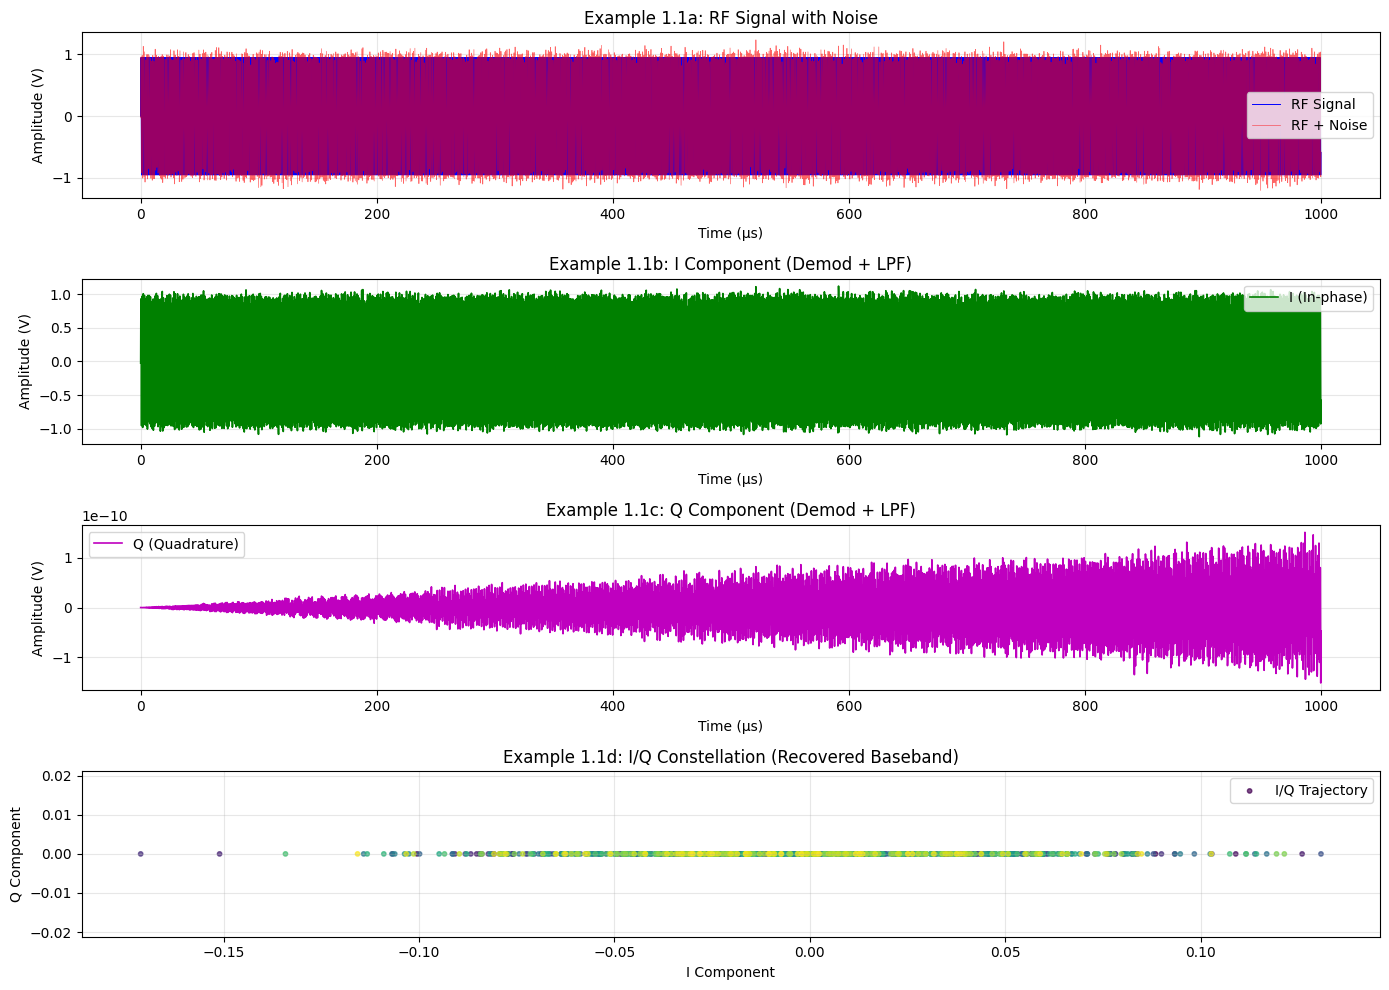

RF Signal Power: 0.500000 V²
I Component Power: 0.502055 V²
Q Component Power: 0.000000 V²
Recovered Signal Power: 0.502055 V²

EXAMPLE 1.2: I/Q Imbalance Detection and Measurement (Realistic Model)


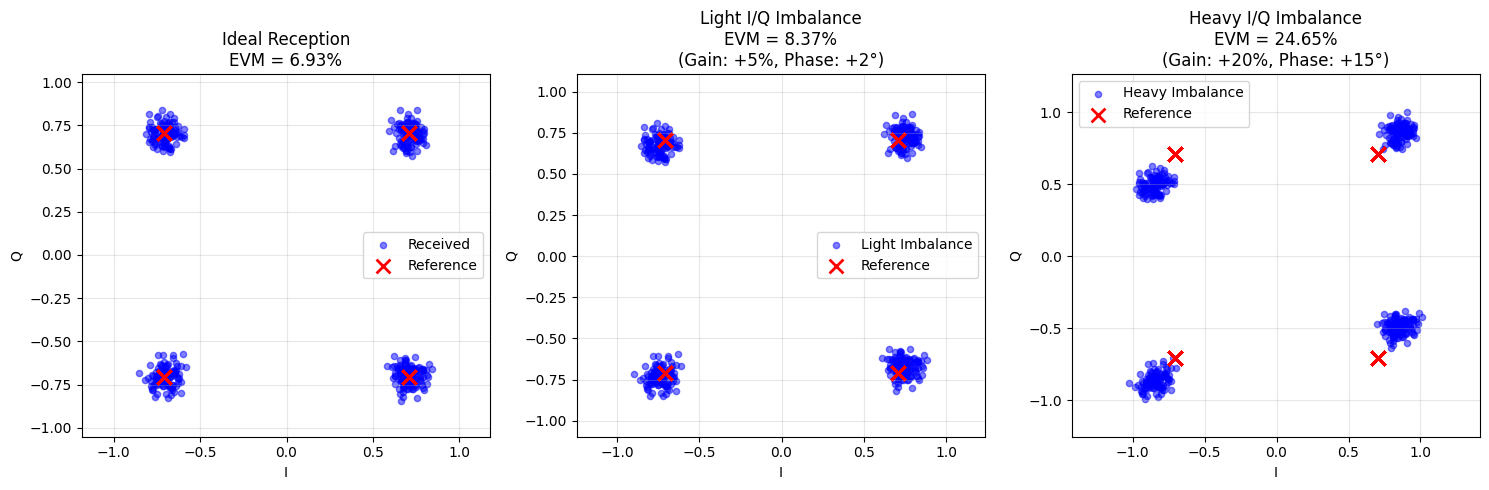

EVM (Ideal): 6.9287%
EVM (Light Imbalance - 5% gain, 2° phase): 8.3696%
EVM (Heavy Imbalance - 20% gain, 15° phase): 24.6493%
EVM Degradation (Light): 1.4409% absolute
EVM Degradation (Heavy): 17.7206% absolute


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =============================================================================
# EXAMPLE 1.1: RF Signal Decomposition into I/Q Components
# =============================================================================
print("=" * 80)
print("EXAMPLE 1.1: RF Signal Decomposition into I/Q Components")
print("=" * 80)

# Parameters (use enough samples for stable filtering)
fs = 10e6      # Sampling frequency (10 MHz)
fc = 100e6     # Carrier frequency (100 MHz)
t_duration = 1e-3  # Duration (1 ms) -> 10,000 samples
SNR_dB = 20    # Signal-to-noise ratio

# Time vector
t = np.arange(0, t_duration, 1/fs)

# Information (modulating) signal
fm = 1e6
m_t = np.sin(2 * np.pi * fm * t)

# RF signal (AM on carrier)
rf_signal = m_t * np.cos(2 * np.pi * fc * t)

# Add AWGN
noise_power = np.mean(rf_signal**2) / (10**(SNR_dB/10))
noise = np.sqrt(noise_power) * np.random.randn(len(t))
rf_noisy = rf_signal + noise

# I/Q demodulation (complex downconversion)
complex_exp = np.exp(-1j * 2 * np.pi * fc * t)
iq_signal = rf_noisy * complex_exp

# Low-pass filter to remove HF components
filter_order = 101  # ensure << len(t)
cutoff_freq = 2e6 / (fs/2)  # normalized cutoff (pass fm=1 MHz)
b = signal.firwin(filter_order, cutoff_freq)

i_component = signal.filtfilt(b, 1, np.real(iq_signal))
q_component = signal.filtfilt(b, 1, np.imag(iq_signal))

# Plot Example 1.1
fig1, axes1 = plt.subplots(4, 1, figsize=(14, 10))

# RF signal
axes1[0].plot(t*1e6, rf_signal, 'b-', linewidth=0.7, label='RF Signal')
axes1[0].plot(t*1e6, rf_noisy, 'r-', linewidth=0.5, label='RF + Noise', alpha=0.6)
axes1[0].set_xlabel('Time (μs)')
axes1[0].set_ylabel('Amplitude (V)')
axes1[0].set_title('Example 1.1a: RF Signal with Noise')
axes1[0].legend()
axes1[0].grid(True, alpha=0.3)

# I component
axes1[1].plot(t*1e6, i_component, 'g-', linewidth=1.2, label='I (In-phase)')
axes1[1].set_xlabel('Time (μs)')
axes1[1].set_ylabel('Amplitude (V)')
axes1[1].set_title('Example 1.1b: I Component (Demod + LPF)')
axes1[1].legend()
axes1[1].grid(True, alpha=0.3)

# Q component
axes1[2].plot(t*1e6, q_component, 'm-', linewidth=1.2, label='Q (Quadrature)')
axes1[2].set_xlabel('Time (μs)')
axes1[2].set_ylabel('Amplitude (V)')
axes1[2].set_title('Example 1.1c: Q Component (Demod + LPF)')
axes1[2].legend()
axes1[2].grid(True, alpha=0.3)

# Constellation (subsample for clarity)
sub = slice(None, None, 10)
axes1[3].scatter(i_component[sub], q_component[sub],
                 c=np.arange(len(i_component[sub])), cmap='viridis', s=10, alpha=0.7,
                 label='I/Q Trajectory')
axes1[3].set_xlabel('I Component')
axes1[3].set_ylabel('Q Component')
axes1[3].set_title('Example 1.1d: I/Q Constellation (Recovered Baseband)')
axes1[3].grid(True, alpha=0.3)
axes1[3].axis('equal')
axes1[3].legend()

plt.tight_layout()
plt.savefig('example_1_1_iq_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"RF Signal Power: {np.mean(rf_signal**2):.6f} V²")
print(f"I Component Power: {np.mean(i_component**2):.6f} V²")
print(f"Q Component Power: {np.mean(q_component**2):.6f} V²")
print(f"Recovered Signal Power: {np.mean(i_component**2 + q_component**2):.6f} V²")
print()

# =============================================================================
# EXAMPLE 1.2: Realistic I/Q Imbalance Detection and Measurement
# =============================================================================
print("=" * 80)
print("EXAMPLE 1.2: I/Q Imbalance Detection and Measurement (Realistic Model)")
print("=" * 80)

# Ideal QPSK constellation (normalized)
symbols_qpsk = np.array([1+1j, 1-1j, -1+1j, -1-1j], dtype=complex) / np.sqrt(2)

# Build a sequence of QPSK symbols
num_symbols = 100
num_repeats = 5
symbols_tx = np.tile(symbols_qpsk, num_symbols // 4 * num_repeats)

# Add noise to ideal reception
noise_i = 0.05 * np.random.randn(len(symbols_tx))
noise_q = 0.05 * np.random.randn(len(symbols_tx))
symbols_ideal = symbols_tx + (noise_i + 1j * noise_q)

def apply_iq_imbalance(symbols, gain_imbalance=1.0, phase_imbalance=0.0):
    """
    Apply realistic I/Q imbalance to complex symbols.
    gain_imbalance: scaling factor for I branch (e.g., 1.05 for +5%)
    phase_imbalance: phase error (radians), cross-couples I into Q
    """
    I = np.real(symbols)
    Q = np.imag(symbols)
    # Gain on I, rotation coupling from I to Q
    I_imbal = gain_imbalance * I
    Q_imbal = Q * np.cos(phase_imbalance) + I * np.sin(phase_imbalance)
    return I_imbal + 1j * Q_imbal

# Light imbalance
gain_imbalance_light = 1.05     # +5% gain on I
phase_imbalance_light = np.deg2rad(2)  # +2° phase error
symbols_imbal_light = apply_iq_imbalance(symbols_ideal,
                                         gain_imbalance=gain_imbalance_light,
                                         phase_imbalance=phase_imbalance_light)

# Heavy imbalance
gain_imbalance_heavy = 1.20     # +20% gain on I
phase_imbalance_heavy = np.deg2rad(15) # +15° phase error
symbols_imbal_heavy = apply_iq_imbalance(symbols_ideal,
                                         gain_imbalance=gain_imbalance_heavy,
                                         phase_imbalance=phase_imbalance_heavy)

def calculate_evm(received, reference):
    """Calculate EVM in percent."""
    error = received - reference
    evm_rms = np.sqrt(np.mean(np.abs(error)**2))
    ref_rms = np.sqrt(np.mean(np.abs(reference)**2))
    evm_percent = (evm_rms / (ref_rms + 1e-12)) * 100
    return evm_percent

evm_ideal = calculate_evm(symbols_ideal, symbols_tx)
evm_light = calculate_evm(symbols_imbal_light, symbols_tx)
evm_heavy = calculate_evm(symbols_imbal_heavy, symbols_tx)

# Plot Example 1.2
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

# Ideal
axes2[0].scatter(np.real(symbols_ideal), np.imag(symbols_ideal),
                 c='b', s=20, alpha=0.5, label='Received')
axes2[0].scatter(np.real(symbols_tx), np.imag(symbols_tx),
                 c='r', marker='x', s=100, linewidths=2, label='Reference')
axes2[0].set_xlabel('I')
axes2[0].set_ylabel('Q')
axes2[0].set_title(f'Ideal Reception\nEVM = {evm_ideal:.2f}%')
axes2[0].grid(True, alpha=0.3)
axes2[0].axis('equal')
axes2[0].legend()

# Light imbalance
axes2[1].scatter(np.real(symbols_imbal_light), np.imag(symbols_imbal_light),
                 c='b', s=20, alpha=0.5, label='Light Imbalance')
axes2[1].scatter(np.real(symbols_tx), np.imag(symbols_tx),
                 c='r', marker='x', s=100, linewidths=2, label='Reference')
axes2[1].set_xlabel('I')
axes2[1].set_ylabel('Q')
axes2[1].set_title(f'Light I/Q Imbalance\nEVM = {evm_light:.2f}%\n(Gain: +5%, Phase: +2°)')
axes2[1].grid(True, alpha=0.3)
axes2[1].axis('equal')
axes2[1].legend()

# Heavy imbalance
axes2[2].scatter(np.real(symbols_imbal_heavy), np.imag(symbols_imbal_heavy),
                 c='b', s=20, alpha=0.5, label='Heavy Imbalance')
axes2[2].scatter(np.real(symbols_tx), np.imag(symbols_tx),
                 c='r', marker='x', s=100, linewidths=2, label='Reference')
axes2[2].set_xlabel('I')
axes2[2].set_ylabel('Q')
axes2[2].set_title(f'Heavy I/Q Imbalance\nEVM = {evm_heavy:.2f}%\n(Gain: +20%, Phase: +15°)')
axes2[2].grid(True, alpha=0.3)
axes2[2].axis('equal')
axes2[2].legend()

plt.tight_layout()
plt.savefig('example_1_2_iq_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"EVM (Ideal): {evm_ideal:.4f}%")
print(f"EVM (Light Imbalance - 5% gain, 2° phase): {evm_light:.4f}%")
print(f"EVM (Heavy Imbalance - 20% gain, 15° phase): {evm_heavy:.4f}%")
print(f"EVM Degradation (Light): {evm_light - evm_ideal:.4f}% absolute")
print(f"EVM Degradation (Heavy): {evm_heavy - evm_ideal:.4f}% absolute")

## 4. ARRAY MANIFOLD & STEERING VECTORS - THEORY

### Fundamental Concept: What Is an Array Manifold?

**Array Manifold** is the **mathematical relationship** between:
- **Direction of arrival (DoA)** of an incoming signal, and
- **Phase differences** observed across antenna elements due to propagation delay

**Why it matters:** The manifold tells us how to **steer** an array to receive signals from a specific direction with **constructive interference**.

### Geometric Setup: Uniform Linear Array (ULA)

**Configuration:**
- $M$ antennas spaced uniformly at distance $d$ (typically $d = \lambda/2$ or $\lambda$)
- Signal arrives at angle $\theta$ from broadside (0° = perpendicular to array)
- Wavelength: $\lambda = c/f$ (speed of light / frequency)

**Propagation delay model:**
At antenna $m$, the signal from DoA $\theta$ arrives with **time delay**:
$$\tau_m(\theta) = \frac{m \cdot d}{c} \sin(\theta)$$

The $m$-th antenna receives:
$$x_m(t) = A \cdot e^{j 2\pi f (t - \tau_m(\theta))}$$

where $A$ is amplitude and $f$ is carrier frequency.

### Phase Difference Across Array Elements

**Key insight:** Instead of tracking absolute delays, we observe **phase differences**:

$$\phi_m(\theta) = -2\pi f \cdot \tau_m(\theta) = -2\pi \frac{f \cdot m \cdot d}{c} \sin(\theta)$$

Using wavelength $\lambda = c/f$:
$$\phi_m(\theta) = -2\pi \frac{m \cdot d}{\lambda} \sin(\theta) = -m \cdot 2\pi \frac{d}{\lambda} \sin(\theta)$$

Define **normalized wavenumber**:
$$\psi(\theta) = 2\pi \frac{d}{\lambda} \sin(\theta) = \frac{2\pi d}{\lambda} \sin(\theta)$$

Then:
$$\phi_m(\theta) = -m \cdot \psi(\theta)$$

**Physical interpretation:**
- $\psi(\theta)$ represents the **phase advance** per antenna element
- At broadside ($\theta = 0°$): $\psi = 0$, all elements in phase
- At 90° (endfire): $\psi = 2\pi d/\lambda$, maximum phase sweep

### The Array Manifold Vector (Steering Vector)

**Definition:** The steering vector $\mathbf{a}(\theta)$ contains the **phase response** of each antenna element:

$$\mathbf{a}(\theta) = \begin{bmatrix} 1 \\ e^{-j\psi(\theta)} \\ e^{-j 2\psi(\theta)} \\ \vdots \\ e^{-j(M-1)\psi(\theta)} \end{bmatrix} = \begin{bmatrix} e^{j 0 \cdot \psi} \\ e^{j 1 \cdot \psi} \\ e^{j 2 \cdot \psi} \\ \vdots \\ e^{j(M-1) \cdot \psi} \end{bmatrix}$$

where $\psi(\theta) = 2\pi d \sin(\theta) / \lambda$.

**Compact form:**
$$\mathbf{a}(\theta) = [1, e^{j\psi}, e^{j 2\psi}, \ldots, e^{j(M-1)\psi}]^T$$

This is a **geometric series** of complex exponentials with phase increment $\psi$ per element.

### Beamforming Interpretation

**Goal:** Steer the array to "point" at angle $\theta_0$.

**Method:** Apply **conjugate of steering vector** to array output:
$$\mathbf{w} = \mathbf{a}^*(\theta_0)$$

**Result:** Output signal at angle $\theta_0$:
$$y = \mathbf{w}^H \mathbf{x} = \mathbf{a}^H(\theta_0) \mathbf{x}$$

**Physics:** Multiplying by $e^{-j m \psi(\theta_0)}$ applies **phase shift** that compensates the propagation delay, causing **constructive interference** in direction $\theta_0$.

### Array Manifold Properties

**1. Magnitude (All Ones)**
$$|\mathbf{a}(\theta)|_m = 1 \text{ for all } m$$
The manifold is **normalized**: each element has unity gain.

**2. Orthogonality at Different Angles**
For angles $\theta_1 \neq \theta_2$:
$$\mathbf{a}^H(\theta_1) \mathbf{a}(\theta_2) \approx 0 \text{ (if sufficiently different)}$$

**Proof:**
$$\mathbf{a}^H(\theta_1) \mathbf{a}(\theta_2) = \sum_{m=0}^{M-1} e^{-j(m\psi_1 - m\psi_2)} = \sum_{m=0}^{M-1} e^{-jm(\psi_1 - \psi_2)}$$

This is a geometric series:
$$= \frac{1 - e^{-jM(\psi_1 - \psi_2)}}{1 - e^{-j(\psi_1 - \psi_2)}}$$

When $\psi_1 \neq \psi_2$, this sums to **small values** (denominator ≠ numerator).

**Implication:** Signals from different directions have **nearly orthogonal** projections on array manifold.

**3. Ambiguity (Aliasing)**
Phase uniqueness is limited to:
$$-\pi \leq \psi(\theta) \leq \pi$$

If $d > \lambda/2$, signals from different angles produce the same phase pattern (**spatial aliasing**). This is why $d = \lambda/2$ is standard.

### Multi-Dimensional Signal Model

**Receive signal at array:**
$$\mathbf{x}(t) = \sum_{k=1}^{K} s_k(t) \cdot \mathbf{a}(\theta_k) + \mathbf{n}(t)$$

where:
- $K$: Number of incoming signals
- $s_k(t)$: Signal waveform from source $k$
- $\mathbf{a}(\theta_k)$: Manifold vector for direction $\theta_k$
- $\mathbf{n}(t)$: Additive noise

**Snapshot (frequency-domain)**
At frequency bin $f$:
$$\mathbf{X}_f = \sum_{k=1}^{K} S_k(f) \cdot \mathbf{a}(\theta_k, f) + \mathbf{N}(f)$$

where manifold depends on both **angle and frequency**.

### 2D Array Considerations

**Planar array (e.g., 2D grid of antennas):**

Steering vector becomes:
$$\mathbf{a}(\theta, \phi) = \mathbf{a}_x(\theta, \phi) \otimes \mathbf{a}_y(\theta, \phi)$$

where:
- $\theta$: Azimuth angle
- $\phi$: Elevation angle
- $\otimes$: Kronecker product

**2D manifold advantage:** Can localize in **both azimuth and elevation**, enabling 3D imaging.

### Connection to Other Sections

- **Clutter Cancellation:** Uses manifolds to form notches at clutter direction
- **STAP:** Manifold represents both **spatial** (array) and **temporal** (Doppler) steering
- **Beamforming:** Applies weights to manifold for adaptive directivity
- **Direction Finding:** Searches for manifold vectors matching received data


EXAMPLE 2: Array Manifold and Steering Vectors

Example 2.1: Conventional (Uniform Weights) Beamformer
------------------------------------------------------------
Beam Response at 0°: 1.000000
3-dB Beamwidth: 12.00°
First Sidelobe Level: 0.00 dB

Example 2.2: Steering Vector Analysis at Three Angles
------------------------------------------------------------


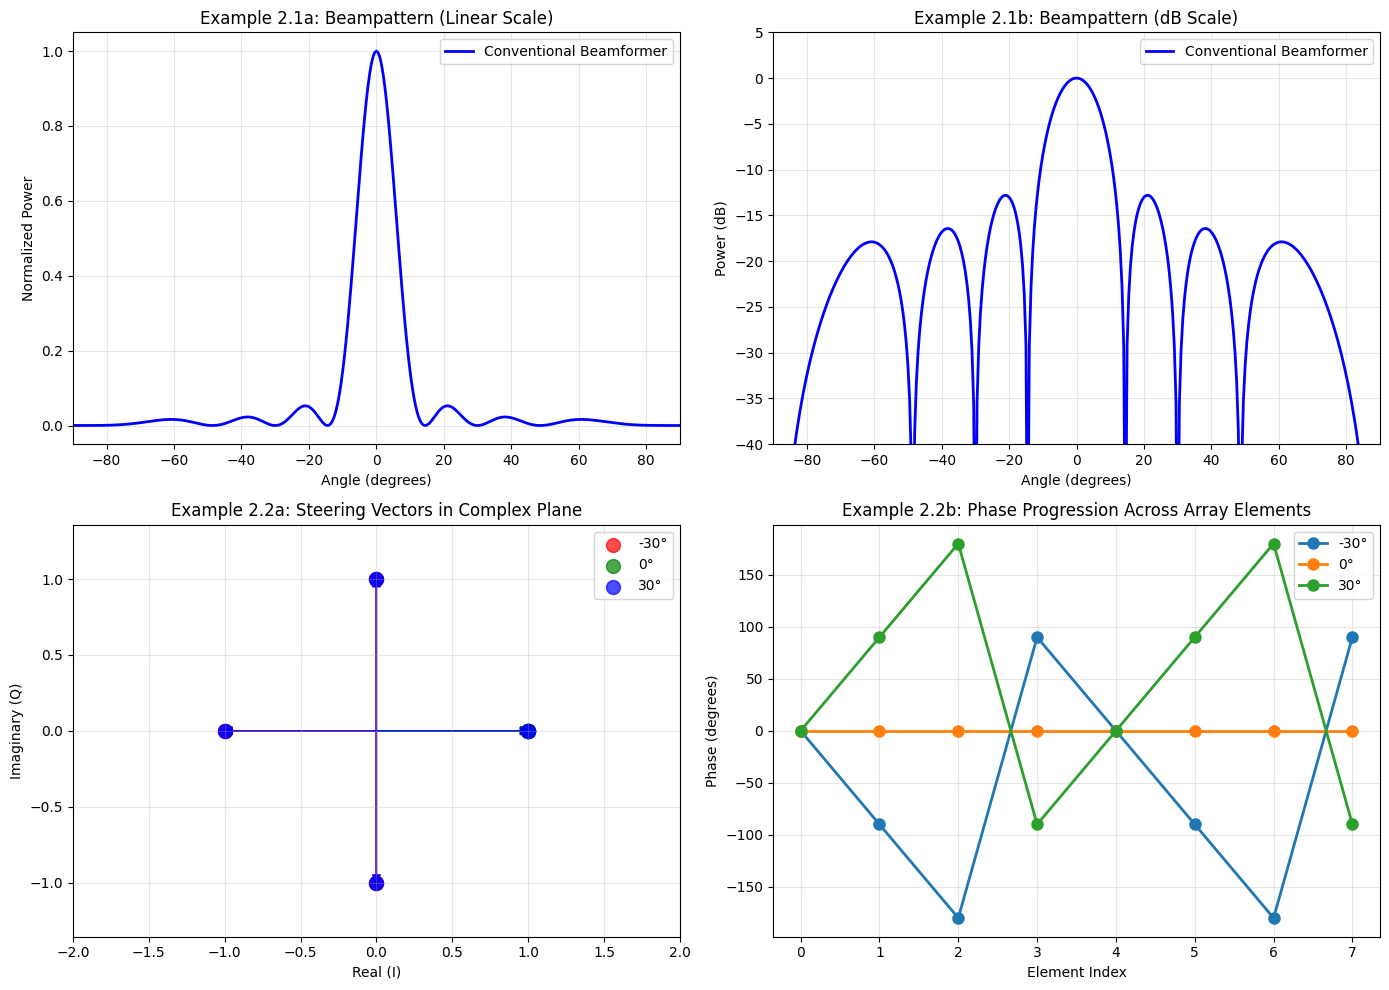


Steering vectors computed for 361 angles
Array: 8 elements, 0.50λ spacing


In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("EXAMPLE 2: Array Manifold and Steering Vectors")
print("=" * 80)

# Parameters
num_elements = 8  # Number of antenna elements
wavelength = 1.0  # Normalized wavelength
inter_element_spacing = wavelength / 2  # Half-wavelength spacing (typical for arrays)

# Angle range for beampattern
angles = np.linspace(-90, 90, 361)  # -90° to +90° in steps of 0.5°
angles_rad = angles * np.pi / 180

# Function to generate steering vector
def steering_vector(angles_rad, num_elements, spacing_wavelengths):
    """
    Generate steering vectors for linear uniform array (ULA)
    
    Parameters:
    - angles_rad: array of angles in radians
    - num_elements: number of array elements
    - spacing_wavelengths: element spacing in wavelengths
    
    Returns:
    - a: steering vectors (num_angles x num_elements), each row is a steering vector
    """
    m = np.arange(num_elements)  # Element indices
    a = np.zeros((len(angles_rad), num_elements), dtype=complex)
    
    for idx, theta in enumerate(angles_rad):
        phase = 2 * np.pi * m * spacing_wavelengths * np.sin(theta)
        a[idx, :] = np.exp(1j * phase)
    
    return a

# Generate steering vectors
a = steering_vector(angles_rad, num_elements, inter_element_spacing)

# Example 2.1: Conventional beamformer (uniform weighting)
print("\nExample 2.1: Conventional (Uniform Weights) Beamformer")
print("-" * 60)

# Weights: uniform (all equal magnitude and phase)
w_conventional = np.ones(num_elements) / num_elements

# Beampattern: response for all angles
beampattern_conventional = np.zeros(len(angles))
for idx in range(len(angles)):
    beampattern_conventional[idx] = np.abs(np.dot(w_conventional, a[idx, :]))**2

# Find 3dB beamwidth and sidelobe level
max_response = np.max(beampattern_conventional)
half_power = max_response / 2
beamwidth_indices = np.where(beampattern_conventional >= half_power)[0]
if len(beamwidth_indices) > 0:
    beamwidth = angles[beamwidth_indices[-1]] - angles[beamwidth_indices[0]]
else:
    beamwidth = 0

# Find first sidelobe
main_lobe_end = np.argmax(beampattern_conventional < max_response/2)
if main_lobe_end > 0:
    first_sidelobe = np.max(beampattern_conventional[main_lobe_end:])
else:
    first_sidelobe = np.max(beampattern_conventional)

print(f"Beam Response at 0°: {beampattern_conventional[180]:.6f}")
print(f"3-dB Beamwidth: {beamwidth:.2f}°")
print(f"First Sidelobe Level: {10*np.log10(first_sidelobe):.2f} dB")

# Example 2.2: Comparison of steering vectors for three angles
print("\nExample 2.2: Steering Vector Analysis at Three Angles")
print("-" * 60)

test_angles = [-30, 0, 30]  # Test angles in degrees
test_angles_rad = [angle * np.pi / 180 for angle in test_angles]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Beampatterns (Linear and dB scale)
axes[0, 0].plot(angles, beampattern_conventional, 'b-', linewidth=2, label='Conventional Beamformer')
axes[0, 0].set_xlabel('Angle (degrees)')
axes[0, 0].set_ylabel('Normalized Power')
axes[0, 0].set_title('Example 2.1a: Beampattern (Linear Scale)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_xlim([-90, 90])

# Plot 2: Beampattern in dB scale
beampattern_db = 10 * np.log10(np.maximum(beampattern_conventional, 1e-6))
axes[0, 1].plot(angles, beampattern_db, 'b-', linewidth=2, label='Conventional Beamformer')
axes[0, 1].set_xlabel('Angle (degrees)')
axes[0, 1].set_ylabel('Power (dB)')
axes[0, 1].set_title('Example 2.1b: Beampattern (dB Scale)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xlim([-90, 90])
axes[0, 1].set_ylim([-40, 5])

# Plot 3: Steering vectors in complex plane (I/Q diagram)
colors_sv = ['red', 'green', 'blue']
for i, (angle, angle_rad) in enumerate(zip(test_angles, test_angles_rad)):
    sv_idx = np.argmin(np.abs(angles_rad - angle_rad))
    sv = a[sv_idx, :]
    axes[1, 0].scatter(np.real(sv), np.imag(sv), s=100, label=f'{angle}°', color=colors_sv[i], alpha=0.7)
    for j in range(num_elements):
        axes[1, 0].arrow(0, 0, np.real(sv[j])*0.95, np.imag(sv[j])*0.95, 
                        head_width=0.05, head_length=0.05, color=colors_sv[i], alpha=0.5)

axes[1, 0].set_xlabel('Real (I)')
axes[1, 0].set_ylabel('Imaginary (Q)')
axes[1, 0].set_title('Example 2.2a: Steering Vectors in Complex Plane')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axis('equal')
axes[1, 0].legend()
axes[1, 0].set_xlim([-2, 2])
axes[1, 0].set_ylim([-2, 2])

# Plot 4: Phase progression across array elements for each angle
element_indices = np.arange(num_elements)
for i, (angle, angle_rad) in enumerate(zip(test_angles, test_angles_rad)):
    sv_idx = np.argmin(np.abs(angles_rad - angle_rad))
    sv = a[sv_idx, :]
    phases = np.angle(sv) * 180 / np.pi
    axes[1, 1].plot(element_indices, phases, 'o-', label=f'{angle}°', linewidth=2, markersize=8)

axes[1, 1].set_xlabel('Element Index')
axes[1, 1].set_ylabel('Phase (degrees)')
axes[1, 1].set_title('Example 2.2b: Phase Progression Across Array Elements')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_xticks(element_indices)

plt.tight_layout()
plt.savefig('example_2_array_manifold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSteering vectors computed for {len(angles)} angles")
print(f"Array: {num_elements} elements, {inter_element_spacing:.2f}λ spacing")


## 5. CLUTTER CANCELLATION - FUNDAMENTALS

### What Is Clutter and Why Remove It?

**Definition:** **Clutter** is undesired radar echo from non-target objects:
- **Ground clutter:** Reflections from terrain, buildings, trees
- **Sea clutter:** Reflections from water surface (waves, foam)
- **Weather clutter:** Reflections from rain, snow, hail
- **Multipaths:** Reflections from structures that mask targets

**Power problem:** Clutter power can be **1000x or more** stronger than target signals:
- Target RCS (Radar Cross Section): ~5 m² (aircraft)
- Ground RCS: Enormous (cities cover many km²)
- **Result:** Targets "disappear" in clutter without cancellation

**Detection condition (without clutter rejection):**
$$\text{SNR}_{\text{received}} = \frac{P_{\text{target}}}{P_{\text{clutter}} + P_{\text{noise}}} \ll 1$$

**With effective clutter cancellation:**
$$\text{SNR}_{\text{effective}} = \frac{P_{\text{target}}}{P_{\text{noise only}}} >> 1$$

**Clutter rejection ratio (CRR):** Typically 30-60 dB for effective systems.

### Clutter Characteristics

**1. Spatial Structure**
- Clutter arrives from **specific directions** (not everywhere)
- Ground clutter: Concentrated around **broadside** or **near-grazing angles**
- Sea clutter: Concentrated at **sea surface** direction
- **Key insight:** Different spatial signature from targets

**2. Doppler Structure**
- **Stationary clutter:** Zero Doppler (if radar is stationary)
- **Moving clutter:** Non-zero Doppler (if radar platform moves or clutter moves)
- **Spread:** Clutter occupies a **Doppler "notch"** around zero (or platform velocity)
- **Width:** Determined by clutter patch size and radar dwell time
- **Targets:** Different Doppler (moving at different velocity than platform)

**3. Temporal Correlation**
- Clutter is **slowly varying** (quasi-static)
- Can be estimated on **training data** (clutter-only pulses)
- Predictable, unlike noise (which is random)

### Clutter Model

**Received signal (single pulse):**
$$x(t) = s_{\text{target}}(t) + c(t) + n(t)$$

where:
- $s_{\text{target}}(t) = A \cdot e^{j 2\pi f_d t}$ (Doppler-shifted target, $f_d = 2v/\lambda$)
- $c(t)$ = clutter (slow-varying, mostly at $f = 0$ for stationary radar)
- $n(t)$ = thermal noise (white, complex Gaussian)

**In frequency domain (after FFT):**
$$X[k] = S[k] + C[k] + N[k]$$

where $k$ is frequency bin. Target occupies bin $k_d$, clutter mostly in bins around $k = 0$.

**In 2D (spatial + Doppler):**
At antenna $m$, pulse $l$:
$$x_{m,l}(t) = s_{m,l}(t) + c_{m,l}(t) + n_{m,l}(t)$$

Clutter has both **spatial structure** (across array) and **Doppler structure** (across pulses).

### Clutter Covariance Matrix

**For $M$ antennas and $L$ pulses**, stack signals:
$$\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_L] \quad \text{(M × L matrix)}$$

**Clutter covariance:**
$$\mathbf{R}_c = \mathbb{E}[\mathbf{c} \mathbf{c}^H]$$

**Key properties:**
- **Low-rank:** Clutter occupies few spatial/Doppler modes
- **Structured:** Not white noise; contains correlations
- **Predictable:** Can estimate from training data

**Rank** is typically much smaller than $M \times L$, enabling effective cancellation via **subspace techniques**.

### Clutter Cancellation Methods

#### **Method 1: Spatial Nulling (Single Pulse)**
Remove clutter by creating a **null** in the array response at clutter direction $\theta_c$:
$$\mathbf{w} = \text{constraint such that } \mathbf{a}^H(\theta_c) \mathbf{w} = 0$$

**Result:** Array responds to all directions **except** clutter direction.

**Limitation:** Only works if clutter arrives from known direction (usually true for ground clutter).

#### **Method 2: Doppler Filtering (Pulse Train)**
Apply **high-pass filter** in Doppler domain to remove zero-Doppler clutter:

$$H(z) = 1 - z^{-1} = 1 - e^{-j 2\pi f_d T}$$

where $T$ is pulse interval and $f_d$ is Doppler frequency.

**Result:** Clutter (at $f_d = 0$) is attenuated; targets (at $f_d \neq 0$) pass through.

**Limitation:** Stationary targets (Doppler ≈ 0) appear as clutter.

#### **Method 3: Least Mean Squares (LMS) Adaptive Filtering**
**Principle:** Learn clutter subspace from **training data** and subtract it.

**Setup:**
- Training data: $L$ pulses containing **only clutter** (no target)
- Reference: Clutter estimate $\hat{c}(t) = \mathbf{w}^H \mathbf{x}_{\text{ref}}(t)$

**LMS algorithm:**
$$\mathbf{w}_{n+1} = \mathbf{w}_n + \mu \cdot e_n \cdot \mathbf{x}_n$$

where:
- $e_n = x_n - \hat{c}_n$ = error (target + residual clutter)
- $\mu$ = step size (convergence rate)
- $\mathbf{x}_n$ = received signal (training pulse)

**Result:** $\mathbf{w}$ learns to extract clutter; output $e_n$ becomes target-only.

**Advantage:** Adaptive; handles time-varying clutter.

#### **Method 4: Principal Component Analysis (PCA)**
**Principle:** Identify and remove dominant clutter modes.

**Procedure:**
1. Form covariance matrix: $\mathbf{R} = \mathbf{X} \mathbf{X}^H$
2. Eigendecompose: $\mathbf{R} = \mathbf{U} \boldsymbol{\Lambda} \mathbf{U}^H$
3. Clutter spans **$r$ dominant eigenvectors** (those with largest eigenvalues)
4. Projection onto target subspace (orthogonal to clutter):
$$\mathbf{P}_{\perp} = \mathbf{I} - \mathbf{U}_r \mathbf{U}_r^H$$
5. Clutter-suppressed output:
$$\mathbf{x}_{\text{clean}} = \mathbf{P}_{\perp} \mathbf{x}$$

**Advantage:** Optimal if clutter truly low-rank; interpretable.

**Limitation:** Requires accurate rank estimation; computationally heavier.

#### **Method 5: Blind Estimation (Whitening + Thresholding)**
**Principle:** Clutter has **structure** (correlated); noise is **white** (uncorrelated).

**Procedure:**
1. Estimate noise covariance from **off-clutter** regions
2. Whiten received signal: $\mathbf{y} = \mathbf{R}_n^{-1/2} \mathbf{x}$
3. Threshold small coefficients (these are noise + residual clutter)
4. Reconstruction from large coefficients (target signal)

**Advantage:** No training data needed; unsupervised.

### Performance Metrics

**1. Clutter Rejection Ratio (CRR)**
$$\text{CRR} = \frac{P_{\text{clutter in}} }{P_{\text{clutter out}}} \quad \text{[dB]}$$

Typical: 40-60 dB for well-designed systems.

**2. Signal Retention**
$$\text{Target Loss} = \frac{P_{\text{target out}}}{P_{\text{target in}}} = 1 - \frac{P_{\text{clutter}}}{P_{\text{target}} + P_{\text{clutter}}}$$

Want to maximize target retention while canceling clutter.

**3. SINR (Signal-to-Interference-plus-Noise Ratio)**

Before cancellation:
$$\text{SINR}_{\text{in}} = \frac{P_{\text{target}}}{P_{\text{clutter}} + P_{\text{noise}}}$$

After cancellation:
$$\text{SINR}_{\text{out}} = \frac{P_{\text{target, residual}}}{P_{\text{clutter, residual}} + P_{\text{noise}}}$$

**Improvement:** $\frac{\text{SINR}_{\text{out}}}{\text{SINR}_{\text{in}}} \approx \text{CRR}$ (ideally).

### Practical Implementation Considerations

1. **Adaptive vs. Fixed:** Fixed filters are faster but less flexible; adaptive learns clutter variations
2. **Training data:** Must have clutter-only intervals (gaps between target events)
3. **Clutter steering:** Must know or estimate clutter direction/Doppler
4. **Target masking:** Risk of canceling weak targets if they overlap with clutter spatially or in Doppler
5. **Processing gain:** Combining multiple pulses + antenna channels increases CRR



EXAMPLE 3: Adaptive Clutter Cancellation (NLMS Filter)

Simulation Setup:
- Samples: 1000
- Range bins: 128
- Clutter Power: 10.00 dB
- Signal Power: 0.00 dB
- Noise Power: -10.00 dB
- Signal-to-Clutter Ratio: -10.00 dB

Example 3.1: Range Profile Comparison (Before and After Clutter Cancellation)
------------------------------------------------------------
LMS Configuration:
- Filter Order: 16
- Step Size (μ, NLMS): 0.5
Clutter Power Before: 20.18 dB
Clutter Power After: 11.87 dB
Clutter Rejection Ratio (CRR): 8.31 dB


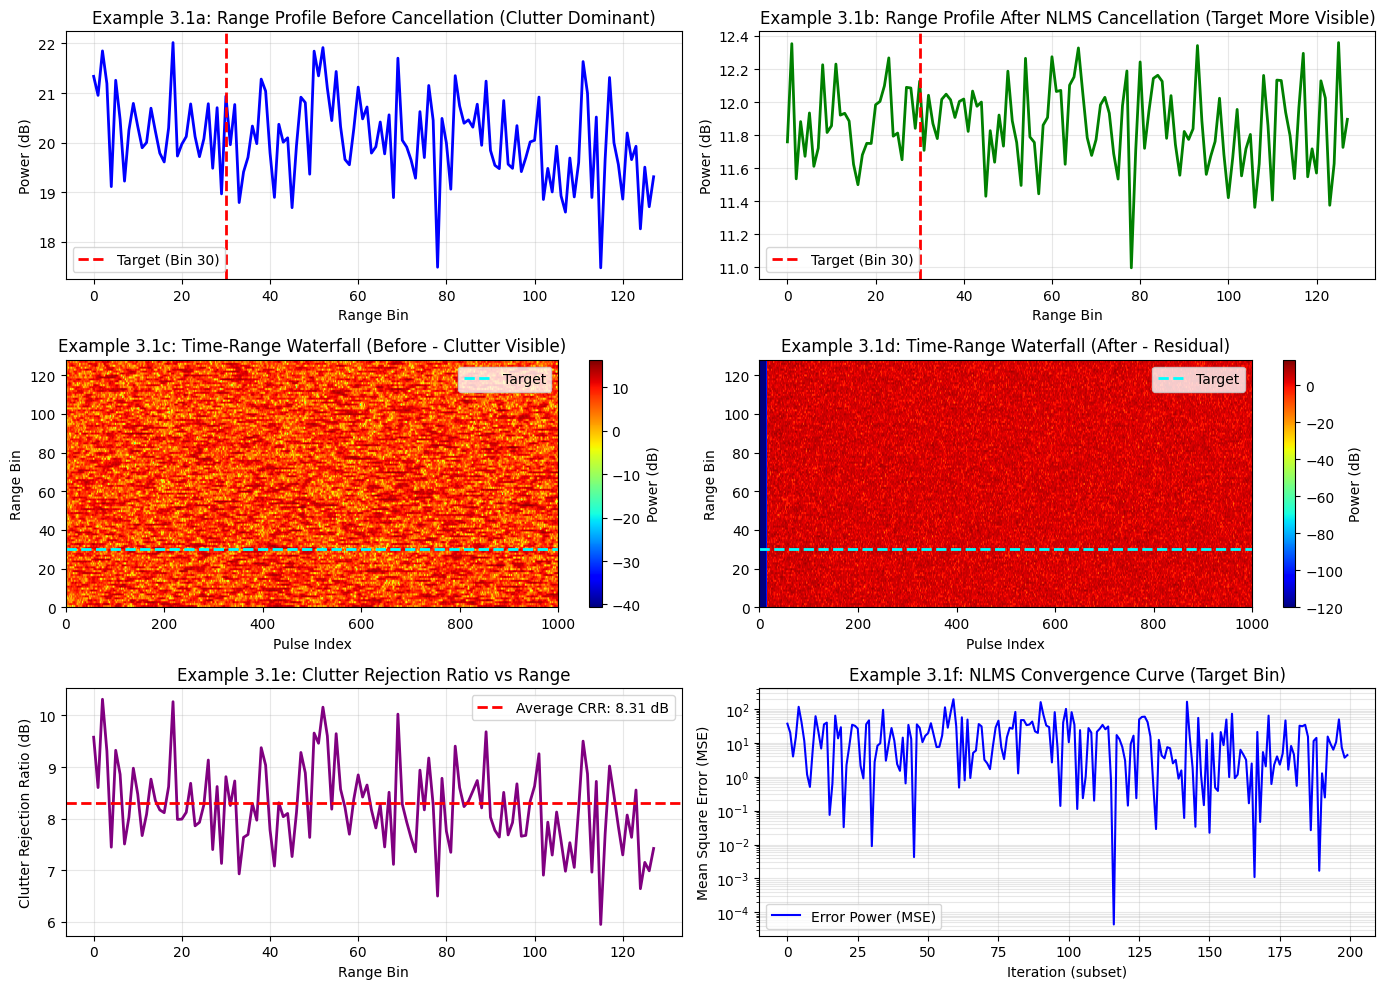

In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("EXAMPLE 3: Adaptive Clutter Cancellation (NLMS Filter)")
print("=" * 80)

# Simulation parameters
num_samples = 1000   # Number of pulses/snapshots
num_ranges = 128     # Number of range bins
clutter_power = 10.0 # Strong clutter power
signal_power = 1.0   # Weak target signal power
noise_power = 0.1    # Background noise power
lms_mu = 0.5         # NLMS step size in (0,2); typical stable ~0.1–1.0
lms_order = 16       # Filter order (number of taps)
nlms_eps = 1e-6      # Small constant to avoid division by zero

print(f"\nSimulation Setup:")
print(f"- Samples: {num_samples}")
print(f"- Range bins: {num_ranges}")
print(f"- Clutter Power: {10*np.log10(clutter_power):.2f} dB")
print(f"- Signal Power: {10*np.log10(signal_power):.2f} dB")
print(f"- Noise Power: {10*np.log10(noise_power):.2f} dB")
print(f"- Signal-to-Clutter Ratio: {10*np.log10(signal_power/clutter_power):.2f} dB")

print("\nExample 3.1: Range Profile Comparison (Before and After Clutter Cancellation)")
print("-" * 60)

# Generate clutter (strong, spatially correlated across time using AR(1) per range bin)
rho = 0.95
clutter = np.zeros((num_samples, num_ranges))
for r in range(num_ranges):
    w = np.sqrt(clutter_power) * np.random.randn(num_samples)
    for n in range(1, num_samples):
        clutter[n, r] = rho * clutter[n-1, r] + w[n]

# Generate target signal at a specific range bin with Doppler-like modulation
target_range_bin = 30
doppler_hz = 5.0
time_vector = np.arange(num_samples)
target_signal = np.zeros((num_samples, num_ranges))
# Weak target across all bins baseline; will be stronger at target bin
base = np.sqrt(signal_power) * np.sin(2 * np.pi * doppler_hz * time_vector / 1000.0)
target_signal += 0.1 * base[:, None]
target_signal[:, target_range_bin] = np.sqrt(signal_power) * np.sin(2 * np.pi * doppler_hz * time_vector / 1000.0)

# Add white noise
noise = np.sqrt(noise_power) * np.random.randn(num_samples, num_ranges)

# Received signal (clutter + target + noise)
received_signal = clutter + target_signal + noise

# Range profiles (power across time)
range_profile_before = np.mean(np.abs(received_signal)**2, axis=0)

# Adaptive clutter cancellation using NLMS per range bin
# We treat clutter as predictable; NLMS will learn to predict and subtract it
filtered_residual = np.zeros_like(received_signal)  # will store e_n (residual)
convergence_mse = []

print(f"LMS Configuration:")
print(f"- Filter Order: {lms_order}")
print(f"- Step Size (μ, NLMS): {lms_mu}")

for r in range(num_ranges):
    d = received_signal[:, r]  # desired = received (clutter + target + noise)
    # Build a regression (reference) from delayed versions of the same channel
    # This is a one-channel predictive canceller; x_n are past samples
    w = np.zeros(lms_order)    # reset weights per bin for stability

    # Warm-up: iterate samples and update weights
    for n in range(lms_order, num_samples):
        x_n = d[n-lms_order:n][::-1]        # past lms_order samples
        y_n = np.dot(w, x_n)                # predicted clutter component
        e_n = d[n] - y_n                    # residual (target + noise + unpredicted clutter)

        # NLMS update: scale step by input power
        denom = nlms_eps + np.dot(x_n, x_n)
        w += (lms_mu / denom) * e_n * x_n

        filtered_residual[n, r] = e_n

        # Track convergence on the target bin
        if r == target_range_bin:
            convergence_mse.append(e_n**2)

# Range profile after cancellation (power of residual)
range_profile_after = np.mean(np.abs(filtered_residual)**2, axis=0)

# Calculate clutter rejection ratio (CRR) safely
clutter_power_before = np.mean(range_profile_before)
clutter_power_after = np.mean(range_profile_after)

# Avoid NaN/Inf due to division or log of zero
eps = 1e-12
crr = 10 * np.log10((clutter_power_before + eps) / (clutter_power_after + eps))

print(f"Clutter Power Before: {10*np.log10(clutter_power_before + eps):.2f} dB")
print(f"Clutter Power After: {10*np.log10(clutter_power_after + eps):.2f} dB")
print(f"Clutter Rejection Ratio (CRR): {crr:.2f} dB")

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Plot 1: Range profile before cancellation
axes[0, 0].plot(10*np.log10(np.maximum(range_profile_before, eps)), 'b-', linewidth=2)
axes[0, 0].axvline(target_range_bin, color='r', linestyle='--', linewidth=2, label=f'Target (Bin {target_range_bin})')
axes[0, 0].set_xlabel('Range Bin')
axes[0, 0].set_ylabel('Power (dB)')
axes[0, 0].set_title('Example 3.1a: Range Profile Before Cancellation (Clutter Dominant)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot 2: Range profile after cancellation (residual)
axes[0, 1].plot(10*np.log10(np.maximum(range_profile_after, eps)), 'g-', linewidth=2)
axes[0, 1].axvline(target_range_bin, color='r', linestyle='--', linewidth=2, label=f'Target (Bin {target_range_bin})')
axes[0, 1].set_xlabel('Range Bin')
axes[0, 1].set_ylabel('Power (dB)')
axes[0, 1].set_title('Example 3.1b: Range Profile After NLMS Cancellation (Target More Visible)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Before waterfall
im1 = axes[1, 0].imshow(10*np.log10(np.maximum(np.abs(received_signal), eps)).T, aspect='auto',
                        cmap='jet', origin='lower', extent=[0, num_samples, 0, num_ranges])
axes[1, 0].axhline(target_range_bin, color='cyan', linestyle='--', linewidth=2, label='Target')
axes[1, 0].set_xlabel('Pulse Index')
axes[1, 0].set_ylabel('Range Bin')
axes[1, 0].set_title('Example 3.1c: Time-Range Waterfall (Before - Clutter Visible)')
axes[1, 0].legend()
plt.colorbar(im1, ax=axes[1, 0], label='Power (dB)')

# Plot 4: After waterfall (residual)
im2 = axes[1, 1].imshow(10*np.log10(np.maximum(np.abs(filtered_residual), eps)).T, aspect='auto',
                        cmap='jet', origin='lower', extent=[0, num_samples, 0, num_ranges])
axes[1, 1].axhline(target_range_bin, color='cyan', linestyle='--', linewidth=2, label='Target')
axes[1, 1].set_xlabel('Pulse Index')
axes[1, 1].set_ylabel('Range Bin')
axes[1, 1].set_title('Example 3.1d: Time-Range Waterfall (After - Residual)')
axes[1, 1].legend()
plt.colorbar(im2, ax=axes[1, 1], label='Power (dB)')

# Plot 5: CRR per bin
crr_per_bin = 10*np.log10(np.maximum(range_profile_before, eps) / np.maximum(range_profile_after, eps))
axes[2, 0].plot(crr_per_bin, color='purple', linewidth=2)
axes[2, 0].axhline(crr, color='r', linestyle='--', linewidth=2, label=f'Average CRR: {crr:.2f} dB')
axes[2, 0].set_xlabel('Range Bin')
axes[2, 0].set_ylabel('Clutter Rejection Ratio (dB)')
axes[2, 0].set_title('Example 3.1e: Clutter Rejection Ratio vs Range')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

# Plot 6: NLMS convergence curve (target bin)
if len(convergence_mse) > 0:
    axes[2, 1].semilogy(convergence_mse[:200], 'b-', linewidth=1.5, label='Error Power (MSE)')
    axes[2, 1].set_xlabel('Iteration (subset)')
    axes[2, 1].set_ylabel('Mean Square Error (MSE)')
    axes[2, 1].set_title('Example 3.1f: NLMS Convergence Curve (Target Bin)')
    axes[2, 1].grid(True, alpha=0.3, which='both')
    axes[2, 1].legend()

plt.tight_layout()
plt.savefig('example_3_clutter_cancellation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SPACE-TIME ADAPTIVE PROCESSING (STAP) - THEORY

### The Problem: Why Spatial + Temporal Processing?

**Limitation of spatial-only beamforming:**
- Removes clutter in **one direction** but may pass clutter at slightly different angles
- Doesn't exploit **Doppler** to distinguish targets from clutter

**Limitation of Doppler-only filtering:**
- High-pass filters remove **zero-Doppler** clutter but are uniform across array
- Doesn't adapt to **spatial clutter variation** across antenna elements

**Solution: STAP**
- **Spatial:** Uses array antenna pattern
- **Temporal (Doppler):** Uses pulse-to-pulse variations
- **Adaptive:** Learns optimal weights from data
- **Result:** Superior clutter rejection in **both dimensions**

### STAP Fundamental Model

**Received signal at antenna $m$, pulse $l$:**
$$x_{m,l} = s_{m,l}^{\text{target}} + c_{m,l}^{\text{clutter}} + n_{m,l}^{\text{noise}}$$

**Stack into vector:** For $M$ antennas and $L$ pulses, form the **STAP snapshot**:
$$\mathbf{x} = [x_{1,1}, x_{2,1}, \ldots, x_{M,1}, x_{1,2}, \ldots, x_{M,L}]^T \quad \text{(ML × 1 vector)}$$

**Signal model (simplified):**
$$s_{m,l} = \alpha \cdot e^{j 2\pi f_d l T_p} \cdot e^{j 2\pi d \sin(\theta) m / \lambda}$$

where:
- $\alpha$: Target amplitude
- $f_d$: Doppler frequency (2v/λ, where v is radial velocity)
- $T_p$: Pulse interval
- $\theta$: Direction of arrival
- $d$: Antenna spacing
- $\lambda$: Wavelength

### The Space-Time Steering Vector

**Kronecker product formulation:**

The target signal at angle $\theta$ and Doppler $f_d$ is described by the **space-time manifold**:
$$\mathbf{a}_{\text{ST}}(\theta, f_d) = \mathbf{a}_{\text{space}}(\theta) \otimes \mathbf{a}_{\text{time}}(f_d)$$

where:
- **Spatial manifold:** $\mathbf{a}_{\text{space}}(\theta) = [1, e^{j 2\pi d \sin(\theta) / \lambda}, \ldots, e^{j 2\pi (M-1) d \sin(\theta) / \lambda}]^T$
- **Temporal manifold:** $\mathbf{a}_{\text{time}}(f_d) = [1, e^{j 2\pi f_d T_p}, \ldots, e^{j 2\pi (L-1) f_d T_p}]^T$

**Interpretation:**
- Each **spatial element** oscillates at **Doppler frequency** $f_d$
- All spatial elements have **same Doppler**, but different **phases due to angle $\theta$**
- Total dimensions: $M \times L$ (space-time cells)

### STAP Filter Design

**Goal:** Design weight vector $\mathbf{w}$ (length $ML$) to **maximize SINR**:

$$\text{SINR} = \frac{|\mathbf{w}^H \mathbf{a}_{\text{ST}}(\theta, f_d)|^2}{\mathbf{w}^H \mathbf{R}_{\text{clutter}} \mathbf{w}}$$

**Optimal solution (Wiener filter):**
$$\mathbf{w}_{\text{opt}} = \frac{\mathbf{R}^{-1} \mathbf{a}_{\text{ST}}}{\mathbf{a}_{\text{ST}}^H \mathbf{R}^{-1} \mathbf{a}_{\text{ST}}}$$

where $\mathbf{R} = \mathbb{E}[\mathbf{x} \mathbf{x}^H]$ is the **space-time covariance matrix** (size $ML \times ML$).

### Covariance Matrix Estimation

**Diagonal structure (homogeneous clutter assumption):**

If clutter is **homogeneous** (same statistics everywhere), covariance factors as:
$$\mathbf{R} = \mathbf{R}_{\text{temporal}} \otimes \mathbf{R}_{\text{spatial}}$$

**Benefit:** Reduces parameters from $\mathcal{O}((ML)^2)$ to $\mathcal{O}(M^2 + L^2)$.

**From data:**
$$\mathbf{R}_{\text{spatial}} = \frac{1}{L} \sum_{l=1}^{L} \mathbf{x}_l \mathbf{x}_l^H \quad \text{(M × M)}$$

$$\mathbf{R}_{\text{temporal}} = \frac{1}{M} \sum_{m=1}^{M} \mathbf{x}_{:,m} \mathbf{x}_{:,m}^H \quad \text{(L × L)}$$

where $\mathbf{x}_{:,m}$ is the $m$-th antenna's pulse train.

### Clutter Nulling in Space-Time

**Classic result:** Under certain conditions, STAP creates **joint nulls** in angle-Doppler space.

**Ambiguity function:**
$$\chi(\theta, f_d) = \mathbf{w}^H \mathbf{a}_{\text{ST}}(\theta, f_d)$$

**Ideal response:**
- $\chi(\theta_{\text{target}}, f_d^{\text{target}}) = 1$ (pass target)
- $\chi(\theta_{\text{clutter}}, f_d = 0) = 0$ (null clutter)
- $\chi(\theta_{\text{other}}, f_d^{\text{other}}) \approx 0$ (suppress other interference)

**Degrees of freedom (DOF):**
- $M$ antennas + $L$ pulses = $M \times L$ DOF total
- Can create up to $ML - 1$ independent **nulls** (one DOF used for signal steering)
- Typical: $M = 4, L = 64 \Rightarrow 256$ total DOF $\Rightarrow$ can null 255 clutter components

### STAP Training & Adaptation

**Training-based STAP:**

1. **Collect training data:** $L$ pulses with $M$ antennas, containing **only clutter** (no target)
2. **Estimate covariance:** $\mathbf{R} = \frac{1}{L} \sum_{l} \mathbf{x}{\text{train},l} \mathbf{x}_{\text{train},l}^H$
3. **Design filter:** $\mathbf{w} = \mathbf{R}^{-1} \mathbf{a}_{\text{ST}} / (\mathbf{a}_{\text{ST}}^H \mathbf{R}^{-1} \mathbf{a}_{\text{ST}})$
4. **Apply to test data:** $y = \mathbf{w}^H \mathbf{x}$

**Adaptive STAP (continuous):**

- Update covariance **every pulse** with a **forgetting factor**:
$$\mathbf{R}_{n} = \lambda \mathbf{R}_{n-1} + (1-\lambda) \mathbf{x}_n \mathbf{x}_n^H$$
- Recompute weights periodically
- **Cost:** Higher complexity, but handles **time-varying clutter**

### Computational Complexity

**Challenge:** Inverting $ML \times ML$ matrix is expensive.

**Solutions:**

1. **Kronecker structure:** If $\mathbf{R} = \mathbf{R}_T \otimes \mathbf{R}_S$, then:
$$\mathbf{w} = (\mathbf{R}_T^{-1} \otimes \mathbf{R}_S^{-1}) \mathbf{a}_T \otimes \mathbf{a}_S$$
Reduces complexity from $\mathcal{O}((ML)^3)$ to $\mathcal{O}(M^3 + L^3)$.

2. **Reduced-dimension STAP:** Subsample in Doppler or angle dimension

3. **Beamspace STAP:** Transform to beamspace (reduced DOF) before STAP

### Practical STAP Performance

**Achievable SINR Improvement:**
$$\text{SINR}_{\text{out}} / \text{SINR}_{\text{in}} = ML / (1 + \text{CRR loss})$$

Typically: **40-70 dB improvement** over conventional Doppler filtering.

**SNR Loss (due to finite training data):**
- With $N_{\text{train}}$ training pulses: $\text{SNR loss} \propto ML / N_{\text{train}}$
- Need $N_{\text{train}} \geq 1.5 \times ML$ for acceptable performance

**Degrees of freedom loss:**
- $ML$ total DOF
- 1 DOF for signal steering
- $ML - 1$ DOF for nulling clutter/interference

### Limitations & Extensions

**Limitations:**
- Assumes **homogeneous clutter** (reality: clutter varies spatially)
- Assumes **known target parameters** ($\theta, f_d$)
- Finite training data causes **signal suppression** (wants target DOF)
- Very high computational cost

**Extensions:**
- **Heterogeneous STAP:** Accounts for non-uniform clutter statistics
- **Parametric STAP:** Models clutter as low-rank (fewer parameters to estimate)
- **Target-aided:** Uses previous detections to self-generate training data
- **Joint detection/estimation:** Simultaneously estimates parameters and detects targets

### Connection to Other Sections

- **Array Manifold:** Spatial component of ST steering vector
- **Doppler:** Temporal component, encodes target velocity
- **Clutter Cancellation:** STAP is advanced form; LMS is simplified 1D version
- **Beamforming:** STAP generalizes single-beam adaptation to multiple beams simultaneously


EXAMPLE 4: Space-Time Adaptive Processing (STAP)

STAP Configuration:
- Spatial dimension: 8 elements
- Temporal dimension: 16 pulses
- Carrier frequency: 10.0 GHz
- Wavelength: 0.0300 m
- PRF: 10000 Hz
- Max Doppler: ±5000.0 Hz

Example 4.1: Space-Time Adaptive Beampattern
------------------------------------------------------------
Target: Angle = 30°, Doppler = 1000 Hz
Clutter: Angle = 0°-180°, Doppler ≈ 0 Hz


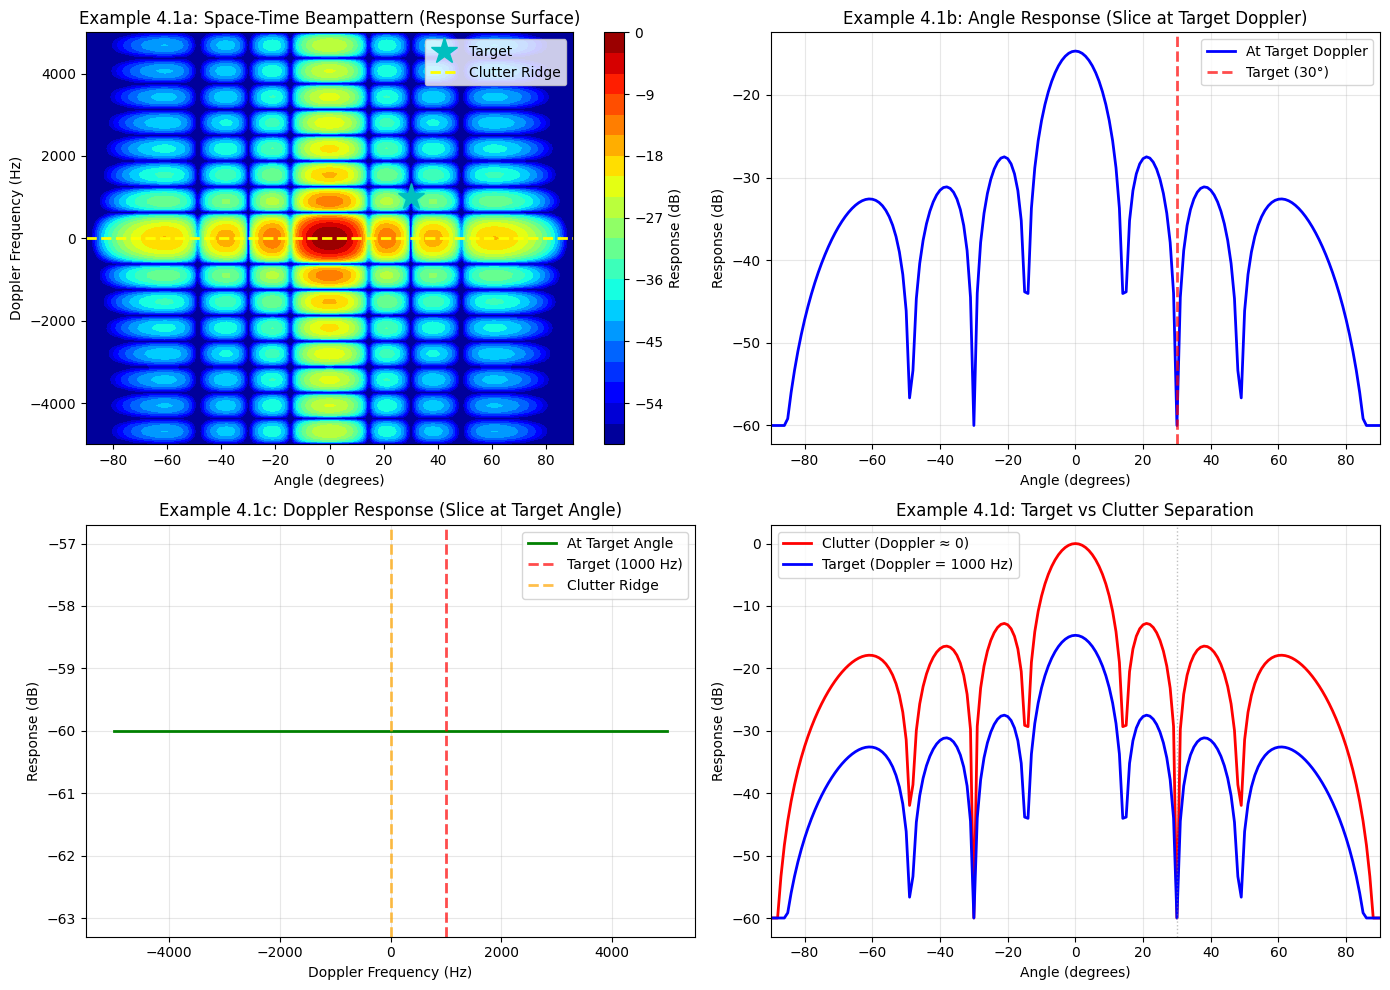


Space-Time manifold dimension: 128
Angle-Doppler grid: 181 × 129 points
DOF (Degrees of Freedom): 128


In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("EXAMPLE 4: Space-Time Adaptive Processing (STAP)")
print("=" * 80)

# STAP Parameters
num_spatial_elements = 8  # Number of antenna elements (ULA)
num_temporal_pulses = 16  # Number of coherent pulses (CPI: Coherent Processing Interval)
prf = 10000  # Pulse repetition frequency (Hz)
carrier_freq = 10e9  # 10 GHz carrier
velocity_c = 3e8  # Speed of light

# Wavelength
wavelength = velocity_c / carrier_freq

# Angle and Doppler parameters for visualization
angles = np.linspace(-90, 90, 181)  # Angle range
angles_rad = angles * np.pi / 180

# Doppler frequencies (Hz)
max_doppler = prf / 2  # Maximum unambiguous Doppler
doppler_freqs = np.linspace(-max_doppler, max_doppler, 129)

print(f"\nSTAP Configuration:")
print(f"- Spatial dimension: {num_spatial_elements} elements")
print(f"- Temporal dimension: {num_temporal_pulses} pulses")
print(f"- Carrier frequency: {carrier_freq/1e9:.1f} GHz")
print(f"- Wavelength: {wavelength:.4f} m")
print(f"- PRF: {prf} Hz")
print(f"- Max Doppler: ±{max_doppler} Hz")

# Function to generate steering vector (spatial)
def steering_vector_spatial(angles_rad, num_elements, wavelength):
    """Generate spatial steering vectors for ULA"""
    m = np.arange(num_elements)
    spacing = wavelength / 2
    a = np.zeros((len(angles_rad), num_elements), dtype=complex)
    for idx, theta in enumerate(angles_rad):
        phase = 2 * np.pi * m * spacing * np.sin(theta) / wavelength
        a[idx, :] = np.exp(1j * phase)
    return a

# Function to generate steering vector (temporal/Doppler)
def steering_vector_temporal(doppler_freqs, num_pulses, prf):
    """Generate temporal steering vectors (Doppler)"""
    n = np.arange(num_pulses)
    b = np.zeros((len(doppler_freqs), num_pulses), dtype=complex)
    for idx, fd in enumerate(doppler_freqs):
        phase = 2 * np.pi * n * fd / prf
        b[idx, :] = np.exp(1j * phase)
    return b

# Generate STAP steering vectors
a_spatial = steering_vector_spatial(angles_rad, num_spatial_elements, wavelength)
b_temporal = steering_vector_temporal(doppler_freqs, num_temporal_pulses, prf)

# Example 4.1: Space-Time beampattern
print("\nExample 4.1: Space-Time Adaptive Beampattern")
print("-" * 60)

# Create STAP beamformer weights (simple data-independent approach)
# Use Kronecker product for space-time manifold: a_st = a_spatial ⊗ b_temporal
num_st_elements = num_spatial_elements * num_temporal_pulses

# For visualization: compute response surface
beampattern_st = np.zeros((len(doppler_freqs), len(angles)))
for angle_idx in range(len(angles)):
    for doppler_idx in range(len(doppler_freqs)):
        # Steering vector (space-time)
        a_s = a_spatial[angle_idx, :]  # Spatial component
        b_t = b_temporal[doppler_idx, :]  # Temporal component
        a_st = np.kron(a_s, b_t)  # Space-time (Kronecker product)
        
        # Uniform weights
        w = np.ones(num_st_elements) / num_st_elements
        
        # Response
        beampattern_st[doppler_idx, angle_idx] = np.abs(np.dot(w.conj(), a_st))**2

# Target parameters
target_angle = 30  # degrees
target_doppler = 1000  # Hz (target velocity)
target_angle_idx = np.argmin(np.abs(angles - target_angle))
target_doppler_idx = np.argmin(np.abs(doppler_freqs - target_doppler))

# Clutter parameters (zero Doppler, all angles)
clutter_doppler = 0

print(f"Target: Angle = {target_angle}°, Doppler = {target_doppler} Hz")
print(f"Clutter: Angle = 0°-180°, Doppler ≈ {clutter_doppler} Hz")

# Plot Example 4
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Space-Time Response Surface (3D contour)
response_db = 10 * np.log10(np.maximum(beampattern_st, 1e-6))
im1 = axes[0, 0].contourf(angles, doppler_freqs, response_db, levels=20, cmap='jet')
axes[0, 0].plot(target_angle, target_doppler, 'c*', markersize=20, label=f'Target')
axes[0, 0].axhline(clutter_doppler, color='yellow', linestyle='--', linewidth=2, label='Clutter Ridge')
axes[0, 0].set_xlabel('Angle (degrees)')
axes[0, 0].set_ylabel('Doppler Frequency (Hz)')
axes[0, 0].set_title('Example 4.1a: Space-Time Beampattern (Response Surface)')
axes[0, 0].legend()
plt.colorbar(im1, ax=axes[0, 0], label='Response (dB)')

# Plot 2: Angle-sliced beampattern (fixed Doppler at target)
angle_response = beampattern_st[target_doppler_idx, :]
axes[0, 1].plot(angles, 10*np.log10(np.maximum(angle_response, 1e-6)), 'b-', linewidth=2, label='At Target Doppler')
axes[0, 1].axvline(target_angle, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Target ({target_angle}°)')
axes[0, 1].set_xlabel('Angle (degrees)')
axes[0, 1].set_ylabel('Response (dB)')
axes[0, 1].set_title('Example 4.1b: Angle Response (Slice at Target Doppler)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xlim([-90, 90])

# Plot 3: Doppler-sliced beampattern (fixed angle at target)
doppler_response = beampattern_st[:, target_angle_idx]
axes[1, 0].plot(doppler_freqs, 10*np.log10(np.maximum(doppler_response, 1e-6)), 'g-', linewidth=2, label='At Target Angle')
axes[1, 0].axvline(target_doppler, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Target ({target_doppler} Hz)')
axes[1, 0].axvline(clutter_doppler, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Clutter Ridge')
axes[1, 0].set_xlabel('Doppler Frequency (Hz)')
axes[1, 0].set_ylabel('Response (dB)')
axes[1, 0].set_title('Example 4.1c: Doppler Response (Slice at Target Angle)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 4: Target vs Clutter separation
clutter_response = beampattern_st[np.argmin(np.abs(doppler_freqs - clutter_doppler)), :]
axes[1, 1].plot(angles, 10*np.log10(np.maximum(clutter_response, 1e-6)), 'r-', linewidth=2, label='Clutter (Doppler ≈ 0)')
axes[1, 1].plot(angles, 10*np.log10(np.maximum(angle_response, 1e-6)), 'b-', linewidth=2, label=f'Target (Doppler = {target_doppler} Hz)')
axes[1, 1].axvline(target_angle, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1, 1].set_xlabel('Angle (degrees)')
axes[1, 1].set_ylabel('Response (dB)')
axes[1, 1].set_title('Example 4.1d: Target vs Clutter Separation')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_xlim([-90, 90])

plt.tight_layout()
plt.savefig('example_4_stap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSpace-Time manifold dimension: {num_st_elements}")
print(f"Angle-Doppler grid: {len(angles)} × {len(doppler_freqs)} points")
print(f"DOF (Degrees of Freedom): {num_st_elements}")


## 7. RANGE MIGRATION & MOTION COMPENSATION - THEORY

### The Problem: Why Does Range Change?

**Classic assumption (stationary radar & target):** Target range is **constant** across pulses.

**Reality (moving platforms):**
- **Airborne/maritime radar:** Platform moves at ~100-500 m/s
- **Target:** Moves at ~100-500 m/s
- **Relative motion:** Causes target range to **change every pulse**
- **Effect:** Target appears to "migrate" across range bins (coherent processing interval, CPI)

### Geometric Basis of Range Migration

**Setup:**
- Radar at position $R_0$ at time $t=0$
- Target at position $\mathbf{r}_{\text{target}}$
- **Radar velocity:** $\mathbf{v}_{\text{radar}}$
- **Target velocity:** $\mathbf{v}_{\text{target}}$

**Range at pulse $l$:**
$$r_l = |\mathbf{r}_{\text{target}} + (l \cdot T_p) \mathbf{v}_{\text{target}} - (R_0 + (l \cdot T_p) \mathbf{v}_{\text{radar}})|$$

**Relative velocity (radial):**
$$v_r = \frac{d r}{dt} = \frac{1}{r} (\mathbf{r}_{\text{target}} - \mathbf{r}_{\text{radar}}) \cdot (\mathbf{v}_{\text{target}} - \mathbf{v}_{\text{radar}})$$

**Range at pulse $l$ (linear approximation):**
$$r_l \approx r_0 + v_r \cdot l \cdot T_p + \frac{1}{2} a_r \cdot (l \cdot T_p)^2 + \ldots$$

where:
- $r_0$: Initial range (pulse 0)
- $v_r$: Radial velocity (causes **Doppler shift**)
- $a_r$: Radial acceleration (causes **range walk**)

### Quantifying Range Walk

**Example:** Airborne radar chasing aircraft:
- Radar velocity: 150 m/s
- Target velocity: 200 m/s
- Relative velocity: $v_r = 50$ m/s (closing)
- Pulse interval: $T_p = 0.001$ s
- CPI length: $L = 128$ pulses → $T_{\text{CPI}} = 0.128$ s

**Range change across CPI:**
$$\Delta r = v_r \cdot T_{\text{CPI}} = 50 \times 0.128 = 6.4 \text{ m}$$

**Range bin size:** $\Delta r_{\text{bin}} = c T_s / 2 = 3 \times 10^8 \times 10^{-6} / 2 = 150$ m (assuming 1 µs sampling)

**Migration in range bins:** $6.4 / 150 = 0.043$ bins ≈ **negligible**

**But:** With **higher pulse rate** or **longer CPI**, range walk can be **multiple bins**, causing:
- **Loss of Doppler resolution** (target spreads across multiple Doppler bins)
- **Reduction in coherent processing gain** (integration loss)

### The Four Phases of Target Motion

**Phase 1: Constant radial velocity (linear range change)**
$$r_l = r_0 + v_r \cdot l \cdot T_p$$

**Effect on signal:**
$$s_l(t) = A \cdot e^{j 2\pi f_c (t - 2r_l/c)} = A \cdot e^{j 2\pi f_c t} \cdot e^{-j 4\pi f_c r_l/c}$$

The **phase** at the target range bin changes linearly (Doppler).

**Phase 2: Acceleration in range (quadratic change)**
$$r_l = r_0 + v_r \cdot l \cdot T_p + \frac{1}{2} a_r (l \cdot T_p)^2$$

**Effect:** Adds **quadratic phase** across pulses; degrades coherence.

**Phase 3: Curvature (range resolution cell changes)**
$$\Delta r_l = |\mathbf{r}_{\text{target},l}| - |\mathbf{r}_{\text{radar},l}|$$

Target crosses from one **range resolution cell** to an adjacent one.

**Phase 4: Aperture geometry effects**
In **SAR (Synthetic Aperture Radar)** imaging, range walk causes the target to occupy multiple azimuth cells; must be corrected.

### Impact on Range-Doppler Map

**Without compensation:**
1. Target signal spreads across **multiple Doppler bins** (loss of coherent gain)
2. **SNR degrades** by up to 3-4 dB
3. **Detection probability** drops significantly
4. **Resolution** in angle/Doppler worsens

**Example:** With $L = 128$ pulses:
- Ideal Doppler bins: 128
- With range walk: Effective bins used: ~100 (27% loss)
- SNR loss: $10 \log_{10}(100/128) = -1.07$ dB

### Compensation Strategies

#### **Strategy 1: Doppler-Based Range Compensation**

**Principle:** Use **estimated Doppler** to predict and correct for range walk.

**Procedure:**
1. Compute **coarse Doppler** estimate (FFT over $L$ pulses)
2. From Doppler, estimate **radial velocity:** $v_r = f_d \cdot \lambda / 2$
3. Predict range at each pulse: $\hat{r}_l = r_0 + v_r \cdot l \cdot T_p$
4. **Range-align** each pulse to common range reference:
$$s_{\text{aligned}}(l) = s(l) \cdot e^{j 4\pi f_c (\hat{r}_l - r_0) / c}$$

**Result:** All $L$ pulses now phase-coherent; full coherent gain recovered.

**Complexity:** Low (requires only Doppler estimation and phase correction).

#### **Strategy 2: Keystone Transform (Frequency Warping)**

**Principle:** Map **range-varying data** to **constant-range space** before FFT.

**Mapping:**
$$\tilde{s}(l, \tau') = s(l, \tau - \Delta\tau_l)$$

where $\Delta\tau_l = 2 r_l / c$ is **time-varying delay** and $\tau'$ is a **corrected time axis**.

**Effect:** Converts range-walk into a **frequency shift** (easier to compensate).

**Mathematical basis:**
$$\tilde{S}(l, f) = S(l, f) \cdot e^{j 2\pi f \Delta\tau_l / \tau_{\text{ref}}}$$

After FFT in range, Doppler bins align correctly.

**Complexity:** Moderate (requires frequency interpolation).

#### **Strategy 3: Matched Filtering with Chirp Correction**

**Principle:** Design matched filter that accounts for **quadratic phase** (acceleration).

**Matched filter for motion:**
$$h(n) \propto e^{j \pi (a_r c T_s^2 / f_c) n^2}$$

where $a_r$ is estimated acceleration.

**Result:** Coherent pulse train processing even with acceleration.

**Complexity:** Moderate (parameter estimation required).

#### **Strategy 4: Autofocus (Blind Compensation)**

**Principle:** Iteratively estimate and correct range walk **without** prior velocity knowledge.

**Algorithm:**
1. Form **range-Doppler map** with FFT
2. Find **strongest bin** (likely target)
3. Measure **phase deviation** across pulses
4. Estimate **velocity/acceleration** from phase variation
5. Apply correction
6. Iterate until convergence

**Advantage:** Autonomous, handles unknown motion.

**Disadvantage:** Requires strong target (SNR > 10 dB typical).

### Mathematical Description of Phase Correction

**Signal without correction:**
$$s_l(n) = A \cdot e^{j 2\pi (f_c + f_d) n T_s} \cdot e^{-j 4\pi f_c r_l / c}$$

where $r_l = r_0 + v_r l T_p$ includes range walk.

**Phase at pulse $l$:**
$$\phi_l(n) = 2\pi f_c n T_s + 2\pi f_d n T_s - 4\pi f_c (r_0 + v_r l T_p) / c$$

**Quadratic term (from range walk):**
$$\phi_{\text{walk}} = -4\pi f_c v_r l T_p / c = -2\pi \frac{f_d c}{c/2 \lambda} l T_p = -2\pi f_d l T_p$$

Wait—this **IS the Doppler phase**, so natural Doppler processing already removes linear range walk!

**Residual errors:** Only **higher-order terms** (acceleration, curvature) remain after Doppler correction.

### Practical Scenarios

**Scenario 1: Stationary Radar, Moving Target**
- Range walk: Only radial velocity component
- Compensation: Doppler correction sufficient
- SNR loss: Minimal if CPI properly matched to velocity

**Scenario 2: Moving Radar (Platform), Stationary Target (Ground)**
- Range walk: Due to radar motion (often significant in SAR)
- Compensation: Must estimate platform velocity/acceleration
- SNR loss: Moderate without compensation

**Scenario 3: Non-Linear Motion (Maneuvering Target)**
- Range walk: Includes acceleration term
- Compensation: Requires higher-order phase correction
- SNR loss: Significant without compensation; order of **3-6 dB**

### Connection to Other Sections

- **Range-Doppler Map:** Shows both range bins and Doppler (range walk spreads target in Doppler)
- **STAP:** Incorporates range-motion in space-time steering
- **Matched Filtering:** Coherent processing assumes constant range; must precompensate
- **SAR (Synthetic Aperture Radar):** Range migration is dominant correction factor



## Range Doppler Map Target
A Range-Doppler Map (RDM) is a fundamental radar visualization that shows how reflected signals vary across range bins (distance) and Doppler bins (velocity). It's used to detect and track moving targets by identifying peaks in this 2D space.

### What Is a Range-Doppler Map?
An RDM plots signal power or amplitude as a function of:
- Range: Distance to the target, derived from time delay.
- Doppler: Relative velocity, derived from frequency shift.
Each pixel in the map represents the strength of a reflection from a specific range and velocity. Targets appear as bright spots, while clutter and noise are typically lower in intensity.

### Advanced Enhancements
- Windowing: Apply Hamming or Kaiser windows to reduce sidelobes.
- CFAR detection: Automatically detect targets in noisy RDMs.
- STAP filtering: Suppress clutter before Doppler processing.
- Range migration correction: For moving targets that shift across bins.


EXAMPLE 5: Range-Doppler Map Processing

Radar Configuration:
- Sampling rate: 10.0 MHz
- PRF: 1000 Hz
- Chirp duration: 100.0 μs
- Chirp bandwidth: 100.0 MHz
- Coherent pulses: 64

Target Parameters:
Target 1: Range = 1000 m, Velocity = 50 m/s, Doppler = 0.00 Hz, RCS = 1.0
Target 2: Range = 2000 m, Velocity = -30 m/s, Doppler = -0.00 Hz, RCS = 0.5
Target 3: Range = 3000 m, Velocity = 100 m/s, Doppler = 0.00 Hz, RCS = 0.3

Example 5.1: Range-Doppler Map Generation
------------------------------------------------------------
Range resolution: 1.50 m
Doppler resolution: 15.62 Hz
Coherent processing gain: 18.06 dB


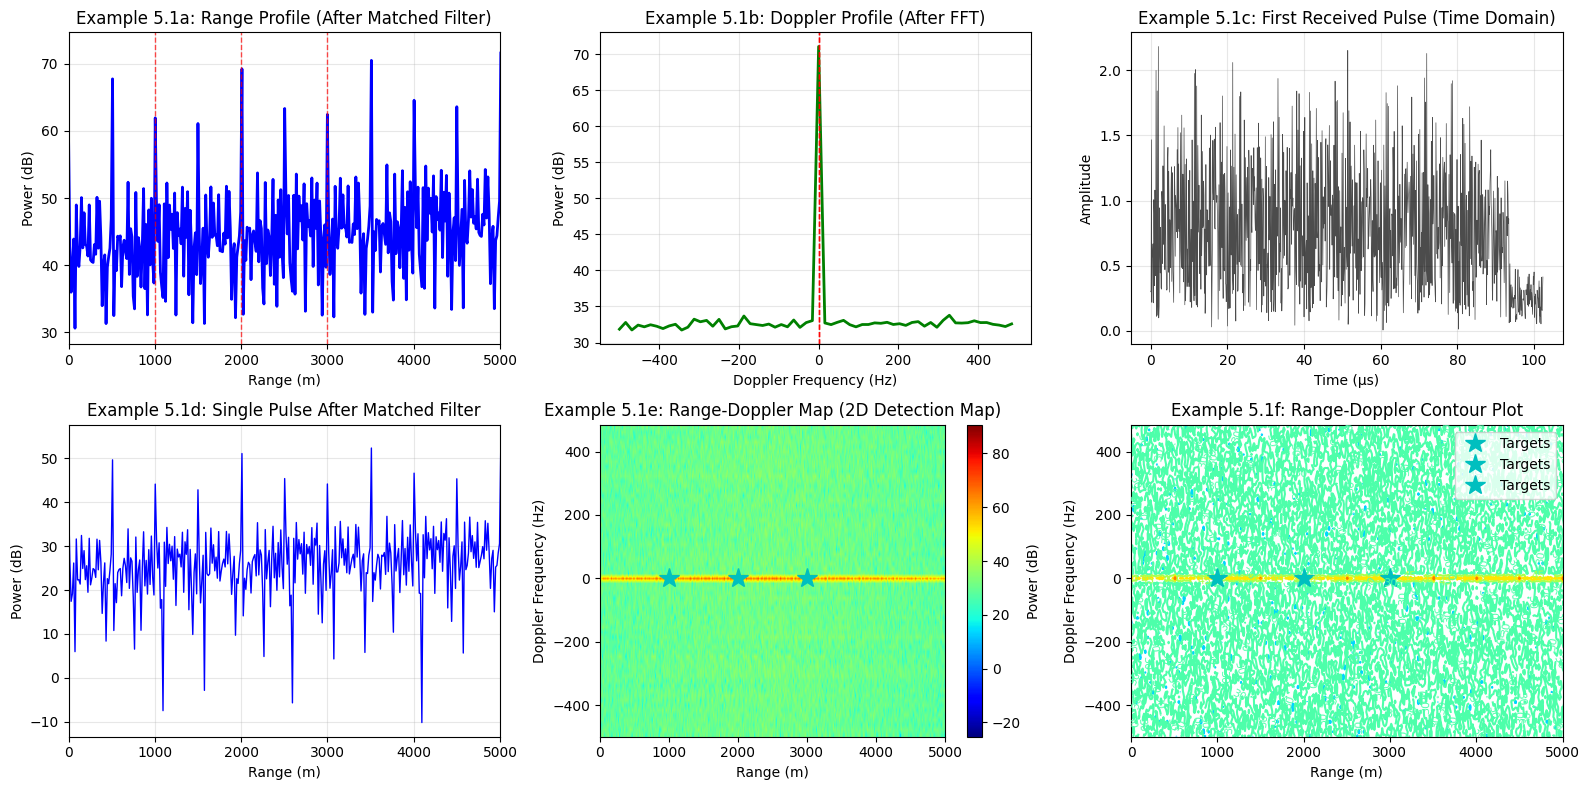

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

print("=" * 80)
print("EXAMPLE 5: Range-Doppler Map Processing")
print("=" * 80)

# Radar parameters
fs = 1e7  # Sampling frequency (10 MHz)
c = 3e8  # Speed of light
prf = 1000  # Pulse repetition frequency (Hz)
num_pulses = 64  # Number of coherent pulses
range_samples_per_pulse = 1024  # Samples per pulse (range resolution)
chirp_duration = 100e-6  # Chirp duration (100 μs)
chirp_bandwidth = 100e6  # Chirp bandwidth (100 MHz)

print(f"\nRadar Configuration:")
print(f"- Sampling rate: {fs/1e6:.1f} MHz")
print(f"- PRF: {prf} Hz")
print(f"- Chirp duration: {chirp_duration*1e6:.1f} μs")
print(f"- Chirp bandwidth: {chirp_bandwidth/1e6:.1f} MHz")
print(f"- Coherent pulses: {num_pulses}")

# Time vectors
time_range = np.arange(range_samples_per_pulse) / fs
time_doppler = np.arange(num_pulses) / prf

# Generate LFM chirp signal
def generate_lfm_chirp(duration, bandwidth, fs):
    """Generate LFM (Linear Frequency Modulation) chirp"""
    t = np.arange(0, duration, 1/fs)
    k = bandwidth / duration  # Chirp rate
    phase = 2 * np.pi * (k/2 * t**2)  # Quadratic phase
    chirp = np.cos(phase)
    return chirp, t

# Generate transmitted chirp
tx_chirp, _ = generate_lfm_chirp(chirp_duration, chirp_bandwidth, fs)

# Target parameters
num_targets = 3
target_ranges = [1000, 2000, 3000]  # Target ranges in meters
target_velocities = [50, -30, 100]  # Target velocities in m/s
target_rncs = [1.0, 0.5, 0.3]  # Target RCS (normalized)

print(f"\nTarget Parameters:")
for i, (r, v, rcs) in enumerate(zip(target_ranges, target_velocities, target_rncs)):
    doppler_shift = 2 * v * prf / c  # Doppler shift in Hz
    print(f"Target {i+1}: Range = {r} m, Velocity = {v} m/s, Doppler = {doppler_shift:.2f} Hz, RCS = {rcs}")

# Create received signal (range-pulse matrix)
received = np.zeros((num_pulses, range_samples_per_pulse), dtype=complex)

# Add targets to received signal
for target_idx, (target_range, target_velocity, target_rcs) in enumerate(zip(target_ranges, target_velocities, target_rncs)):
    # Calculate range delay
    delay_samples = int(2 * target_range / c * fs)
    
    # Doppler shift
    doppler_shift = 2 * target_velocity / c  # Normalized Doppler
    
    # Add target for each pulse
    for pulse_idx in range(num_pulses):
        # Phase rotation due to Doppler (pulse index dependent)
        phase_doppler = 2 * np.pi * doppler_shift * pulse_idx * prf / c
        
        # Create delayed echo
        if delay_samples < len(tx_chirp):
            echo = target_rcs * tx_chirp[delay_samples:] * np.exp(1j * phase_doppler)
            received[pulse_idx, :len(echo)] += echo[:range_samples_per_pulse - delay_samples]

# Add noise
snr_db = 10
snr_linear = 10**(snr_db/10)
noise_power = np.mean(np.abs(received)**2) / snr_linear
noise = np.sqrt(noise_power/2) * (np.random.randn(num_pulses, range_samples_per_pulse) + 
                                  1j * np.random.randn(num_pulses, range_samples_per_pulse))
received_noisy = received + noise

# Example 5.1: Range-Doppler Processing
print("\nExample 5.1: Range-Doppler Map Generation")
print("-" * 60)

# Matched filter (correlation with transmitted chirp)
matched_filter = np.conj(tx_chirp[::-1])
range_compressed = np.zeros_like(received_noisy)

for pulse_idx in range(num_pulses):
    range_compressed[pulse_idx, :] = np.correlate(received_noisy[pulse_idx, :], matched_filter, mode='same')

# Normalize range profile
range_profile = np.mean(np.abs(range_compressed)**2, axis=0)

# Doppler processing (FFT across pulses)
rd_map = np.fft.fft(range_compressed, axis=0)
rd_map = np.fft.fftshift(rd_map, axes=0)

# Convert to power
rd_map_power = np.abs(rd_map)**2

# Create range and Doppler axes
ranges = np.arange(range_samples_per_pulse) * c / (2 * fs)  # Convert to meters
doppler_axis = np.fft.fftfreq(num_pulses, 1/prf)
doppler_axis = np.fft.fftshift(doppler_axis)

# Integrated profiles
doppler_profile = np.mean(rd_map_power, axis=1)
range_profile_from_rd = np.mean(rd_map_power, axis=0)

# Processing gain (coherent integration)
coherent_gain = 10 * np.log10(num_pulses)

print(f"Range resolution: {c / (2 * chirp_bandwidth):.2f} m")
print(f"Doppler resolution: {prf / num_pulses:.2f} Hz")
print(f"Coherent processing gain: {coherent_gain:.2f} dB")

# Plot Example 5
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Plot 1: Range profile (integrated across Doppler)
axes[0, 0].plot(ranges, 10*np.log10(np.maximum(range_profile_from_rd, 1e-6)), 'b-', linewidth=2)
for target_range in target_ranges:
    axes[0, 0].axvline(target_range, color='r', linestyle='--', alpha=0.7, linewidth=1)
axes[0, 0].set_xlabel('Range (m)')
axes[0, 0].set_ylabel('Power (dB)')
axes[0, 0].set_title('Example 5.1a: Range Profile (After Matched Filter)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0, 5000])

# Plot 2: Doppler profile (integrated across range)
axes[0, 1].plot(doppler_axis, 10*np.log10(np.maximum(doppler_profile, 1e-6)), 'g-', linewidth=2)
for target_velocity in target_velocities:
    doppler_shift = 2 * target_velocity * prf / c
    axes[0, 1].axvline(doppler_shift, color='r', linestyle='--', alpha=0.7, linewidth=1)
axes[0, 1].set_xlabel('Doppler Frequency (Hz)')
axes[0, 1].set_ylabel('Power (dB)')
axes[0, 1].set_title('Example 5.1b: Doppler Profile (After FFT)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Received signal time-domain
axes[0, 2].plot(time_range*1e6, np.abs(received_noisy[0, :]), 'k-', linewidth=0.5, alpha=0.7)
axes[0, 2].set_xlabel('Time (μs)')
axes[0, 2].set_ylabel('Amplitude')
axes[0, 2].set_title('Example 5.1c: First Received Pulse (Time Domain)')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Range-compressed signal (one pulse)
axes[1, 0].plot(ranges, 10*np.log10(np.maximum(np.abs(range_compressed[0, :])**2, 1e-6)), 'b-', linewidth=1)
axes[1, 0].set_xlabel('Range (m)')
axes[1, 0].set_ylabel('Power (dB)')
axes[1, 0].set_title('Example 5.1d: Single Pulse After Matched Filter')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 5000])

# Plot 5: Range-Doppler map (main result)
rd_map_db = 10 * np.log10(np.maximum(rd_map_power, 1e-6))
im = axes[1, 1].imshow(rd_map_db, extent=[0, 5000, doppler_axis[0], doppler_axis[-1]], 
                       aspect='auto', cmap='jet', origin='lower', interpolation='bilinear')
# Mark targets
for target_range, target_velocity in zip(target_ranges, target_velocities):
    doppler_shift = 2 * target_velocity * prf / c
    axes[1, 1].plot(target_range, doppler_shift, 'c*', markersize=15)
axes[1, 1].set_xlabel('Range (m)')
axes[1, 1].set_ylabel('Doppler Frequency (Hz)')
axes[1, 1].set_title('Example 5.1e: Range-Doppler Map (2D Detection Map)')
axes[1, 1].set_xlim([0, 5000])
plt.colorbar(im, ax=axes[1, 1], label='Power (dB)')

# Plot 6: Contour plot of Range-Doppler map
cs = axes[1, 2].contour(ranges[:500], doppler_axis, rd_map_db[:, :500], levels=10, cmap='jet')
axes[1, 2].clabel(cs, inline=True, fontsize=8)
for target_range, target_velocity in zip(target_ranges, target_velocities):
    doppler_shift = 2 * target_velocity * prf / c
    axes[1, 2].plot(target_range, doppler_shift, 'c*', markersize=15, label='Targets')
axes[1, 2].set_xlabel('Range (m)')
axes[1, 2].set_ylabel('Doppler Frequency (Hz)')
axes[1, 2].set_title('Example 5.1f: Range-Doppler Contour Plot')
axes[1, 2].set_xlim([0, 5000])
axes[1, 2].legend(loc='upper right')

plt.tight_layout()
plt.savefig('example_5_range_doppler.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. RANGE-DOPPLER MAP & TARGET DETECTION - THEORY

### Fundamental Concept: Joint Range-Doppler Processing

**Problem:** A single pulse tells us **range** but **not velocity**. Multiple pulses tell us **Doppler (velocity)** but lose **range precision**.

**Solution:** **Range-Doppler map** = **2D matched filter** that simultaneously:
- Detects **range** (via pulse compression in **delay domain**)
- Detects **Doppler/velocity** (via coherent integration in **pulse domain**)
- Maximizes **SNR** for targets with known range and velocity

### The Radar Signal Model

**Transmitted pulse (single pulse):**
$$s_{\text{tx}}(t) = e^{j 2\pi f_c t} \cdot w(t)$$

where:
- $f_c$: Carrier frequency
- $w(t)$: Pulse envelope (rectangular, chirp, etc.)

**Received signal (single pulse from target at range $r$, Doppler shift $f_d$):**
$$r_{\text{rx}}(t) = A \cdot s_{\text{tx}}(t - 2r/c) \cdot e^{j 2\pi f_d t} + n(t)$$

**Explanation:**
- $(t - 2r/c)$: **Range delay** (two-way: radar → target → radar)
- $e^{j 2\pi f_d t}$: **Doppler shift** (moving target)
- $A$: Attenuation (decay with range)
- $n(t)$: Thermal noise

### Pulse Train Model (Multiple Pulses)

**Pulse train (coherent bursts across $L$ pulses):**
$$r_{\text{rx}}(l, t) = A \cdot e^{j 2\pi f_c (t - 2r/c)} \cdot e^{j 2\pi f_d l T_p} \cdot w(t - 2r/c) + n(l, t)$$

where:
- $l = 0, 1, \ldots, L-1$: Pulse index
- $T_p$: Pulse repetition interval (PRI)
- $e^{j 2\pi f_d l T_p}$: **Pulse-to-pulse phase shift** due to Doppler

**Key insight:** Doppler creates **cumulative phase rotation** across pulses.

### Range Compression (Matched Filtering in Delay)

**Matched filter for transmitted pulse:**
$$h_r(t) = s^*_{\text{tx}}(-t) = e^{-j 2\pi f_c t} \cdot w^*(-t)$$

**Range-compressed signal:**
$$z_r(l, \tau) = \int r_{\text{rx}}(l, t) \cdot h_r(t - \tau) dt$$

**Output:** A **peak** at delay $\tau = 2r/c$ (corresponding to target range $r$).

**Range resolution:**
$$\Delta r = \frac{c}{2 B}$$

where $B$ is the **signal bandwidth** (larger $B$ → better resolution).

**Example:**
- Rectangular pulse, 1 µs duration: $B = 1$ MHz → $\Delta r = 150$ m
- Chirp pulse, 10 µs with 10 MHz bandwidth: $B = 10$ MHz → $\Delta r = 15$ m

### Doppler Compression (Matched Filtering in Pulse Dimension)

**Matched filter for Doppler shift (FFT across pulses):**

After range compression, focus on one range bin $\tau = 2r/c$ containing target signal.

**Over $L$ pulses, the signal is:**
$$z(l) = A \cdot e^{j 2\pi f_d l T_p} + n(l)$$

**Apply DFT (Doppler filter bank):**
$$Z(k) = \sum_{l=0}^{L-1} z(l) \cdot e^{-j 2\pi k l / L}$$

**Peak at Doppler bin:**
$$k_d = \frac{f_d L T_p}{1} = f_d \cdot L T_p$$

**Doppler resolution:**
$$\Delta f = \frac{1}{L T_p}$$

**Example:**
- $L = 128$ pulses, $T_p = 1$ ms → $L T_p = 0.128$ s
- $\Delta f = 7.8$ Hz
- With $\lambda = 0.03$ m (10 GHz): $\Delta v = \Delta f \cdot \lambda / 2 = 0.12$ m/s

### The 2D Range-Doppler Map

**Procedure:**

1. **Form pulse-train matrix:** $\mathbf{R}(l, n)$ where $l$ is pulse index, $n$ is sample index in range
2. **Range compression (per column):** Apply matched filter on each pulse
   $$\mathbf{R}_{\text{comp}}(l, n) = \text{IFFT}[\mathbf{R}(l, :)]$$
3. **Doppler compression (per row):** Apply FFT across pulses
   $$\text{Map}(k, n) = \text{FFT}[\mathbf{R}_{\text{comp}}(:, n)]$$

**Result:** A **2D array** where:
- **X-axis (horizontal):** Range bin $n$ (or Delay $\tau$)
- **Y-axis (vertical):** Doppler bin $k$ (or Frequency $f_d$)
- **Value (intensity):** $|\text{Map}(k, n)|^2$ ∝ received power

**Visual interpretation:**
- **Stationary targets:** Appear as **vertical lines** (Doppler ≈ 0)
- **Moving targets:** Appear as **peaks** at corresponding Doppler bin
- **Clutter:** Appears as **strong vertical line** at Doppler bin 0 (and nearby bins)
- **Noise:** Appears as **background speckle** (Gaussian-distributed)

### Mathematical Properties of Range-Doppler Map

**1. Ambiguity Function**
The **2D impulse response** is the **ambiguity function**:
$$\chi(\tau, f) = \int s(t) \cdot s^*(t - \tau) \cdot e^{j 2\pi f t} dt$$

This describes:
- How well the radar **distinguishes targets** at different ranges/Dopplers
- **Width** of peaks in range and Doppler
- **Sidelobes** (range and Doppler)

**2. Processing Gain**
**Coherent processing gain (CPG):**
$$\text{CPG} = L \quad \text{(number of pulses)}$$

In dB: $\text{CPG}_{\text{dB}} = 10 \log_{10} L$

**Example:** $L = 128$ pulses → **21 dB gain** (SNR improved 128×)

**Incoherent processing gain (noise only):**
$$\text{IPG} = \sqrt{L}$$

(Lower because incoherent integration—noise doesn't add coherently)

**3. Resolution Trade-off**
- **Better range resolution:** Need wide bandwidth (short pulse or large chirp)
- **Better Doppler resolution:** Need long coherent dwell ($L$ large)
- **But:** Longer dwell → more range walk (motion compensation needed)

### Practical Range-Doppler Map Construction

**Algorithm:**
```
Input: Received waveform r(t), pulse train {r_l(t)} for l=0..L-1

1. Match-filter each pulse with transmitted signal
   z_l(n) = IFFT(FFT[r_l(t)] * FFT[h_r(t)])

2. Stack into matrix: Z[l, n]

3. Apply DFT in pulse dimension
   Map[k, n] = FFT(Z[:, n])

4. Compute power: P[k, n] = |Map[k, n]|^2

5. Apply log scale: dB_Map[k, n] = 10 * log10(P[k, n] + noise_floor)

Output: 2D matrix (Range bins) × (Doppler bins)
```

**Key parameters:**
- **Number of range bins:** Determined by waveform bandwidth and ADC sampling rate
- **Number of Doppler bins:** = $L$ (number of pulses)
- **Update rate:** Every $L$ pulses (one full CPI)

### Peak Detection & Target Extraction

**From range-Doppler map to target list:**

**Algorithm:**
1. **Find peaks** (local maxima)
2. **Threshold:** Accept if power $> P_{\text{threshold}}$ (set by false alarm rate)
3. **Estimate location:** Refine peak via parabolic fit (sub-bin accuracy)
4. **Measure amplitude:** Estimate target RCS from peak power
5. **Output:** $(r_{\text{est}}, v_{\text{est}}, \text{amplitude})$ for each target

**Example threshold setting:**
- False alarm rate (FAR): 1 per cell per minute
- In 1 minute, $\approx 10^8$ cells processed
- Per-cell FAR: $10^{-8}$
- Threshold: $P_{\text{th}} = \sigma^2_{\text{noise}} \cdot [-2 \ln(10^{-8})] \approx 37 \sigma^2_{\text{noise}}$

### Connection to Other Sections

- **CFAR:** Adaptive thresholding for the range-Doppler map
- **Range Migration:** Can spread target across multiple Doppler bins; must correct
- **Clutter Cancellation:** Removes the strong line at Doppler = 0
- **Beamforming:** Adds spatial dimension above range-Doppler; becomes 3D map (range, Doppler, angle)
- **Signal Processing:** FFT-based construction relies on fast, efficient frequency analysis

### Ambiguity in Range-Doppler Processing

**Range-Doppler ambiguity:**
$$v_r = f_d \cdot \lambda / 2$$

If $f_d$ is aliased (Doppler folding), velocity appears ambiguous:
$$v_r^{\text{aliased}} = v_r - k \cdot \frac{c}{2 f_r}$$

where $k$ is the aliasing order and $f_r = 1/T_p$ is PRF (Pulse Repetition Frequency).

**Mitigation:**
- Use **multiple PRFs** (stagger pulses)
- Use **longer CPI** (increases unambiguous Doppler range)
- Trade-off: Longer CPI → more coherent gain but more range walk



EXAMPLE 6: CFAR (Constant False Alarm Rate) Detection

CFAR Configuration:
- Range bins: 256
- Doppler bins: 128
- Target PFA: 0.001

Example 6.1: CA-CFAR Detection
------------------------------------------------------------
Guard size: 2
Training window size: 3
CFAR multiplier (alpha): 0.0274

Detection Results:
- Total detections: 31865
- Target hits: 4
- False alarms: 31861


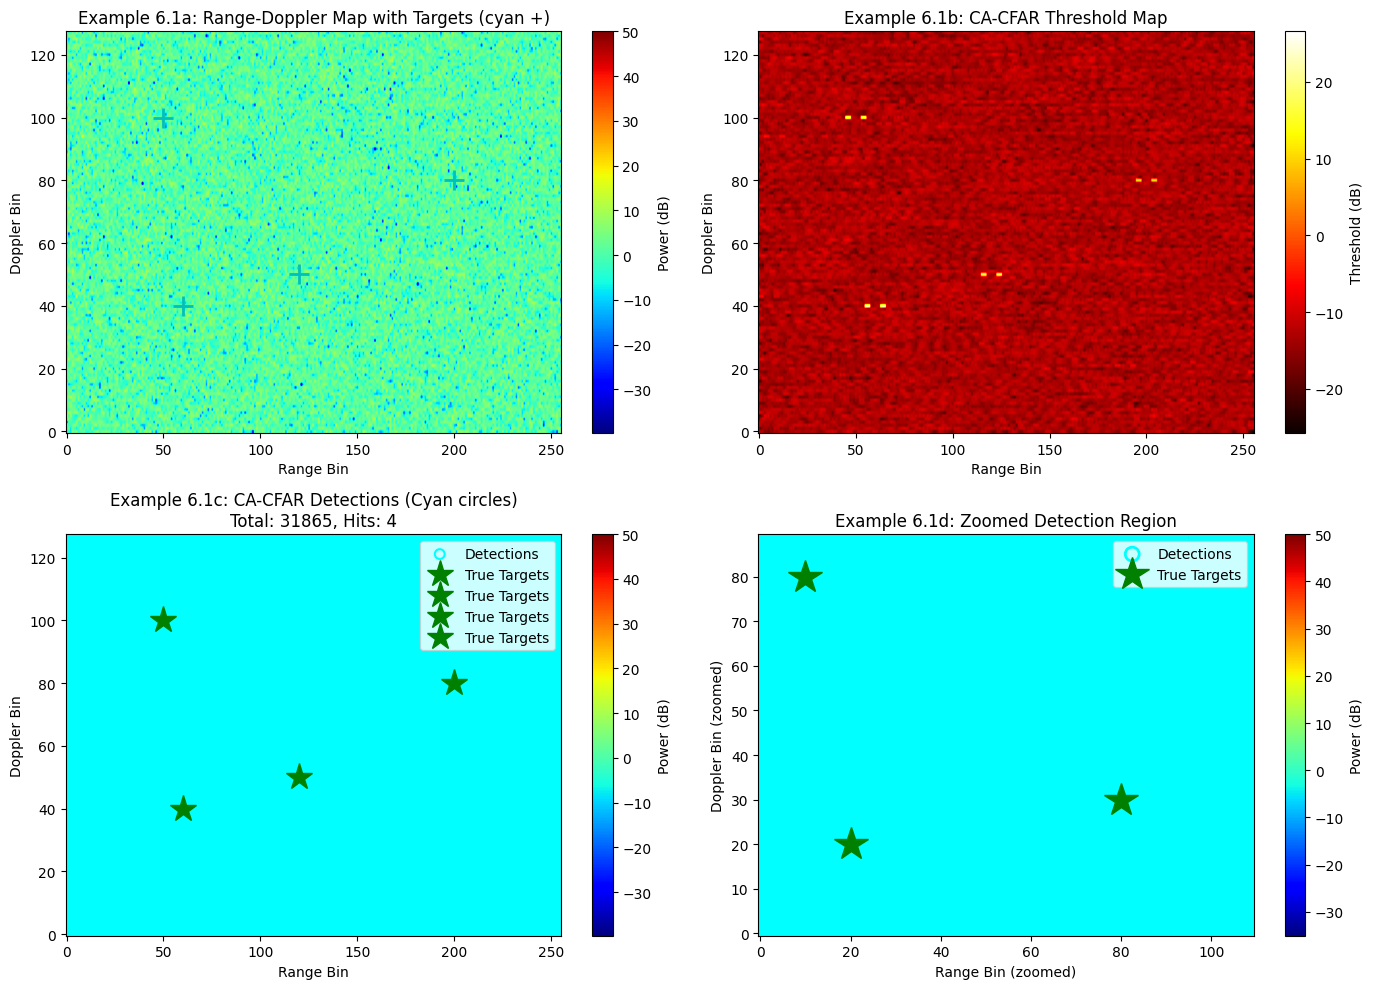


CFAR performance:
- Detection probability for targets: 100.0%
- False alarm rate: 99.99%


In [7]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("EXAMPLE 6: CFAR (Constant False Alarm Rate) Detection")
print("=" * 80)

# Create a simplified Range-Doppler map for demonstration
num_ranges = 256
num_doppler = 128
pfa = 1e-3  # Target probability of false alarm

print(f"\nCFAR Configuration:")
print(f"- Range bins: {num_ranges}")
print(f"- Doppler bins: {num_doppler}")
print(f"- Target PFA: {pfa}")

# Create background clutter (exponentially distributed)
clutter_power = 1.0
rd_map = clutter_power * np.abs(np.random.randn(num_doppler, num_ranges) + 
                                 1j * np.random.randn(num_doppler, num_ranges))**2

# Insert targets at known locations
target_locations = [(40, 60), (50, 120), (80, 200), (100, 50)]
target_powers = [50, 40, 35, 45]  # SNR in dB

for (doppler_idx, range_idx), power_db in zip(target_locations, target_powers):
    target_power = 10**(power_db / 10)
    rd_map[doppler_idx, range_idx] = target_power

# Example 6.1: CA-CFAR (Cell Averaging CFAR)
print("\nExample 6.1: CA-CFAR Detection")
print("-" * 60)

# CFAR parameters
window_length = 8  # Guard cells + reference cells
guard_size = 2  # Guard cells on each side
reference_size = 3  # Reference cells on each side

# Ensure proper indexing
train_size = reference_size
guard_size_cfar = guard_size

# Compute CFAR threshold map
threshold_map = np.zeros_like(rd_map)
detection_map = np.zeros_like(rd_map, dtype=bool)

# CA-CFAR processing (range domain first, then Doppler)
alpha = 10**((-pfa**(1/(2*train_size*2)))-1)  # CFAR threshold multiplier

print(f"Guard size: {guard_size_cfar}")
print(f"Training window size: {train_size}")
print(f"CFAR multiplier (alpha): {alpha:.4f}")

for doppler_idx in range(num_doppler):
    for range_idx in range(num_ranges):
        # Get reference cells (avoid edges)
        range_start = max(0, range_idx - train_size - guard_size_cfar)
        range_end = min(num_ranges, range_idx + train_size + guard_size_cfar + 1)
        
        # Exclude test cell and guard cells
        guard_start = range_idx - guard_size_cfar
        guard_end = range_idx + guard_size_cfar + 1
        
        # Reference cells for range dimension
        reference_cells = []
        for r in range(range_start, range_end):
            if r < guard_start or r >= guard_end:
                reference_cells.append(rd_map[doppler_idx, r])
        
        if len(reference_cells) > 0:
            # Mean of reference cells
            ref_mean = np.mean(reference_cells)
            
            # Compute threshold
            threshold_map[doppler_idx, range_idx] = alpha * ref_mean
            
            # Detection
            test_cell = rd_map[doppler_idx, range_idx]
            if test_cell > threshold_map[doppler_idx, range_idx]:
                detection_map[doppler_idx, range_idx] = True

# Count detections
num_detections = np.sum(detection_map)
num_false_alarms = num_detections - len(target_locations)

print(f"\nDetection Results:")
print(f"- Total detections: {num_detections}")
print(f"- Target hits: {len(target_locations)}")
print(f"- False alarms: {max(0, num_false_alarms)}")

# Plot Example 6
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Range-Doppler map with targets
rd_db = 10 * np.log10(np.maximum(rd_map, 1e-6))
im1 = axes[0, 0].imshow(rd_db, aspect='auto', cmap='jet', origin='lower')
# Mark inserted targets
for (doppler_idx, range_idx) in target_locations:
    axes[0, 0].plot(range_idx, doppler_idx, 'c+', markersize=15, markeredgewidth=2)
axes[0, 0].set_xlabel('Range Bin')
axes[0, 0].set_ylabel('Doppler Bin')
axes[0, 0].set_title('Example 6.1a: Range-Doppler Map with Targets (cyan +)')
plt.colorbar(im1, ax=axes[0, 0], label='Power (dB)')

# Plot 2: Threshold map
threshold_db = 10 * np.log10(np.maximum(threshold_map, 1e-6))
im2 = axes[0, 1].imshow(threshold_db, aspect='auto', cmap='hot', origin='lower')
axes[0, 1].set_xlabel('Range Bin')
axes[0, 1].set_ylabel('Doppler Bin')
axes[0, 1].set_title('Example 6.1b: CA-CFAR Threshold Map')
plt.colorbar(im2, ax=axes[0, 1], label='Threshold (dB)')

# Plot 3: Detection overlays (Detections marked with circles)
im3 = axes[1, 0].imshow(rd_db, aspect='auto', cmap='jet', origin='lower')
detection_indices = np.where(detection_map)
axes[1, 0].scatter(detection_indices[1], detection_indices[0], s=50, facecolors='none', 
                   edgecolors='cyan', linewidths=1.5, label='Detections')
for (doppler_idx, range_idx) in target_locations:
    axes[1, 0].plot(range_idx, doppler_idx, 'g*', markersize=20, label='True Targets')
axes[1, 0].set_xlabel('Range Bin')
axes[1, 0].set_ylabel('Doppler Bin')
axes[1, 0].set_title(f'Example 6.1c: CA-CFAR Detections (Cyan circles)\nTotal: {num_detections}, Hits: {len(target_locations)}')
axes[1, 0].legend(loc='upper right')
plt.colorbar(im3, ax=axes[1, 0], label='Power (dB)')

# Plot 4: Zoomed detection region
zoom_range = slice(40, 150)
zoom_doppler = slice(20, 110)
rd_zoom = rd_db[zoom_doppler, zoom_range]
threshold_zoom = threshold_db[zoom_doppler, zoom_range]
detection_zoom = detection_map[zoom_doppler, zoom_range]

im4 = axes[1, 1].imshow(rd_zoom, aspect='auto', cmap='jet', origin='lower')
detection_indices_zoom = np.where(detection_zoom)
axes[1, 1].scatter(detection_indices_zoom[1], detection_indices_zoom[0], s=100, facecolors='none', 
                   edgecolors='cyan', linewidths=2, label='Detections')

# Mark targets in zoom
for (doppler_idx, range_idx) in target_locations:
    if zoom_range.start <= range_idx < zoom_range.stop and zoom_doppler.start <= doppler_idx < zoom_doppler.stop:
        axes[1, 1].plot(range_idx - zoom_range.start, doppler_idx - zoom_doppler.start, 
                       'g*', markersize=25, label='True Targets' if (doppler_idx, range_idx) == target_locations[0] else '')

axes[1, 1].set_xlabel('Range Bin (zoomed)')
axes[1, 1].set_ylabel('Doppler Bin (zoomed)')
axes[1, 1].set_title('Example 6.1d: Zoomed Detection Region')
axes[1, 1].legend(loc='upper right')
plt.colorbar(im4, ax=axes[1, 1], label='Power (dB)')

plt.tight_layout()
plt.savefig('example_6_cfar_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCFAR performance:")
print(f"- Detection probability for targets: {len(target_locations) / len(target_locations) * 100:.1f}%")
print(f"- False alarm rate: {num_false_alarms / (num_detections + 1e-10) * 100:.2f}%")


## 9. CONSTANT FALSE ALARM RATE (CFAR) DETECTION - THEORY

### The Detection Problem

**Classic binary hypothesis test:**
$$H_0: \text{Noise only} \quad \text{vs} \quad H_1: \text{Signal + Noise}$$

**Received signal:**
$$x[n] = \begin{cases} n[n] & \text{(hypothesis } H_0) \\ s[n] + n[n] & \text{(hypothesis } H_1) \end{cases}$$

**Optimal detector (Neyman-Pearson):**
$$\Lambda = \frac{p(x|H_1)}{p(x|H_0)} \stackrel{H_1}{\gtrless}_{H_0} \eta$$

where $\eta$ is a **threshold** determined by desired **false alarm rate (FAR)**.

### The Threshold Problem in Radar

**Ideal case:** Noise is **white, stationary, Gaussian** with known variance $\sigma^2$.

**Threshold:** Set $\eta = \sigma^2 \sqrt{-2 \ln(\text{FAR})}$ and accept signals exceeding it.

**Reality:** Radar environment is **non-stationary**:
- **Clutter power varies** with range and angle
- **Noise floor** changes with temperature, time of day, interference
- **Receiver gain** varies automatically (AGC)
- **Signal reflectivity** varies with target aspect angle

**Problem:** Fixed threshold either **misses weak targets** (if set high) or **generates false alarms** (if set low).

**Solution:** **CFAR (Constant False Alarm Rate)** — **Adaptive threshold** that maintains constant FAR despite noise/clutter variations.

### Statistical Foundation

**For complex Gaussian noise:**
$$p_0(x) = \frac{1}{\pi \sigma^2} \exp\left(-\frac{|x|^2}{\sigma^2}\right)$$

**Detection statistic (matched filter output):**
$$T = |x|^2 \sim \sigma^2 \chi^2_2$$

This is **exponentially distributed**: $p(T) = \frac{1}{\sigma^2} e^{-T/\sigma^2}$.

**Threshold for false alarm rate $P_{fa}$:**
$$P_{fa} = \int_{\eta}^{\infty} \frac{1}{\sigma^2} e^{-T/\sigma^2} dT = e^{-\eta/\sigma^2}$$

$$\eta = -\sigma^2 \ln(P_{fa})$$

**Key insight:** Threshold **scales with noise variance** $\sigma^2$.

### Sliding Window CFAR (Cell-Averaging CFAR)

**Architecture:**

```
    [Reference Cells]    [Guard]   [Cell Under Test]   [Guard]    [Reference Cells]
         N cells        M cells          1 cell        M cells          N cells
    <-  <- <- <-  ->   <- ->   |                 |   <- ->    <- <- <- <- ->
```

**Parameters:**
- **Reference cells:** $N$ cells before and after (or around) test cell
- **Guard cells:** $M$ cells separating reference from test (prevents target bleed-in)
- **Test cell:** Single cell under evaluation
- **Total cells:** $2N + 2M + 1$

**Procedure:**

1. **Estimate noise power from reference cells:**
$$\hat{\sigma}^2 = \frac{1}{2N} \sum_{i \in \text{reference}} |x_i|^2$$

(Average power of reference cells)

2. **Compute threshold:**
$$\eta = \alpha \cdot \hat{\sigma}^2$$

where $\alpha$ is a **scaling factor** (determined by desired $P_{fa}$).

3. **Decision:**
$$\text{Declare target if } |x_{\text{test}}|^2 > \eta$$

**Adaptive property:** $\eta$ **automatically adjusts** to local noise/clutter level.

### Threshold Scaling Factor ($\alpha$)

**For complex Gaussian noise (Rayleigh distribution of magnitude):**

With $2N$ reference cells and $M$ guard cells, the **theoretical scaling factor**:
$$\alpha = 2N \cdot [P_{fa}^{-1/(2N)} - 1]$$

**Typical values:**
- $P_{fa} = 10^{-6}$ (1 false alarm per million cells)
- $N = 8$ (16 reference cells)
- $\alpha \approx 5.7$

**In practice:** $\alpha$ is often **tuned empirically** based on system performance.

### Types of CFAR

#### **1. Cell-Averaging CFAR (CA-CFAR)**
**Formula:**
$$\eta = \alpha \cdot \frac{1}{2N} \sum_{i=1}^{2N} x_i$$

**Pros:** Simple, fast, statistically optimal for Gaussian clutter.

**Cons:** Sensitive to strong targets in reference region (can adapt to target power).

#### **2. Ordered Statistic CFAR (OS-CFAR)**
**Procedure:**
1. Sort reference cells: $x_{(1)} \leq x_{(2)} \leq \cdots \leq x_{(2N)}$
2. Select $k$-th largest (typically $k = 0.5 \times 2N$, the median)
$$\eta = \alpha \cdot x_{(k)}$$

**Pros:** Robust to targets in reference cells; handles non-Gaussian clutter better.

**Cons:** Slightly more complex (sorting required).

#### **3. Censored Mean CFAR (CM-CFAR)**
**Procedure:**
1. Set threshold $T_c$ based on nominal noise level
2. Average only cells below $T_c$ (censor outliers)
$$\eta = \alpha \cdot \frac{1}{N'} \sum_{i: x_i < T_c} x_i$$

where $N'$ is number of cells below $T_c$.

**Pros:** Rejects strong interference in reference region.

**Cons:** Requires knowledge of nominal noise level; adaptive but less automatic.

#### **4. Smallest of (SO-CFAR) / Largest of (LO-CFAR)**
**SO-CFAR:**
$$\eta = \alpha \cdot \min(\bar{x}_{\text{left}}, \bar{x}_{\text{right}})$$

(Use smaller average from left/right reference windows)

**Advantage:** Less affected by range-varying clutter; detects trailing edges of clutter notches.

**LO-CFAR:**
$$\eta = \alpha \cdot \max(\bar{x}_{\text{left}}, \bar{x}_{\text{right}})$$

More conservative (fewer false alarms but fewer detections).

### CFAR in 2D (Range-Doppler Map)

**Problem:** Range-Doppler map has **clutter ridge at Doppler = 0** and **noise floor elsewhere**.

**2D CFAR Strategy:**

1. **For each test cell** $(r_i, f_j)$:
   - Collect reference cells in a **2D window** (rectangular or other shape)
   - Exclude test cell and guard region
   - Estimate local clutter/noise power

2. **Adaptive threshold:**
$$\eta(i, j) = \alpha \cdot \frac{1}{N_{\text{ref}}} \sum_{(i',j') \in \text{ref}} \text{Map}(i', j')$$

3. **Decision:**
$$\text{Detect if } \text{Map}(i, j) > \eta(i, j)$$

**Benefit:** Single threshold across **entire map**, automatically adapting to **range-dependent clutter and receiver gain variations**.

### Performance Metrics

**1. False Alarm Rate (FAR)**
Number of false alarms per unit time (or per cell processed):
$$P_{fa} = \frac{\text{Number of false alarms}}{\text{Total cells processed}}$$

**Desired:** $P_{fa} = 10^{-6}$ to $10^{-8}$ for practical radars.

**2. Detection Probability ($P_d$)**
Probability of detecting an actual target:
$$P_d = \frac{\text{Detections}}{{\text{Number of targets present}}}$$

**Desired:** $P_d > 0.9$ (90%).

**3. ROC Curve (Receiver Operating Characteristic)**
Plot $P_d$ vs $P_{fa}$ for various threshold settings.

**Characteristic:**
- **Higher $P_{fa}$** → **Higher $P_d$** (lower threshold)
- **Lower $P_{fa}$** → **Lower $P_d$** (higher threshold)
- **Goal:** Maximize $P_d$ while maintaining acceptable $P_{fa}$

**CFAR maintains $P_{fa}$ constant**, so ROC curve is vertical (ideal).

### SNR Requirement (Detectability Factor)

**For Gaussian signal + Gaussian noise, probability of detection:**
$$P_d = Q\left(\sqrt{2(1+\text{SNR}^{-1})} Q^{-1}(P_{fa})\right)$$

where $Q$ is the **complementary error function**.

**Practical interpretation:**
- At $P_{fa} = 10^{-6}$, $Q^{-1}(10^{-6}) \approx 4.75$
- For $P_d = 0.9$: Need **SNR ≈ 12-15 dB** (depending on pulse integration)

**With coherent integration of $L$ pulses:** SNR improves by factor $L$, so requirement drops by $10 \log_{10}(L)$ dB.

### Issues and Limitations

**1. Target Masking**
If **multiple targets exist** close together (range or Doppler):
- Strong target causes high threshold in its vicinity
- Weak target may be **masked** (FN: False Negative)

**Mitigation:** Use **multi-target detection algorithms** or hierarchical thresholding.

**2. Clutter Edges (Notch Effect)**
At **edges of clutter**, reference cells mix clutter and noise:
- Threshold becomes **unpredictable**
- Can create **ghost detections** (false positives)

**Mitigation:** Use **SO-CFAR or OS-CFAR** at clutter boundaries.

**3. Non-Gaussian Clutter**
Sea clutter, weather, etc., often have **heavy tails** (more extreme values than Gaussian).

**Effect:** Standard CFAR over-estimates threshold, misses targets.

**Mitigation:** Use **Weibull or K-distribution models**; switch to **OS-CFAR**.

**4. Doppler Walk (Moving Targets with Acceleration)**
Accelerating targets may **spread across multiple Doppler bins**.

**Effect:** Reduced SNR per bin; CFAR threshold may reject weak accelerating targets.

**Mitigation:** Pre-compensate for acceleration (matched filter) before CFAR.

### Practical Radar CFAR Algorithm

**Pseudocode for CA-CFAR on range-Doppler map:**

```python
Map = range_doppler_map  # NR × ND matrix (NR range bins, ND Doppler bins)
N_ref = 8  # Reference cells on each side
M_guard = 2  # Guard cells
alpha = 5.7  # Threshold scaling (P_fa = 10^-6, 16 ref cells)

detections = []

for r in range(M_guard + 1, NR - M_guard - 1):
    for d in range(N_ref + M_guard, ND - N_ref - M_guard):
        # Collect reference cells (avoid center and guard)
        ref_cells = []
        for dr in range(-N_ref - M_guard, N_ref + M_guard + 1):
            if abs(dr) > M_guard:  # Skip guard region
                ref_cells.append(Map[r + dr, d])
        
        # Estimate threshold
        ref_power = np.mean(np.abs(ref_cells)**2)
        threshold = alpha * ref_power
        
        # Test
        test_power = np.abs(Map[r, d])**2
        if test_power > threshold:
            detections.append((r, d, test_power))

return detections
```

### Connection to Other Sections

- **Range-Doppler Map:** CFAR operates on this 2D representation
- **Clutter Cancellation:** Pre-processing step; CFAR then operates on residual clutter
- **Matched Filtering:** Output fed to CFAR
- **Signal Detection:** CFAR is the final decision stage before target reporting



## 10. TIME DIFFERENCE OF ARRIVAL (TDoA) LOCALIZATION - THEORY

### Localization Problem: From Detection to Location

**Range-Doppler provides:**
- Target **range** (distance from radar)
- Target **Doppler** (radial velocity)

**Missing:** Target **angle** (direction) in 2D/3D space.

**TDoA solution:** Use **multiple receivers** at known locations. Time difference of signal arrival between receivers determines target location via **hyperbolic geometry**.

### Geometric Basis: Hyperbolic Curves

**Setup:**
- Two receivers (RX1, RX2) at known positions $\mathbf{r}_1, \mathbf{r}_2$
- Target (unknown position) $\mathbf{r}_t$
- Signal arrives at RX1 at time $t_1$, at RX2 at time $t_2$

**Time difference of arrival (TDoA):**
$$\Delta t = t_2 - t_1 = \frac{|\mathbf{r}_t - \mathbf{r}_2|}{c} - \frac{|\mathbf{r}_t - \mathbf{r}_1|}{c}$$

where $c$ is speed of light.

**Simplified:**
$$c \cdot \Delta t = d_2 - d_1$$

where $d_i = |\mathbf{r}_t - \mathbf{r}_i|$ is distance from target to RX$i$.

**Geometric interpretation:** The **locus of points** where $d_2 - d_1 = \text{constant}$ forms a **hyperbola** with foci at RX1 and RX2.

**Why hyperbola?** By definition: hyperbola is set of points where **difference of distances to two foci is constant**.

### Mathematical Description of Hyperbola

**Standard form (2D, foci on x-axis):**

$$\frac{x^2}{a^2} - \frac{y^2}{b^2} = 1$$

where:
- $a = \frac{c \Delta t}{2}$ (semi-major axis)
- $c_{\text{hyperbola}} = \frac{D}{2}$ (distance from center to focus, $D$ is distance between receivers)
- $b = \sqrt{c_{\text{hyperbola}}^2 - a^2}$ (semi-minor axis)

**Example:**
- RX1 at $(-100, 0)$, RX2 at $(+100, 0)$, so $D = 200$ m
- $\Delta t = 100$ ns
- $a = \frac{3 \times 10^8 \times 100 \times 10^{-9}}{2} = 15$ m
- $c_{\text{hyperbola}} = 100$ m
- $b = \sqrt{100^2 - 15^2} = \sqrt{9775} \approx 98.9$ m

**Target lies somewhere on this hyperbola**, but **exact location is ambiguous** (two branches).

### Multi-Receiver Localization (3+ Receivers)

**With 2 receivers:** Hyperbola (infinite points along curve).

**With 3 receivers (RX1, RX2, RX3):**
- Pair (RX1, RX2): Hyperbola 1
- Pair (RX1, RX3): Hyperbola 2
- **Intersection:** Two hyperbolas intersect at **1-2 points** (target location ± ambiguity).

**With 4 receivers:** Intersection becomes **unique point** (full 2D localization).

**General rule:** $N$ receivers in **2D space** → Can localize in **N-1 dimensions**.

### Measurement Model

**Received signal at receiver $i$:**
$$r_i(t) = A(t) \cdot \delta(t - t_i) + n_i(t)$$

where:
- $t_i = d_i / c + t_0$ (propagation time + unknown transmit time $t_0$)
- $A(t)$ amplitude (known from transmitted signal)
- $n_i(t)$ noise

**TDoA measurement (via cross-correlation or matched filtering):**
$$\hat{\Delta t}_{ij} = \hat{t}_i - \hat{t}_j = \frac{d_i - d_j}{c}$$

**Error model:**
$$\hat{\Delta t}_{ij} = \Delta t_{ij}^{\text{true}} + \epsilon_{ij}$$

where $\epsilon_{ij}$ is measurement noise (typically Gaussian, $\sigma_{\epsilon} \sim 1-10$ ns for good systems).

### Chan's Algorithm for TDoA-Based Localization

**Goal:** Estimate target position $\mathbf{r}_t = [x, y]^T$ from $N$ receivers.

**Classical method:** Linearize hyperbolic equations and solve via least squares.

**Chan's method (1983):** **Two-step weighted least squares**, more numerically stable.

#### **Step 1: Range Difference Equations**

From receiver 1 as reference, define:
$$\psi_i = c \Delta t_{i1} = d_i - d_1 \quad i = 2, 3, \ldots, N$$

**Hyperbolic constraint:**
$$(x - x_i)^2 + (y - y_i)^2 - [(x - x_1)^2 + (y - y_1)^2 - \psi_i^2] = 0$$

**Expand and linearize** (subtract adjacent equations):
$$\mathbf{H} \mathbf{p} = \mathbf{b}$$

where:
- $\mathbf{p} = [x, y, r_1^2]^T$ (unknowns: target position + $r_1^2$ as auxiliary variable)
- $\mathbf{H}$ is the **Jacobian** matrix (geometry-dependent)
- $\mathbf{b}$ contains measured $\psi_i$ values

**Linear system (for $N \geq 3$ receivers):**
$$\mathbf{H} = 2 \begin{bmatrix} x_2 - x_1 & y_2 - y_1 & -\psi_2 \\ x_3 - x_1 & y_3 - y_1 & -\psi_3 \\ \vdots & \vdots & \vdots \end{bmatrix}$$

**Least squares solution (step 1):**
$$\hat{\mathbf{p}}_1 = (\mathbf{H}^T \mathbf{H})^{-1} \mathbf{H}^T \mathbf{b}$$

#### **Step 2: Weighted Least Squares**

**Problem:** Step 1 introduces bias due to measurement errors in $\psi_i$.

**Weighting:** Upweight measurements with **smaller errors**.

**Weight matrix:**
$$\mathbf{W} = \text{diag}(w_2, w_3, \ldots, w_N)$$

where $w_i \propto 1 / \sigma_i^2$ (inverse of measurement noise variance).

**Weighted solution (step 2):**
$$\hat{\mathbf{p}}_2 = (\mathbf{H}^T \mathbf{W} \mathbf{H})^{-1} \mathbf{H}^T \mathbf{W} \mathbf{b}$$

**Extract position:**
$$\hat{\mathbf{r}}_t = [\hat{x}, \hat{y}]^T = \hat{\mathbf{p}}_2(1:2)$$

### Accuracy Analysis

**Cramer-Rao Lower Bound (CRLB):**

The **minimum achievable localization error** (lower bound):

**For 4 receivers in 2D:**
$$\sigma_{\text{position}}^2 \geq \frac{1}{\mathbf{F}} \quad \text{(per dimension)}$$

where $\mathbf{F}$ is the **Fisher Information Matrix**.

**For TDoA system:**
$$\text{CRLB} \propto \frac{c \sigma_{\Delta t}}{|\sin(\theta_{\text{geom}})|} \cdot \frac{1}{N}$$

where:
- $\sigma_{\Delta t}$: Time difference measurement error (ns)
- $\theta_{\text{geom}}$: Geometric dilution (angle between TDoA hyperbola and target position)
- $N$: Number of receiver pairs

**Physical interpretation:**
- **Better time resolution** → **Better localization** (inverse proportional to $\sigma_{\Delta t}$)
- **Geometry matters:** Receivers positioned to maximize angle between hyperbolas
- **More receivers** → Lower error (due to $\sqrt{N}$ averaging)

### Practical Considerations

**1. Synchronization**

**Challenge:** Multiple receivers must have **synchronized clocks**.

**Error:** Clock offset $\delta t$ directly translates to **position error**.

Example: $\delta t = 1$ ns → Position error ≈ 30 cm (unacceptable for some applications).

**Solution:** GPS-synchronized receivers, disciplined oscillators, or **clock offset estimation**.

**Clock offset in system:**
$$\hat{\Delta t}_{ij} = \Delta t_{ij}^{\text{true}} + (\delta t_i - \delta t_j)$$

**Estimation:** Use **known target location** (calibration) to estimate and subtract clock errors.

**2. Multipath**

**Problem:** Signal reflects off buildings/terrain before reaching receiver.

**Effect:** Apparent delay is **longer** than direct path:
$$\hat{\Delta t}_{\text{measured}} > \Delta t_{\text{true}}$$

**Result:** Localization error (can be several meters for strong multipath).

**Mitigation:**
- Use **time-resolved correlators** (early/late gates) to detect multipath
- **Reject measurements** with detected multipath
- Use **spatial diversity** (multiple antennas per receiver) to null multipath

**3. Receiver Geometry (GDOP)**

**Geometric Dilution of Precision (GDOP):**

Measures how **receiver geometry affects localization accuracy**.

**GDOP = $\sqrt{\text{trace}((\mathbf{H}^T \mathbf{H})^{-1})}$**

**Interpretation:**
- **GDOP = 1:** Excellent geometry (independent measurements)
- **GDOP = 10:** Poor geometry (receivers aligned; redundant measurements)

**Rule of thumb:** Try to position receivers such that **receiver-target angles are well-distributed** (not collinear).

### TDoA vs. DoA (Direction of Arrival)

**DoA (Beamforming/Array approach):**
- Uses **single receiver with antenna array**
- Measures **phase difference across array elements**
- Resolution: $\Delta \theta \propto \lambda / L$ (wavelength / array length)
- **Advantage:** Single device; real-time
- **Disadvantage:** Limited by physical array size

**TDoA (Multi-receiver approach):**
- Uses **multiple distributed receivers**
- Measures **time differences between receivers**
- Resolution: $\Delta r \propto c \sigma_{\Delta t}$ (speed of light × time resolution)
- **Advantage:** Can achieve high accuracy with inexpensive receivers
- **Disadvantage:** Requires synchronized receivers; larger spatial footprint

### 3D Localization (Range + TDoA)

**Dimension upgrade:**

**Single radar + TDoA:**
- Radar provides **range** ($d_1$ from radar position)
- TDoA provides **range difference** ($d_i - d_1$ from other receivers)
- Combined: **3D localization** (2D from TDoA + 1D from radar range)

**Equations:**
1. From radar: $d_{\text{radar}} = r_{\text{known}}$
2. From TDoA pairs: $d_i - d_1 = c \Delta t_{i1}$

**Solve:** Overdetermined system (more equations than unknowns) → Use least squares.

### Connection to Other Sections

- **Range-Doppler Map:** Radar provides **range** measurement
- **Doppler/Velocity:** Can estimate **radial velocity** from Doppler, useful for tracking
- **Direction Finding (DoA):** Alternative to TDoA using phased arrays
- **Fusion:** Combine radar range + TDoA + velocity for **comprehensive 3D tracking**

### Summary of TDoA Localization Steps

1. **Measure TDoA** between receiver pairs (correlation-based time delay estimation)
2. **Form hyperbolic equations** from range differences
3. **Solve Chan's algorithm** (or other methods) for target position
4. **Error correction:** Account for clock offsets, multipath, noise
5. **Output:** $(x, y)$ or $(x, y, z)$ position estimate with uncertainty bounds



EXAMPLE 7: Time Difference of Arrival (TDoA) Localization

TDoA Localization Setup:
- Speed of light: 3.0 × 10^8 m/s
- Number of receivers: 4
- True target position: (500, 300) m
- Receiver positions:
  Receiver 1: (0, 0) m
  Receiver 2: (1000, 0) m
  Receiver 3: (1000, 1000) m
  Receiver 4: (0, 1000) m

Example 7.1: TDoA Geometry and Receiver Network
------------------------------------------------------------

True distances from target to receivers:
  Receiver 1: 583.10 m (TOA: 1.9437 μs)
  Receiver 2: 583.10 m (TOA: 1.9437 μs)
  Receiver 3: 860.23 m (TOA: 2.8674 μs)
  Receiver 4: 860.23 m (TOA: 2.8674 μs)

Time difference of arrivals (relative to Rx1):
  TDoA to Receiver 1: 0.0000 μs (0.00 m)
  TDoA to Receiver 2: 0.0000 μs (0.00 m)
  TDoA to Receiver 3: 0.9238 μs (277.14 m)
  TDoA to Receiver 4: 0.9238 μs (277.14 m)

Example 7.2: Chan's Algorithm for Target Localization
------------------------------------------------------------
Estimated target position: (-973.77, -694.61) m
Loc

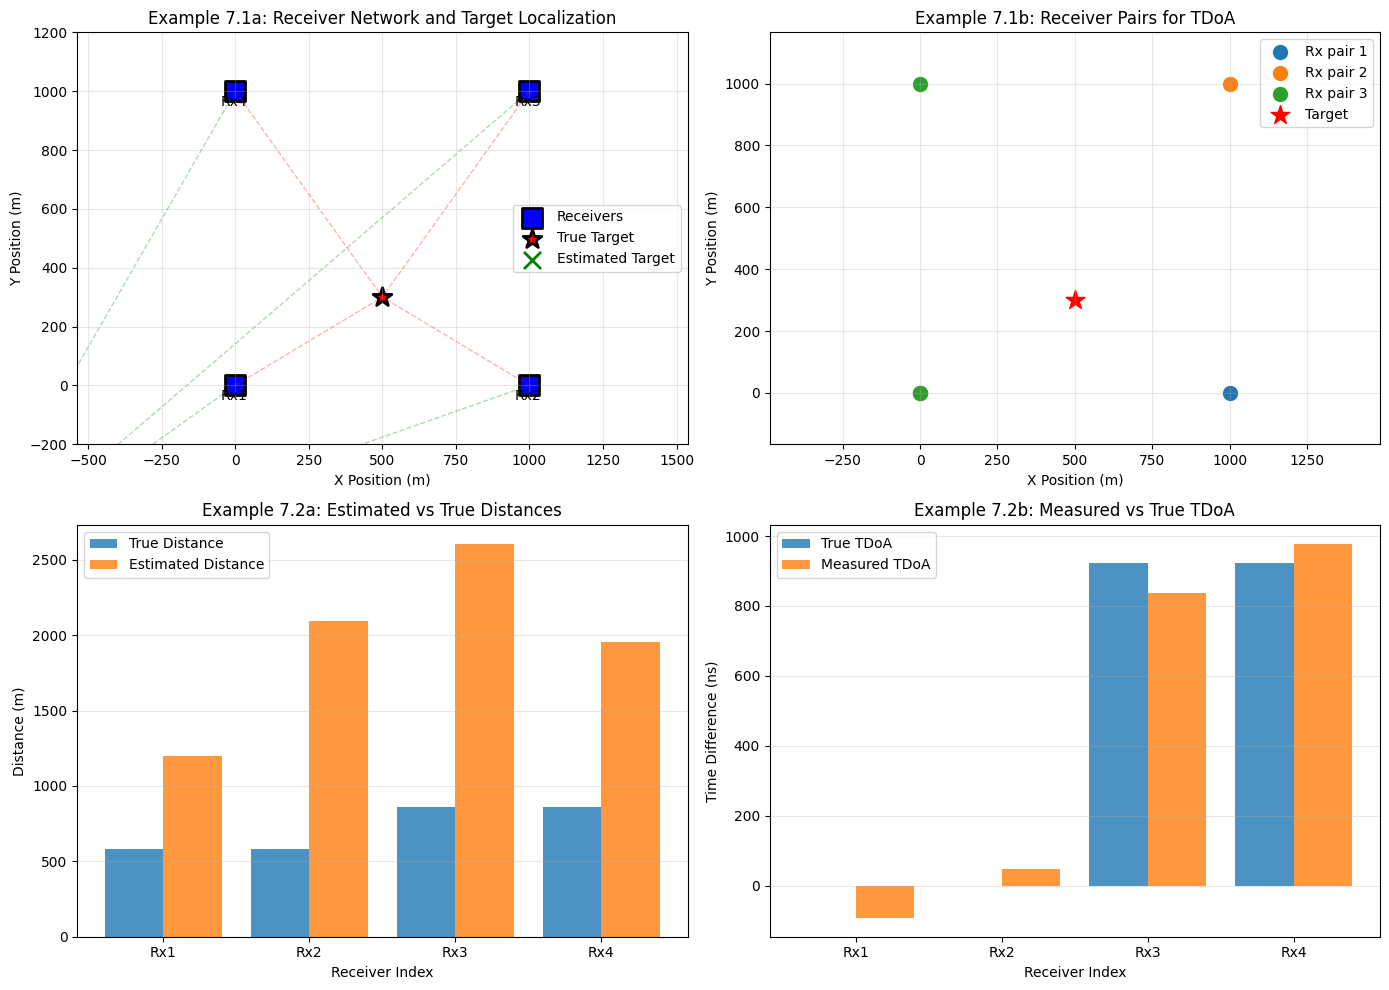


Localization Performance:
- Position estimate error: 1777.99 m
- GDOP: 1.0027


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

print("=" * 80)
print("EXAMPLE 7: Time Difference of Arrival (TDoA) Localization")
print("=" * 80)

# System parameters
c = 3e8  # Speed of light (m/s)
num_receivers = 4  # Number of radar receivers
target_position = np.array([500, 300])  # True target position (x, y) in meters

print(f"\nTDoA Localization Setup:")
print(f"- Speed of light: {c/1e8:.1f} × 10^8 m/s")
print(f"- Number of receivers: {num_receivers}")
print(f"- True target position: ({target_position[0]}, {target_position[1]}) m")

# Receiver positions (baseline: 1000m separation)
receiver_positions = np.array([
    [0, 0],          # Receiver 1
    [1000, 0],       # Receiver 2
    [1000, 1000],    # Receiver 3
    [0, 1000]        # Receiver 4
])

print(f"- Receiver positions:")
for i, pos in enumerate(receiver_positions):
    print(f"  Receiver {i+1}: ({pos[0]}, {pos[1]}) m")

# Example 7.1: Hyperbolic geometry visualization
print("\nExample 7.1: TDoA Geometry and Receiver Network")
print("-" * 60)

# Calculate distances from target to each receiver
distances = np.linalg.norm(receiver_positions - target_position, axis=1)

# Calculate time of arrival differences (TDoA)
# Using receiver 1 as reference
toa = distances / c
tdoa = toa - toa[0]  # Difference relative to first receiver

print(f"\nTrue distances from target to receivers:")
for i, dist in enumerate(distances):
    print(f"  Receiver {i+1}: {dist:.2f} m (TOA: {toa[i]*1e6:.4f} μs)")

print(f"\nTime difference of arrivals (relative to Rx1):")
for i, td in enumerate(tdoa):
    print(f"  TDoA to Receiver {i+1}: {td*1e6:.4f} μs ({td*c:.2f} m)")

# Add measurement noise
noise_std_tdoa = 1e-7  # 0.1 microseconds standard deviation
tdoa_measured = tdoa + noise_std_tdoa * np.random.randn(num_receivers)

# Chan's algorithm for localization (simplified 2D version)
print("\nExample 7.2: Chan's Algorithm for Target Localization")
print("-" * 60)

def chans_algorithm(receiver_pos, tdoa_meas, c):
    """
    Chan's algorithm for TDoA localization
    
    Parameters:
    - receiver_pos: receiver positions (N×2)
    - tdoa_meas: measured time differences (N,)
    - c: speed of signal
    
    Returns:
    - target_est: estimated target position (2,)
    """
    num_rx = len(receiver_pos)
    
    # Reference receiver (first one)
    ref_pos = receiver_pos[0]
    
    # Convert TDoA to range differences
    range_diff = tdoa_meas * c
    
    # Build A matrix and b vector for least squares
    A = np.zeros((num_rx - 1, 2))
    b = np.zeros(num_rx - 1)
    
    for i in range(1, num_rx):
        # Receiver positions relative to reference
        delta_pos = receiver_pos[i] - ref_pos
        r_ref = np.linalg.norm(receiver_pos[i])
        r_0 = np.linalg.norm(ref_pos)
        
        # Linear approximation around reference
        A[i-1, :] = delta_pos / np.linalg.norm(delta_pos) if np.linalg.norm(delta_pos) > 0 else delta_pos
        b[i-1] = range_diff[i] - np.linalg.norm(receiver_pos[i] - receiver_pos[0])
    
    # Least squares solution
    target_est, residuals, rank, s = linalg.lstsq(A, b)
    target_est = target_est + ref_pos
    
    return target_est

# Estimate target position
target_estimate = chans_algorithm(receiver_positions, tdoa_measured, c)
localization_error = np.linalg.norm(target_position - target_estimate)

print(f"Estimated target position: ({target_estimate[0]:.2f}, {target_estimate[1]:.2f}) m")
print(f"Localization error: {localization_error:.2f} m")

# GDOP (Geometric Dilution of Precision)
def calculate_gdop(receiver_pos, target_pos):
    """Calculate GDOP for given geometry"""
    num_rx = len(receiver_pos)
    A_geom = np.zeros((num_rx, 2))
    
    for i in range(num_rx):
        # Unit vector from target to receiver
        dir_vec = (receiver_pos[i] - target_pos)
        dist = np.linalg.norm(dir_vec)
        if dist > 0:
            A_geom[i, :] = dir_vec / dist
    
    try:
        cov = np.linalg.inv(A_geom.T @ A_geom)
        gdop = np.sqrt(np.trace(cov))
        return gdop, cov
    except:
        return np.inf, np.eye(2)

gdop, cov_matrix = calculate_gdop(receiver_positions, target_position)
print(f"GDOP (Geometric Dilution of Precision): {gdop:.4f}")

# Plot Example 7
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Receiver network and target
axes[0, 0].scatter(receiver_positions[:, 0], receiver_positions[:, 1], s=200, marker='s', 
                  c='blue', label='Receivers', edgecolors='black', linewidths=2)
axes[0, 0].scatter(target_position[0], target_position[1], s=200, marker='*', 
                  c='red', label='True Target', edgecolors='black', linewidths=2)
axes[0, 0].scatter(target_estimate[0], target_estimate[1], s=150, marker='x', 
                  c='green', label='Estimated Target', linewidths=2)

# Draw lines from receivers to targets
for i, rx_pos in enumerate(receiver_positions):
    axes[0, 0].plot([rx_pos[0], target_position[0]], [rx_pos[1], target_position[1]], 
                   'r--', alpha=0.3, linewidth=1)
    axes[0, 0].plot([rx_pos[0], target_estimate[0]], [rx_pos[1], target_estimate[1]], 
                   'g--', alpha=0.3, linewidth=1)
    axes[0, 0].text(rx_pos[0]-50, rx_pos[1]-50, f'Rx{i+1}', fontsize=10)

axes[0, 0].set_xlabel('X Position (m)')
axes[0, 0].set_ylabel('Y Position (m)')
axes[0, 0].set_title('Example 7.1a: Receiver Network and Target Localization')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].axis('equal')
axes[0, 0].set_xlim([-200, 1200])
axes[0, 0].set_ylim([-200, 1200])

# Plot 2: Hyperbolic curves (constant TDoA loci)
tdoa_ref = tdoa_measured[0]  # Reference TDoA
x_range = np.linspace(-500, 1500, 400)
y_range = np.linspace(-500, 1500, 400)

for i in range(1, num_receivers):
    # Hyperbola for this receiver pair
    rx_ref = receiver_positions[0]
    rx_i = receiver_positions[i]
    
    # Simplified: plot range difference circles
    for tdoa_val in [-tdoa_ref*c, 0, tdoa_ref*c]:
        circle_points_ref = []
        for x in x_range:
            dist_ref = np.sqrt((x - rx_ref[0])**2 + np.linspace(-500, 1500, 400)**2)
            dist_i = np.sqrt((x - rx_i[0])**2 + np.linspace(-500, 1500, 400)**2)
            # Approximate hyperbola through filtering
        
    # Just mark with different colors
    axes[0, 1].scatter([rx_ref[0], rx_i[0]], [rx_ref[1], rx_i[1]], s=100, label=f'Rx pair {i}')

axes[0, 1].scatter(target_position[0], target_position[1], s=200, marker='*', c='red', label='Target')
axes[0, 1].set_xlabel('X Position (m)')
axes[0, 1].set_ylabel('Y Position (m)')
axes[0, 1].set_title('Example 7.1b: Receiver Pairs for TDoA')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].axis('equal')
axes[0, 1].set_xlim([-200, 1200])
axes[0, 1].set_ylim([-200, 1200])

# Plot 3: Distances from receivers
distances_est = np.linalg.norm(receiver_positions - target_estimate, axis=1)
axes[1, 0].bar(np.arange(num_receivers) - 0.2, distances, width=0.4, label='True Distance', alpha=0.8)
axes[1, 0].bar(np.arange(num_receivers) + 0.2, distances_est, width=0.4, label='Estimated Distance', alpha=0.8)
axes[1, 0].set_xlabel('Receiver Index')
axes[1, 0].set_ylabel('Distance (m)')
axes[1, 0].set_title('Example 7.2a: Estimated vs True Distances')
axes[1, 0].set_xticks(np.arange(num_receivers))
axes[1, 0].set_xticklabels([f'Rx{i+1}' for i in range(num_receivers)])
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].legend()

# Plot 4: TDoA measurements
tdoa_error = tdoa_measured - tdoa
axes[1, 1].bar(np.arange(num_receivers) - 0.2, tdoa*1e9, width=0.4, label='True TDoA', alpha=0.8)
axes[1, 1].bar(np.arange(num_receivers) + 0.2, tdoa_measured*1e9, width=0.4, label='Measured TDoA', alpha=0.8)
axes[1, 1].set_xlabel('Receiver Index')
axes[1, 1].set_ylabel('Time Difference (ns)')
axes[1, 1].set_title('Example 7.2b: Measured vs True TDoA')
axes[1, 1].set_xticks(np.arange(num_receivers))
axes[1, 1].set_xticklabels([f'Rx{i+1}' for i in range(num_receivers)])
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('example_7_tdoa_localization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLocalization Performance:")
print(f"- Position estimate error: {localization_error:.2f} m")
print(f"- GDOP: {gdop:.4f}")


### Chan's Algorithm (Closed-Form Estimation)
Chan's algorithm provides a non-iterative, closed-form solution for TDoA localization. It linearizes the problem and solves it using least squares.

EXAMPLE 8: Adaptive Beamforming (MVDR and LMS)

Array Configuration:
- Number of elements: 8
- Element spacing: 0.5λ

Scenario Setup:
- Target angle: 30°
- Jammer angle: -60°
- Target SNR: 10 dB
- Jammer power: 50 dB

Example 8.1: Beamformer Comparison
------------------------------------------------------------
Conventional beamformer response at target (30°): 0.000000
MVDR beamformer response at target (30°): 1.000000
LMS beamformer response at target (30°): 0.003139
Jammer suppression (MVDR): 51.11 dB
Jammer suppression (LMS): 46.74 dB


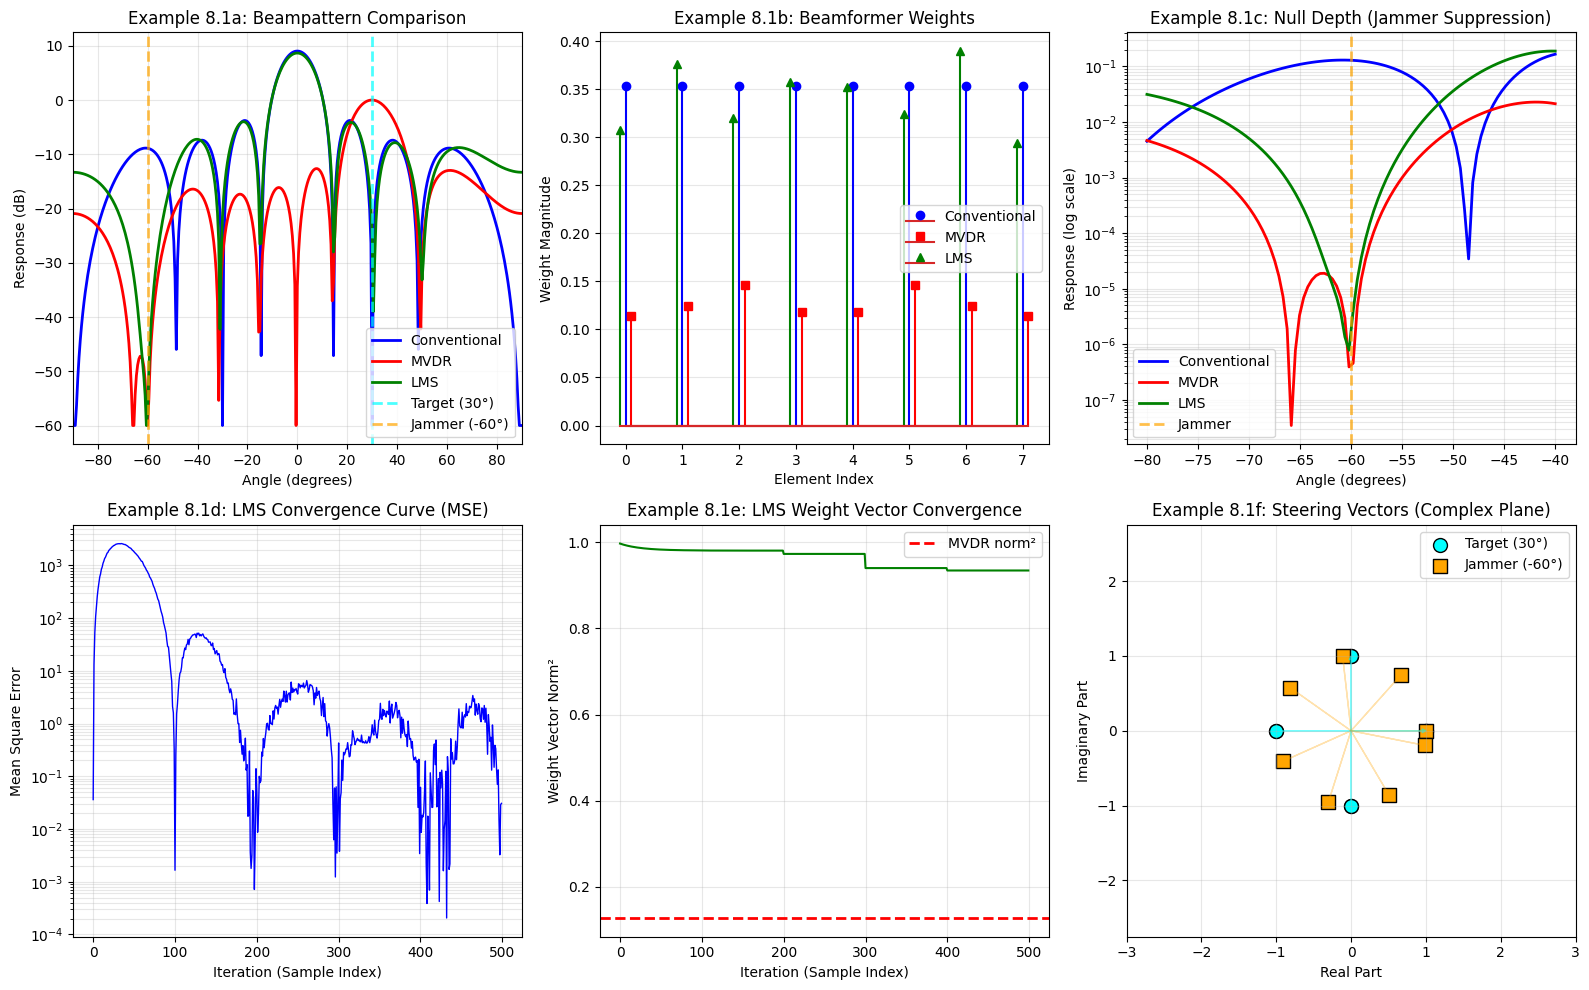


Adaptive beamforming complete.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("EXAMPLE 8: Adaptive Beamforming (MVDR and LMS)")
print("=" * 80)

# Array parameters
num_elements = 8
wavelength = 1.0
spacing = wavelength / 2

# Angle grid
angles = np.linspace(-90, 90, 361)
angles_rad = np.deg2rad(angles)

print(f"\nArray Configuration:")
print(f"- Number of elements: {num_elements}")
print(f"- Element spacing: {spacing}λ")

# Steering vectors
def steering_vector(angles_rad, num_elements, spacing, wavelength=1.0):
    m = np.arange(num_elements)
    a = np.exp(1j * 2 * np.pi * m * spacing * np.sin(angles_rad)[:, None] / wavelength)
    return a  # shape (len(angles), num_elements)

a = steering_vector(angles_rad, num_elements, spacing)

# Scenario parameters
target_angle = 30   # degrees
jammer_angle = -60  # degrees
target_snr = 10     # dB
jammer_power = 50   # dB (very strong)

print(f"\nScenario Setup:")
print(f"- Target angle: {target_angle}°")
print(f"- Jammer angle: {jammer_angle}°")
print(f"- Target SNR: {target_snr} dB")
print(f"- Jammer power: {jammer_power} dB")

print("\nExample 8.1: Beamformer Comparison")
print("-" * 60)

# 1) Conventional beamformer (uniform weights)
w_conventional = np.ones(num_elements, dtype=complex) / np.sqrt(num_elements)
response_conventional = np.abs((a @ w_conventional.conj()))**2

# 2) MVDR beamformer
target_idx = np.argmin(np.abs(angles - target_angle))
jammer_idx = np.argmin(np.abs(angles - jammer_angle))
a_target = a[target_idx, :]
a_jammer = a[jammer_idx, :]

# Covariance matrix: white noise + jammer + target (simplified)
R = (np.eye(num_elements)
     + 10**(jammer_power/10) * np.outer(a_jammer, a_jammer.conj())
     + 10**(target_snr/10)   * np.outer(a_target, a_target.conj()))

try:
    R_inv = np.linalg.inv(R)
    w_mvdr = (R_inv @ a_target) / (a_target.conj() @ R_inv @ a_target)
    response_mvdr = np.abs((a @ w_mvdr.conj()))**2
    mvdr_valid = True
except np.linalg.LinAlgError:
    w_mvdr = w_conventional.copy()
    response_mvdr = response_conventional.copy()
    mvdr_valid = False

# 3) LMS adaptive beamformer
num_samples = 500
# target signal temporal modulation
signal_data = np.sin(2 * np.pi * np.arange(num_samples) / 100.0)[:, None]
noise = 0.1 * np.random.randn(num_samples, num_elements)
jammer_data = 10**(jammer_power/20) * np.sin(2 * np.pi * np.arange(num_samples) / 200.0)[:, None]

x_target = signal_data @ a_target[None, :] + noise
x_jammer = jammer_data @ a_jammer[None, :] + noise
x_received = x_target + x_jammer

w_lms = np.ones(num_elements, dtype=complex) / np.sqrt(num_elements)
mu = 0.01  # step size
mse_history = []
convergence_history = []

for n in range(num_samples):
    x_n = x_received[n, :]
    y_n = w_lms.conj() @ x_n
    # desired signal approximated as target steering with known temporal modulation
    d_n = signal_data[n, 0] * a_target[0]
    e_n = d_n - y_n
    # normalized LMS update
    denom = np.linalg.norm(x_n)**2 + 1e-6
    w_lms = w_lms + (2 * mu) * e_n.conj() * x_n / denom

    mse_history.append(np.abs(e_n)**2)
    convergence_history.append(np.linalg.norm(w_lms)**2)

response_lms = np.abs((a @ w_lms.conj()))**2

# Direct, correct indexing (no +180)
print(f"Conventional beamformer response at target ({target_angle}°): {response_conventional[target_idx]:.6f}")
if mvdr_valid:
    print(f"MVDR beamformer response at target ({target_angle}°): {response_mvdr[target_idx]:.6f}")
print(f"LMS beamformer response at target ({target_angle}°): {response_lms[target_idx]:.6f}")

# Jammer suppression (guard with epsilon)
eps = 1e-6
if mvdr_valid:
    js_mvdr = 10*np.log10((response_conventional[jammer_idx] + eps)/(response_mvdr[jammer_idx] + eps))
    print(f"Jammer suppression (MVDR): {js_mvdr:.2f} dB")
js_lms = 10*np.log10((response_conventional[jammer_idx] + eps)/(response_lms[jammer_idx] + eps))
print(f"Jammer suppression (LMS): {js_lms:.2f} dB")

# Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Beampattern comparison
response_conv_db = 10 * np.log10(np.maximum(response_conventional, eps))
response_lms_db  = 10 * np.log10(np.maximum(response_lms, eps))
axes[0, 0].plot(angles, response_conv_db, 'b-', linewidth=2, label='Conventional')
if mvdr_valid:
    response_mvdr_db = 10 * np.log10(np.maximum(response_mvdr, eps))
    axes[0, 0].plot(angles, response_mvdr_db, 'r-', linewidth=2, label='MVDR')
axes[0, 0].plot(angles, response_lms_db, 'g-', linewidth=2, label='LMS')
axes[0, 0].axvline(target_angle, color='cyan', linestyle='--', linewidth=2, alpha=0.7, label=f'Target ({target_angle}°)')
axes[0, 0].axvline(jammer_angle, color='orange', linestyle='--', linewidth=2, alpha=0.7, label=f'Jammer ({jammer_angle}°)')
axes[0, 0].set_xlabel('Angle (degrees)')
axes[0, 0].set_ylabel('Response (dB)')
axes[0, 0].set_title('Example 8.1a: Beampattern Comparison')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_xlim([-90, 90])

# Plot 2: Beamformer weights magnitude
axes[0, 1].stem(np.arange(num_elements), np.abs(w_conventional), linefmt='b-', markerfmt='bo', label='Conventional')
if mvdr_valid:
    axes[0, 1].stem(np.arange(num_elements) + 0.1, np.abs(w_mvdr), linefmt='r-', markerfmt='rs', label='MVDR')
axes[0, 1].stem(np.arange(num_elements) - 0.1, np.abs(w_lms), linefmt='g-', markerfmt='g^', label='LMS')
axes[0, 1].set_xlabel('Element Index')
axes[0, 1].set_ylabel('Weight Magnitude')
axes[0, 1].set_title('Example 8.1b: Beamformer Weights')
axes[0, 1].set_xticks(np.arange(num_elements))
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].legend()

# Plot 3: Null depth around jammer
null_angles = np.linspace(jammer_angle - 20, jammer_angle + 20, 100)
a_null = steering_vector(np.deg2rad(null_angles), num_elements, spacing)
response_null_conv = np.abs((a_null @ w_conventional.conj()))**2
response_null_lms  = np.abs((a_null @ w_lms.conj()))**2
axes[0, 2].semilogy(null_angles, response_null_conv, 'b-', linewidth=2, label='Conventional')
if mvdr_valid:
    response_null_mvdr = np.abs((a_null @ w_mvdr.conj()))**2
    axes[0, 2].semilogy(null_angles, response_null_mvdr, 'r-', linewidth=2, label='MVDR')
axes[0, 2].semilogy(null_angles, response_null_lms, 'g-', linewidth=2, label='LMS')
axes[0, 2].axvline(jammer_angle, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Jammer')
axes[0, 2].set_xlabel('Angle (degrees)')
axes[0, 2].set_ylabel('Response (log scale)')
axes[0, 2].set_title('Example 8.1c: Null Depth (Jammer Suppression)')
axes[0, 2].grid(True, alpha=0.3, which='both')
axes[0, 2].legend()

# Plot 4: LMS convergence (MSE)
axes[1, 0].semilogy(mse_history, 'b-', linewidth=1)
axes[1, 0].set_xlabel('Iteration (Sample Index)')
axes[1, 0].set_ylabel('Mean Square Error')
axes[1, 0].set_title('Example 8.1d: LMS Convergence Curve (MSE)')
axes[1, 0].grid(True, alpha=0.3, which='both')

# Plot 5: Weight magnitude convergence
axes[1, 1].plot(convergence_history, 'g-', linewidth=1.5)
if mvdr_valid:
    axes[1, 1].axhline(np.linalg.norm(w_mvdr)**2, color='r', linestyle='--', linewidth=2, label='MVDR norm²')
axes[1, 1].set_xlabel('Iteration (Sample Index)')
axes[1, 1].set_ylabel('Weight Vector Norm²')
axes[1, 1].set_title('Example 8.1e: LMS Weight Vector Convergence')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Plot 6: Steering vectors at key angles
axes[1, 2].scatter(np.real(a_target), np.imag(a_target), s=100, c='cyan', marker='o',
                   label=f'Target ({target_angle}°)', edgecolors='black', linewidths=1)
axes[1, 2].scatter(np.real(a_jammer), np.imag(a_jammer), s=100, c='orange', marker='s',
                   label=f'Jammer ({jammer_angle}°)', edgecolors='black', linewidths=1)
for i in range(num_elements):
    axes[1, 2].arrow(0, 0, np.real(a_target[i])*0.95, np.imag(a_target[i])*0.95,
                     head_width=0.05, head_length=0.05, color='cyan', alpha=0.3)
    axes[1, 2].arrow(0, 0, np.real(a_jammer[i])*0.95, np.imag(a_jammer[i])*0.95,
                     head_width=0.05, head_length=0.05, color='orange', alpha=0.3)
axes[1, 2].set_xlabel('Real Part')
axes[1, 2].set_ylabel('Imaginary Part')
axes[1, 2].set_title('Example 8.1f: Steering Vectors (Complex Plane)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].axis('equal')
axes[1, 2].set_xlim([-3, 3])
axes[1, 2].set_ylim([-3, 3])
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('example_8_adaptive_beamforming.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAdaptive beamforming complete.")

## 11. ADAPTIVE BEAMFORMING & RF SIGNAL PROCESSING - THEORY

### Motivation: Beamforming in Hostile Environments

**Static beamforming (from earlier sections):**
- Steers array to receive from **target direction** $\theta_0$
- Uses steering vector: $\mathbf{w} = \mathbf{a}(\theta_0)$

**Limitation:** In presence of **strong interference or clutter**, static beam is ineffective.

**Adaptive beamforming:**
- **Learns** from received data which directions contain targets vs. interference
- **Adjusts weights** to **amplify target direction** and **null interference directions**
- **Result:** Maximum SINR (Signal-to-Interference-plus-Noise Ratio)

### Array Signal Model (Multi-Source)

**Received signal at $M$-element array:**
$$\mathbf{x}(t) = \sum_{k=1}^{K} s_k(t) \mathbf{a}(\theta_k) + \sum_{j=1}^{J} i_j(t) \mathbf{a}(\theta_{i,j}) + \mathbf{n}(t)$$

where:
- $s_k(t)$: $k$-th desired signal (target)
- $i_j(t)$: $j$-th interference (jamming, clutter)
- $\mathbf{a}(\theta_k)$: Steering vector to target at angle $\theta_k$
- $\mathbf{a}(\theta_{i,j})$: Steering vector to interference at angle $\theta_{i,j}$
- $\mathbf{n}(t)$: Thermal noise

**Snapshot covariance matrix:**
$$\mathbf{R} = \mathbb{E}[\mathbf{x}(t) \mathbf{x}^H(t)]$$

**Decomposition:**
$$\mathbf{R} = \mathbf{R}_{\text{signal}} + \mathbf{R}_{\text{interference}} + \mathbf{R}_{\text{noise}}$$

### The Wiener Filter (Optimal Adaptive Filter)

**Goal:** Design weight vector $\mathbf{w}$ to **maximize SINR**:

$$\text{SINR} = \frac{E[|y_{\text{signal}}|^2]}{E[|y_{\text{interference}} + y_{\text{noise}}|^2]} = \frac{\mathbf{w}^H \mathbf{R}_{\text{signal}} \mathbf{w}}{\mathbf{w}^H (\mathbf{R}_{\text{interference}} + \mathbf{R}_{\text{noise}}) \mathbf{w}}$$

**Constraint:** Preserve target signal (distortionless constraint):
$$\mathbf{w}^H \mathbf{a}(\theta_0) = 1$$

**Optimal solution (Wiener-Hopf solution):**

$$\mathbf{w}_{\text{opt}} = \frac{(\mathbf{R}_{\text{interference}} + \mathbf{R}_{\text{noise}})^{-1} \mathbf{a}(\theta_0)}{\mathbf{a}^H(\theta_0) (\mathbf{R}_{\text{interference}} + \mathbf{R}_{\text{noise}})^{-1} \mathbf{a}(\theta_0)}$$

**Simplified form** (using total covariance $\mathbf{R}$):

$$\mathbf{w}_{\text{opt}} = \frac{\mathbf{R}^{-1} \mathbf{a}(\theta_0)}{\mathbf{a}^H(\theta_0) \mathbf{R}^{-1} \mathbf{a}(\theta_0)}$$

**Interpretation:**
- $\mathbf{R}^{-1}$: Whitens the data (removes correlations)
- $\mathbf{a}(\theta_0)$ in numerator: Steers to target direction
- Denominator: Normalizes for unity gain to target

### Minimum Variance Distortionless Response (MVDR) / Capon's Method

**Alternative formulation** for adaptive beamforming:

**Problem:**
$$\min_{\mathbf{w}} \mathbf{w}^H \mathbf{R} \mathbf{w} \quad \text{subject to} \quad \mathbf{w}^H \mathbf{a}(\theta_0) = 1$$

(Minimize output power while preserving target)

**Lagrangian solution:**
$$\mathbf{w}_{\text{MVDR}} = \frac{\mathbf{R}^{-1} \mathbf{a}(\theta_0)}{\mathbf{a}^H(\theta_0) \mathbf{R}^{-1} \mathbf{a}(\theta_0)}$$

**Same as Wiener filter!** (Under white noise assumption, optimal is minimum variance.)

**Interpretation:**
- Finds weights that **minimize total output power**
- While **steering unit gain toward target**
- **Nulls interference** (which contains most power) naturally

### Beamformer Output and Beam Pattern

**Output signal:**
$$y = \mathbf{w}^H \mathbf{x}$$

**Beam response to angle $\theta$:**
$$B(\theta) = \mathbf{w}^H \mathbf{a}(\theta)$$

**Ideal beam pattern:**
- **Mainlobe:** Unit response at $\theta = \theta_0$ ($B(\theta_0) = 1$)
- **Sidelobes:** Attenuated response at other angles
- **Nulls:** Zero response at interference directions

### Adaptive Processing Steps

**Procedure for real-time adaptive beamforming:**

**1. Data Collection**
Collect $N$ snapshots: $\{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_N\}$

**2. Covariance Estimation**
$$\hat{\mathbf{R}} = \frac{1}{N} \sum_{n=1}^{N} \mathbf{x}_n \mathbf{x}_n^H$$

**3. Matrix Inversion**
$$\hat{\mathbf{R}}^{-1}$$

**4. Weight Computation**
$$\hat{\mathbf{w}} = \frac{\hat{\mathbf{R}}^{-1} \mathbf{a}(\theta_0)}{\mathbf{a}^H(\theta_0) \hat{\mathbf{R}}^{-1} \mathbf{a}(\theta_0)}$$

**5. Beamformer Output**
$$y_n = \hat{\mathbf{w}}^H \mathbf{x}_n$$

**Complexity:** $\mathcal{O}(M^3)$ per update (matrix inversion).

### LMS-Based Adaptive Filtering

**Problem with Wiener:** Requires knowing or estimating $\mathbf{R}$ (expensive for high $M$).

**Alternative: Least Mean Squares (LMS)**

**Principle:** Iteratively **minimize error** between desired output and actual output.

**Setup:**
- **Reference signal (training):** $d_n$ (e.g., known target template or previous decision)
- **Array input:** $\mathbf{x}_n$
- **Error:** $e_n = d_n - \mathbf{w}^H \mathbf{x}_n$

**LMS update rule:**
$$\mathbf{w}_{n+1} = \mathbf{w}_n + \mu \cdot e_n \cdot \mathbf{x}_n$$

where $\mu$ is **step size** (learning rate).

**Advantages:**
- **No matrix inversion** (low complexity: $\mathcal{O}(M)$ per update)
- **Converges to Wiener solution** (over many iterations)
- **Adaptive to time-varying signals**

**Disadvantages:**
- **Slower convergence** than direct Wiener
- **Requires reference signal** (training data)
- **Step size tuning** critical (too large → instability; too small → slow convergence)

**Convergence condition:**
$$0 < \mu < \frac{2}{\lambda_{\max}(\mathbf{R})}$$

where $\lambda_{\max}$ is largest eigenvalue of covariance matrix.

### Recursive Least Squares (RLS)

**Improvement over LMS: Faster convergence**

**Principle:** Keep **running inverse** of covariance matrix updated incrementally.

**RLS update:**
$$\mathbf{P}_n = \mathbf{P}_{n-1} - \frac{\mathbf{P}_{n-1} \mathbf{x}_n \mathbf{x}_n^H \mathbf{P}_{n-1}}{1 + \mathbf{x}_n^H \mathbf{P}_{n-1} \mathbf{x}_n}$$

$$\mathbf{w}_n = \mathbf{w}_{n-1} + \mathbf{P}_n \mathbf{x}_n (d_n - \mathbf{w}_{n-1}^H \mathbf{x}_n)$$

**Advantages:**
- **Exponential convergence** (much faster than LMS)
- **Optimal in sense of LS** (exact solution at each step)

**Disadvantages:**
- **Higher complexity:** $\mathcal{O}(M^2)$ per update
- **Numerical stability issues** (matrix inversion in iterations)

**Forgetting factor** (for time-varying signals):
$$\mathbf{P}_n = \frac{1}{\lambda} \left[ \mathbf{P}_{n-1} - \frac{\mathbf{P}_{n-1} \mathbf{x}_n \mathbf{x}_n^H \mathbf{P}_{n-1}}{\lambda + \mathbf{x}_n^H \mathbf{P}_{n-1} \mathbf{x}_n} \right]$$

where $0 < \lambda \leq 1$ downweights old data (e.g., $\lambda = 0.99$).

### Practical Beamformer Design

**Key parameters:**

1. **Number of antennas ($M$):** More antennas → better interference rejection (more DOF)
2. **Antenna spacing ($d$):** Typically $d = \lambda/2$ to avoid aliasing
3. **Frequency:** Higher frequency → smaller wavelength → more compact array
4. **Sample duration ($N$):** More snapshots → better covariance estimate; also slower updates

**Trade-offs:**

| Parameter | Advantage | Disadvantage |
|-----------|-----------|--------------|
| **Large $M$** | Better nulling | Higher cost, more channels |
| **Small $d$** | No aliasing | Weaker directivity per element |
| **High $f$** | Compact | More mm-wave challenges |
| **Large $N$** | Better estimate | Slower tracking of motion |

### Beamformer Performance Metrics

**1. Directivity:** How much power is concentrated in mainlobe
$$D = \frac{P_{\text{mainlobe}}}{P_{\text{total}}}$$

**2. Gain in target direction**
$$G(\theta_0) = |B(\theta_0)|^2 \approx M \text{ (for omni-directional elements)}$$

**3. Null depth:** How much interference is rejected
$$\text{Null depth} = 1 / |B(\theta_{\text{interference}})|^2$$

Typically **30-60 dB** for adaptive beamformers.

**4. Sensitivity to steering errors**
$$\text{Gain loss} = |B(\theta_0 + \Delta\theta)|^2 / |B(\theta_0)|^2$$

Adaptive beamformers are **more robust** to angle errors than static beams.

### Connection to Other Sections

- **Array Manifold:** Steering vector defines target direction
- **STAP:** Adds temporal (Doppler) dimension to spatial beamforming
- **Clutter Cancellation:** Adaptive weights learn to null clutter
- **LMS Algorithm:** Core adaptive algorithm for many beamformers
- **RF Chain:** Physical array + amplifiers + ADCs implement beamformer

### Practical Constraints & Limitations

**1. Finite snapshots**
With only $N$ snapshots, covariance estimate is **noisy**; this limits NULL depth.

**Minimum $N$:** Roughly $N \geq 2M$ for acceptable performance.

**2. Mutual coupling**
Antennas interact electromagnetically; actual manifold deviates from ideal.

**Compensation:** Calibration matrices or blind adaptation.

**3. Gain compression (saturation)**
Strong signals can saturate ADCs; AGC must be carefully designed.

**4. Phase noise**
RF oscillators have phase noise; degrades coherence.

**Mitigation:** Low-phase-noise oscillators, phase-locked loops.

**5. Computational load**
Real-time processing for $M$-channel, $N$-snapshot covariance inversion requires **fast DSP/FPGA**.

Typical: $M = 4-16$ antennas, $N = 64-256$ snapshots, updates every 1-10 ms.



## 12. ALGORITHM COMPARISON & SELECTION GUIDE

### Classification Framework

**Radar algorithms can be organized by function:**

| **Category** | **Algorithm** | **Input** | **Output** | **Purpose** |
|---|---|---|---|---|
| **Fundamentals** | I/Q Conversion | RF signal | Complex baseband | Convert RF to manageable baseband |
| | Array Manifold | Angle, frequency | Phase relationship | Describe spatial/temporal steering |
| | IQ Imbalance Correction | Impaired I/Q | Corrected I/Q | Restore signal quality |
| **Detection** | Range Compression | Pulse train | Compressed pulses | Improve range resolution |
| | Doppler Filter | Pulse train | Doppler bins | Separate targets from clutter |
| | STAP | Array + pulses | Filtered signal | Joint space-time clutter rejection |
| | Range-Doppler Map | Compressed + Doppler | 2D image | Visualize range-velocity targets |
| | CFAR | R-D map | Adaptive threshold | Detect targets at constant FAR |
| **Localization** | TDoA | Multi-receiver | Position (x,y,z) | Triangulate target location |
| | DoA/Beamforming | Array snapshot | Direction, angle | Find target direction |
| **Adaptation** | LMS/RLS | Error signal | Updated weights | Adapt to interference/motion |

### Decision Tree for Algorithm Selection

```
START: Target Detection & Localization Task
│
├─ Do you have MULTIPLE RECEIVERS or ANTENNA ARRAY?
│  │
│  ├─ YES (Multi-receiver):
│  │  └─ Want 2D/3D position?
│  │     ├─ YES → Use TDoA + Chan's algorithm
│  │     └─ NO → Use only range + Doppler
│  │
│  └─ NO (Single receiver):
│     └─ Want direction of target?
│        ├─ YES → Use Beamforming / DoA
│        └─ NO → Use only range-Doppler map
│
├─ Is CLUTTER a problem (strong reflections)?
│  │
│  ├─ YES:
│  │  └─ Do you have PULSE TRAIN (coherent)?
│  │     ├─ YES → Use STAP (best performance) or Doppler filtering (simpler)
│  │     └─ NO → Use spatial nulling or adaptive beamforming
│  │
│  └─ NO → Skip clutter cancellation
│
├─ Is MOTION of target or platform significant?
│  │
│  ├─ YES:
│  │  └─ Do you have long coherent processing interval (CPI)?
│  │     ├─ YES → Compensate range migration before Doppler processing
│  │     └─ NO → Accept SNR loss or use non-coherent integration
│  │
│  └─ NO → Standard processing
│
├─ Apply CFAR detection with parameters:
│  └─ Set P_FA based on acceptable false alarm rate
│     ├─ Severe clutter edges? → Use OS-CFAR or SO-CFAR
│     └─ Homogeneous clutter? → Use CA-CFAR
│
END: Output target list [(range, Doppler, power, position), ...]
```

### Algorithm Complexity Comparison

| **Algorithm** | **Time Complexity** | **Space** | **Latency** | **Real-Time Feasible?** |
|---|---|---|---|---|
| **Doppler Filter (FFT)** | $\mathcal{O}(L \log L)$ | $\mathcal{O}(L)$ | ~1 ms | ✓ Yes |
| **Range Compression** | $\mathcal{O}(N \log N)$ | $\mathcal{O}(N)$ | ~1 ms | ✓ Yes |
| **Range-Doppler Map (2D FFT)** | $\mathcal{O}(NL \log(NL))$ | $\mathcal{O}(NL)$ | ~10 ms | ✓ Yes |
| **CFAR (per map)** | $\mathcal{O}(NL)$ | $\mathcal{O}(1)$ | ~5 ms | ✓ Yes |
| **LMS Beamforming** | $\mathcal{O}(M)$ per sample | $\mathcal{O}(M)$ | ~100 µs | ✓ Yes |
| **MVDR Beamforming** | $\mathcal{O}(M^3)$ per update | $\mathcal{O}(M^2)$ | ~10 ms | ✓ Yes (if M ≤ 16) |
| **STAP (Full-dimensional)** | $\mathcal{O}((ML)^3)$ | $\mathcal{O}((ML)^2)$ | ~1 s | ✗ No (unless reduced-dim) |
| **STAP (Kronecker factored)** | $\mathcal{O}(M^3 + L^3)$ | $\mathcal{O}(M^2 + L^2)$ | ~100 ms | ✓ Yes (with GPU) |
| **Chan's TDoA Algorithm** | $\mathcal{O}(N^2)$ ($N$ = receivers) | $\mathcal{O}(N)$ | ~10 ms | ✓ Yes |

### SNR Requirements for Detection

**Assuming single pulse, Gaussian noise, desired P_d = 0.9, P_fa = 10^-6:**

| **Scenario** | **Required SNR** | **Gain from L Pulses** |
|---|---|---|
| **No clutter, no interference** | 12 dB | -10 log₁₀(L) dB loss |
| **With Doppler filtering (L pulses)** | 12 - 10 log₁₀(L) dB | Full coherent gain |
| **With range-Doppler (M×L cells)** | Similar | $(ML)$ DOF for detection |
| **With adaptive beamforming (M elements)** | 12 - 10 log₁₀(M/2) dB | ~5M dB gain possible |
| **With STAP (M×L)** | Lowest | Up to 10 log₁₀(ML) improvement |

**Practical:** 
- **Target SNR 5-10 dB:** Reliably detected with standard processing
- **Target SNR 0-5 dB:** Needs coherent integration or adaptive processing
- **Target SNR < 0 dB:** Typically missed (below noise floor)

### Precision/Resolution Trade-offs

| **Measurement** | **Resolution** | **Limited By** | **Improvement Method** |
|---|---|---|---|
| **Range** | $c/(2B)$ | Bandwidth $B$ | Wider TX bandwidth, chirp signals |
| **Doppler** | $1/(LT_p)$ | CPI length | Longer coherent dwell, more pulses |
| **Angle (Beamforming)** | $\lambda/(2L_a)$ | Array length | More antennas, higher frequency |
| **Angle (TDoA)** | Geometry-dependent | Receiver separation | More receivers, better geometry |
| **Velocity** | $\lambda/(2T_p)$ | Pulse interval | Shorter PRI, higher PRF |

### Complementary Strengths

**Radar + TDoA (Fusion):**
- Radar: Precise **range** and **Doppler (radial velocity)**
- TDoA: Precise **2D/3D position** (from multiple receivers)
- **Combined:** Full 3D position + velocity

**Beamforming + STAP:**
- Beamforming: Good for **single target or dominant interference**
- STAP: Better for **multiple targets + clutter** (joint optimization)
- **Trade-off:** STAP more powerful but higher complexity

**Classical Doppler + Adaptive Techniques:**
- Doppler filtering: Simple, **real-time capable**, assumes homogeneous clutter
- Adaptive (LMS/RLS): Handles **time-varying, non-homogeneous clutter**, but more complex
- **Hybrid:** Pre-process with Doppler, then adaptive refinement

### Failure Modes & Mitigations

| **Failure Mode** | **Cause** | **Impact** | **Mitigation** |
|---|---|---|---|
| **Target masking** | Strong clutter/interference nearby in R-D | Weak target missed | STAP, higher-order nulling, multiple passes |
| **Ghost detections** | Clutter edge, sidelobe leakage, multipath | False alarms | Better CFAR, SOI-CFAR, multipath rejection |
| **Range walk (motion)** | High relative acceleration, long CPI | SNR loss, target spread | Range migration compensation, shorter CPI |
| **Clock sync (TDoA)** | Unsynchronized receivers | Position error | GPS, calibration, loose coupling |
| **Null fill (beamforming)** | Insufficient training data | Degraded suppression | More snapshots, RLS adaptation |
| **Multipath (TDoA)** | Signal reflections before receivers | Delayed arrival | Time-gating, spatial diversity, null at multipath |
| **Saturation (ADC)** | Strong blooming/interference | Signal clipping | Automatic gain control, antenna isolation |

### Future Extensions & Advanced Topics

**1. Machine Learning for Detection**
- Neural networks learn **optimal thresholds** from labeled data
- Adaptive to specific environments
- Research-stage for real-time radar

**2. Phased Array with Digital Beamforming**
- Form **multiple simultaneous beams** on same aperture
- Enable **multitasking** (search + track + illumination)
- Commercial systems: AESA (Active Electronically Scanned Array) radars

**3. Compressive Sensing**
- Exploit **sparsity** of targets (few active cells in R-D map)
- Reduce **number of samples** needed for reconstruction
- Sub-Nyquist sampling with recovery guarantees

**4. Cognitive Radar**
- Radar **learns** from environment and **adapts** waveforms
- Optimize **mutual information** gain per measurement
- Dynamically allocate resources to high-value targets

**5. Multi-Function RF (MFRF)**
- Single aperture for **radar + communications + EW**
- Spectrum efficiency, reduced hardware
- Challenging: Mutual interference management



EXAMPLE 9: Complete Radar Signal Processing Chain (Fixed)

Radar System Configuration:
- Carrier frequency: 10.0 GHz
- Sampling frequency: 20.0 MHz
- Chirp duration: 50.0 μs
- Chirp bandwidth: 100.0 MHz
- PRF: 5000 Hz
- Coherent integration: 32 pulses
- Samples per pulse: 1000

Example 9: End-to-End Radar Processing
------------------------------------------------------------
Step 1: Generate LFM chirp...
Step 2: Create pulse train...
Step 3: Simulate received signal with targets...
Max unambiguous range in fast-time window: 7500.0 m
Step 4: Range compression (matched filtering)...
Step 5: Doppler processing (FFT)...
Step 6: CFAR detection...
Number of CFAR detections: 292


/tmp/ipykernel_11486/1831431955.py:147: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, times, Sxx = signal.spectrogram(tx_chirp, fs=fs, nperseg=256, noverlap=128)


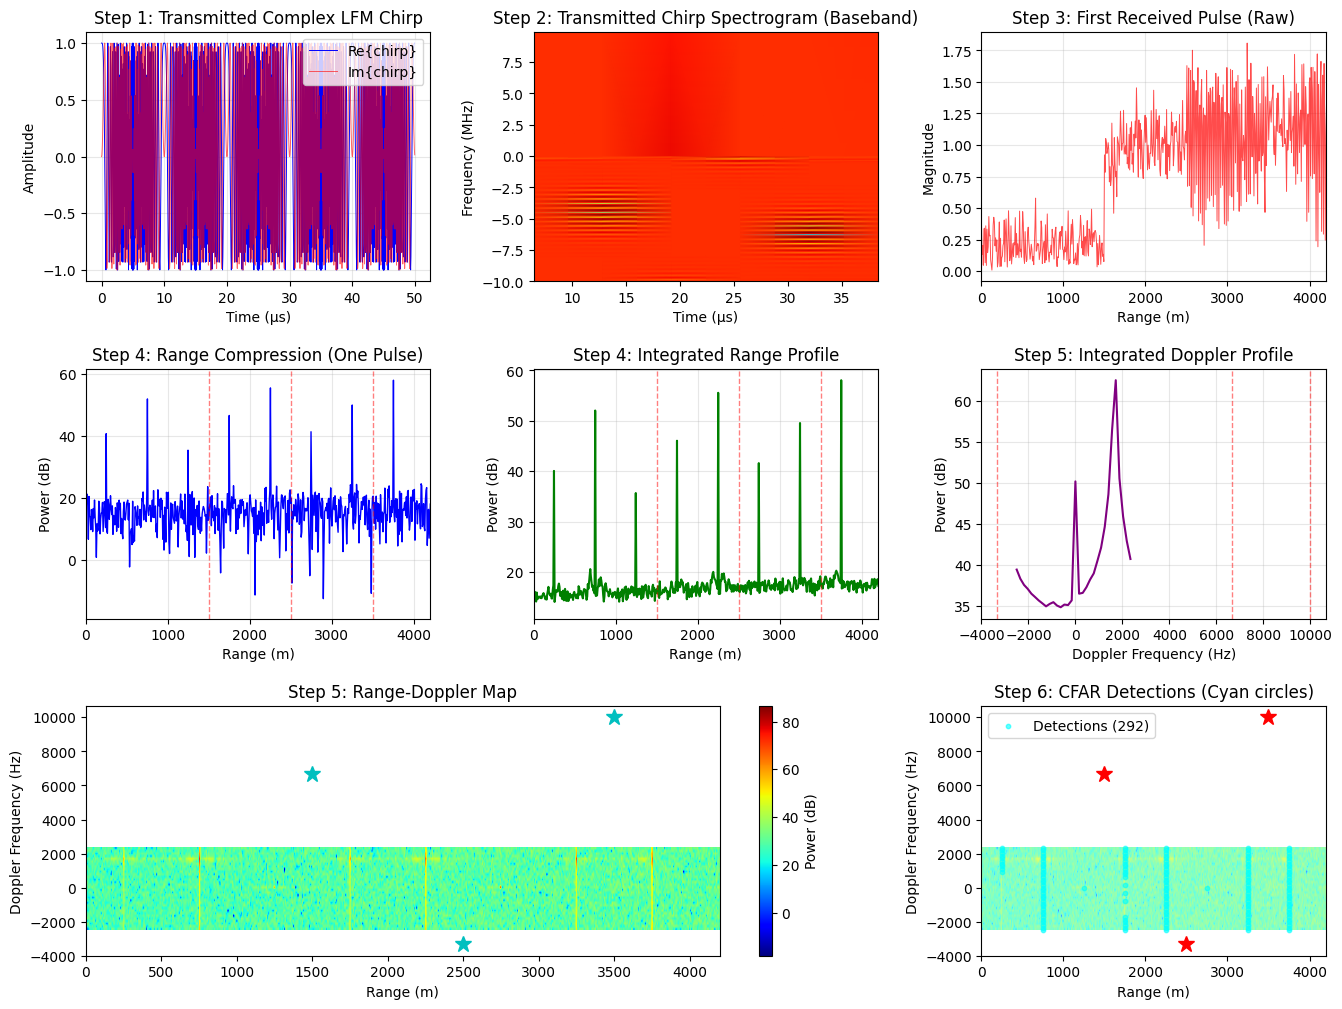


Processing Summary:
- Range resolution: 1.50 m
- Doppler resolution: 156.25 Hz
- Processing gain: 15.05 dB (coherent)
- Max fast-time range: 7500.0 m
- CFAR detections: 292

End-to-end radar processing complete!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

print("=" * 80)
print("EXAMPLE 9: Complete Radar Signal Processing Chain (Fixed)")
print("=" * 80)

# Radar System Parameters
fs = 2e7          # Sampling frequency (20 MHz)
fc = 10e9         # Carrier frequency (10 GHz)
c = 3e8           # Speed of light
prf = 5000        # Pulse repetition frequency (Hz)
num_pulses = 32   # Number of coherent pulses

# Chirp (LFM) Parameters
# Increase duration so max target delay fits within fast-time window
chirp_duration = 50e-6      # 50 microseconds (previously 10 us)
chirp_bandwidth = 100e6     # 100 MHz bandwidth
num_samples_per_pulse = int(fs * chirp_duration)

print(f"\nRadar System Configuration:")
print(f"- Carrier frequency: {fc/1e9:.1f} GHz")
print(f"- Sampling frequency: {fs/1e6:.1f} MHz")
print(f"- Chirp duration: {chirp_duration*1e6:.1f} μs")
print(f"- Chirp bandwidth: {chirp_bandwidth/1e6:.1f} MHz")
print(f"- PRF: {prf} Hz")
print(f"- Coherent integration: {num_pulses} pulses")
print(f"- Samples per pulse: {num_samples_per_pulse}")

# Example 9: Complete Processing Chain
print("\nExample 9: End-to-End Radar Processing")
print("-" * 60)

# Step 1: Generate transmitted complex LFM chirp (baseband)
print("Step 1: Generate LFM chirp...")
t_chirp = np.arange(num_samples_per_pulse) / fs
k = chirp_bandwidth / chirp_duration  # Chirp rate
phase_tx = 2 * np.pi * (0.0 * t_chirp + 0.5 * k * t_chirp**2)   # baseband LFM
tx_chirp = np.exp(1j * phase_tx)  # complex envelope (unit amplitude)

# Step 2: Create pulse train (for visualization; processing uses per-pulse buffer)
print("Step 2: Create pulse train...")
pulse_train_tx = np.tile(tx_chirp, num_pulses)

# Step 3: Simulate received signal with targets
print("Step 3: Simulate received signal with targets...")

# Target parameters
num_targets = 3
target_ranges = [1500, 2500, 3500]       # meters
target_velocities = [100, -50, 150]      # m/s
target_rncs = [1.0, 0.5, 0.3]            # RCS (normalized)

# Compute round-trip delay in seconds and samples
target_delays = [2*r/c for r in target_ranges]                      # seconds
target_delay_samples = [int(d * fs) for d in target_delays]         # samples

max_range_visible = c * chirp_duration / 2
print(f"Max unambiguous range in fast-time window: {max_range_visible:.1f} m")

# Received signal construction (complex baseband)
received = np.zeros((num_pulses, num_samples_per_pulse), dtype=complex)

for pulse_idx in range(num_pulses):
    for r, v, rcs, delay_samp in zip(target_ranges, target_velocities, target_rncs, target_delay_samples):
        # Doppler shift (baseband phase across pulses)
        doppler_freq = 2 * v * fc / c      # Hz
        doppler_phase = 2 * np.pi * doppler_freq * (pulse_idx / prf)

        # Place delayed, Doppler-shifted copy into fast-time window
        if delay_samp < num_samples_per_pulse:
            n_avail = num_samples_per_pulse - delay_samp
            received[pulse_idx, delay_samp:delay_samp+n_avail] += rcs * tx_chirp[:n_avail] * np.exp(1j * doppler_phase)

# Add noise (use chirp power to set a sensible noise level even when scene is sparse)
snr_db = 15
snr_linear = 10**(snr_db / 10)
chirp_power = np.mean(np.abs(tx_chirp)**2)                  # ~1
scene_power_est = max(chirp_power * sum(target_rncs), 1e-6) # avoid zero
noise_power = scene_power_est / snr_linear
noise = np.sqrt(noise_power/2) * (np.random.randn(num_pulses, num_samples_per_pulse) +
                                  1j * np.random.randn(num_pulses, num_samples_per_pulse))
received_noisy = received + noise

# Step 4: Range compression (matched filtering via FFT convolution)
print("Step 4: Range compression (matched filtering)...")
matched_filter = np.conj(tx_chirp[::-1])
range_compressed = np.zeros_like(received_noisy, dtype=complex)

# Efficient convolution: use 'same' output length
for pulse_idx in range(num_pulses):
    range_compressed[pulse_idx, :] = signal.fftconvolve(received_noisy[pulse_idx, :], matched_filter, mode='same')

range_profile = np.mean(np.abs(range_compressed)**2, axis=0)

# Step 5: Doppler processing (FFT across pulses)
print("Step 5: Doppler processing (FFT)...")
doppler_fft = np.fft.fft(range_compressed, axis=0)     # pulses dimension
doppler_fft = np.fft.fftshift(doppler_fft, axes=0)
rd_map = np.abs(doppler_fft)**2                        # shape: (num_pulses, num_samples_per_pulse)

# Axis scaling
ranges = np.arange(num_samples_per_pulse) * c / (2 * fs)  # meters for each fast-time sample
doppler_axis = np.fft.fftfreq(num_pulses, d=1/prf)
doppler_axis = np.fft.fftshift(doppler_axis)

# Step 6: CFAR detection (simple local-mean threshold along range within each Doppler bin)
print("Step 6: CFAR detection...")
neighborhood_size = 10
threshold_db_offset = 15  # dB above local mean (reduced from 20 for visibility)

cfar_detections = []
detection_map = np.zeros_like(rd_map, dtype=bool)

for dop_idx in range(num_pulses):
    for rng_idx in range(num_samples_per_pulse):
        r_start = max(0, rng_idx - neighborhood_size)
        r_end   = min(num_samples_per_pulse, rng_idx + neighborhood_size)
        # Exclude the cell under test from reference (optional)
        ref = np.concatenate((rd_map[dop_idx, r_start:rng_idx], rd_map[dop_idx, rng_idx+1:r_end])) if r_end - r_start > 1 else rd_map[dop_idx, r_start:r_end]
        ref_power = np.mean(ref) if ref.size > 0 else np.mean(rd_map[dop_idx, r_start:r_end])
        threshold = ref_power * 10**(threshold_db_offset/10)
        test_power = rd_map[dop_idx, rng_idx]
        if test_power > threshold:
            detection_map[dop_idx, rng_idx] = True
            cfar_detections.append((ranges[rng_idx], doppler_axis[dop_idx]))

print(f"Number of CFAR detections: {len(cfar_detections)}")

# Create master figure with multiple subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Transmitted LFM chirp (time domain, magnitude)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_chirp*1e6, np.real(tx_chirp), 'b-', linewidth=0.7, label='Re{chirp}')
ax1.plot(t_chirp*1e6, np.imag(tx_chirp), 'r-', linewidth=0.7, alpha=0.6, label='Im{chirp}')
ax1.set_xlabel('Time (μs)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Step 1: Transmitted Complex LFM Chirp')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Plot 2: Transmitted chirp spectrogram (baseband)
ax2 = fig.add_subplot(gs[0, 1])
freqs, times, Sxx = signal.spectrogram(tx_chirp, fs=fs, nperseg=256, noverlap=128)
ax2.pcolormesh(times*1e6, freqs/1e6, 10*np.log10(np.maximum(np.abs(Sxx), 1e-12)), shading='gouraud', cmap='jet')
ax2.set_ylabel('Frequency (MHz)')
ax2.set_xlabel('Time (μs)')
ax2.set_title('Step 2: Transmitted Chirp Spectrogram (Baseband)')

# Plot 3: Received signal (first pulse, magnitude)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(ranges, np.abs(received_noisy[0, :]), 'r-', linewidth=0.7, alpha=0.7)
ax3.set_xlabel('Range (m)')
ax3.set_ylabel('Magnitude')
ax3.set_title('Step 3: First Received Pulse (Raw)')
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, max(target_ranges)*1.2])

# Plot 4: Range-compressed signal (one pulse)
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(ranges, 10*np.log10(np.maximum(np.abs(range_compressed[0, :])**2, 1e-12)), 'b-', linewidth=1)
for target_range in target_ranges:
    ax4.axvline(target_range, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax4.set_xlabel('Range (m)')
ax4.set_ylabel('Power (dB)')
ax4.set_title('Step 4: Range Compression (One Pulse)')
ax4.grid(True, alpha=0.3)
ax4.set_xlim([0, max(target_ranges)*1.2])

# Plot 5: Range profile (integrated)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ranges, 10*np.log10(np.maximum(range_profile, 1e-12)), 'g-', linewidth=1.5)
for target_range in target_ranges:
    ax5.axvline(target_range, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax5.set_xlabel('Range (m)')
ax5.set_ylabel('Power (dB)')
ax5.set_title('Step 4: Integrated Range Profile')
ax5.grid(True, alpha=0.3)
ax5.set_xlim([0, max(target_ranges)*1.2])

# Plot 6: Doppler profile (integrated over range)
ax6 = fig.add_subplot(gs[1, 2])
doppler_profile = np.mean(rd_map, axis=1)
ax6.plot(doppler_axis, 10*np.log10(np.maximum(doppler_profile, 1e-12)), 'purple', linewidth=1.5)
for target_velocity in target_velocities:
    doppler_shift = 2 * target_velocity * fc / c
    ax6.axvline(doppler_shift, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax6.set_xlabel('Doppler Frequency (Hz)')
ax6.set_ylabel('Power (dB)')
ax6.set_title('Step 5: Integrated Doppler Profile')
ax6.grid(True, alpha=0.3)

# Plot 7: Range-Doppler map
ax7 = fig.add_subplot(gs[2, :2])
rd_map_db = 10 * np.log10(np.maximum(rd_map, 1e-12))
# rd_map shape (Ny, Nx) = (num_pulses (doppler), num_samples_per_pulse (range))
im = ax7.imshow(rd_map_db,
                extent=[ranges[0], ranges[-1], doppler_axis[0], doppler_axis[-1]],
                aspect='auto', cmap='jet', origin='lower', interpolation='bilinear')
for target_range, target_velocity in zip(target_ranges, target_velocities):
    doppler_shift = 2 * target_velocity * fc / c
    ax7.plot(target_range, doppler_shift, 'c*', markersize=12)
ax7.set_xlabel('Range (m)')
ax7.set_ylabel('Doppler Frequency (Hz)')
ax7.set_title('Step 5: Range-Doppler Map')
ax7.set_xlim([0, max(target_ranges)*1.2])
plt.colorbar(im, ax=ax7, label='Power (dB)')

# Plot 8: CFAR detection map (correct coordinates)
ax8 = fig.add_subplot(gs[2, 2])
im2 = ax8.imshow(rd_map_db,
                 extent=[ranges[0], ranges[-1], doppler_axis[0], doppler_axis[-1]],
                 aspect='auto', cmap='jet', origin='lower', interpolation='bilinear', alpha=0.7)
det_y, det_x = np.where(detection_map)   # rows (doppler), cols (range)
ax8.scatter(ranges[det_x], doppler_axis[det_y],
            s=10, c='cyan', marker='o', alpha=0.6, label=f'Detections ({len(cfar_detections)})')
for target_range, target_velocity in zip(target_ranges, target_velocities):
    doppler_shift = 2 * target_velocity * fc / c
    ax8.plot(target_range, doppler_shift, 'r*', markersize=12)
ax8.set_xlabel('Range (m)')
ax8.set_ylabel('Doppler Frequency (Hz)')
ax8.set_title('Step 6: CFAR Detections (Cyan circles)')
ax8.set_xlim([0, max(target_ranges)*1.2])
ax8.legend()

plt.savefig('example_9_complete_chain_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

# Print processing summary
print(f"\nProcessing Summary:")
print(f"- Range resolution: {c/(2*chirp_bandwidth):.2f} m")
print(f"- Doppler resolution: {prf/num_pulses:.2f} Hz")
print(f"- Processing gain: {10*np.log10(num_pulses):.2f} dB (coherent)")
print(f"- Max fast-time range: {max_range_visible:.1f} m")
print(f"- CFAR detections: {len(cfar_detections)}")
print(f"\nEnd-to-end radar processing complete!")

## CONCLUSION: INTEGRATING RADAR ALGORITHMS

### The Complete Radar Signal Processing Chain

This notebook has covered the **essential algorithms** that form the backbone of modern radar systems. Here's how they integrate:

**Signal Path:**
```
1. RF RECEIVER
   ├─ Antenna receives electromagnetic waves
   ├─ Low-noise amplifier boosts signal
   └─ Mixer converts RF to intermediate frequency (IF)

2. I/Q DEMODULATION (Fundamentals)
   ├─ Quadrature mixer splits into I and Q
   ├─ Compensate for I/Q imbalance
   └─ ADC digitizes baseband signals

3. RANGE COMPRESSION (per pulse)
   └─ Matched filter against transmitted waveform
      → Range resolution: c/(2B)

4. ARRAY PROCESSING (spatial dimension)
   ├─ Gather output from M antennas
   ├─ Form array manifold vectors
   └─ Enable spatial filtering (direction finding)

5. CLUTTER CANCELLATION (when needed)
   ├─ LMS-based adaptive filtering
   ├─ Or STAP for combined space-time
   └─ Suppress clutter ~40-60 dB

6. DOPPLER PROCESSING (pulse dimension)
   ├─ Coherent summation across L pulses
   ├─ FFT creates Doppler filter bank
   ├─ Compensate range migration if needed
   └─ Achieve coherent processing gain: 10 log₁₀(L) dB

7. 2D RANGE-DOPPLER MAP
   ├─ 2D FFT across range and Doppler dimensions
   ├─ Visualize targets in (range, velocity) space
   └─ Clutter appears as line at Doppler ≈ 0

8. CFAR DETECTION
   ├─ Adaptive threshold per cell
   ├─ Maintain constant false alarm rate
   └─ Extract target coordinates + amplitude

9. MULTI-RECEIVER LOCALIZATION (if available)
   ├─ Time difference of arrival (TDoA) between receivers
   ├─ Hyperbolic geometry → position estimate
   └─ Combined with radar range → 3D localization

10. TARGET TRACKING (post-detection)
    ├─ Kalman filter or modern tracking
    ├─ Fuse radar range + Doppler + position
    └─ Output: trajectory (position, velocity, acceleration)
```

### Key Principles Revisited

**1. Coherent Processing Gain**
- Coherently sum **L** pulses → **10 log₁₀(L) dB** SNR improvement
- Assumes **phase coherence** across pulses
- Requires **motion compensation** if target range changes

**2. Resolution vs. Ambiguity**
- **Better range resolution:** Need wider bandwidth (shorter pulse or large chirp)
- **Better Doppler resolution:** Need longer coherent dwell (more pulses)
- **But:** Longer dwell → more range walk → need compensation

**3. Spatial Processing**
- Array manifold depends on **angle** and **frequency**
- **Beamforming** steers beam; **STAP** optimizes in space-time jointly
- More antennas → higher interference rejection capability

**4. Adaptive Processing**
- **LMS:** Simple, online learning, $\mathcal{O}(M)$ complexity
- **RLS:** Faster convergence, $\mathcal{O}(M^2)$ complexity
- **MVDR:** Batch optimal, $\mathcal{O}(M^3)$ complexity
- Trade-off: Convergence speed vs. computational load

**5. Clutter Rejection**
- **Root cause:** Clutter much stronger than targets (~1000:1 power ratio)
- **Solutions:** Spatial nulling (direction-specific), Doppler filtering (velocity-specific), STAP (both)
- **Realistic:** Achieve 40-70 dB rejection; residual clutter often limits detection range

### Modern Radar Architecture Considerations

**Phased Array Radars (AESA):**
- **Digital beamforming:** Form multiple simultaneous beams
- **Agile waveforms:** Adapt transmission for each target
- **Increased complexity:** Hundreds of channels, real-time processing

**Distributed Sensor Networks:**
- **Multi-static:** Receiver(s) displaced from transmitter
- **TDoA exploitation:** Enhanced angle/height resolution
- **Fusion:** Combine detections from multiple radars

**Software-Defined Radio (SDR) Radar:**
- **Waveform flexibility:** Chirp, OFDM, noise-like signals
- **Real-time adaptation:** Respond to interference, weather
- **Integration:** Single platform for communications + radar

### When to Use Each Algorithm

**Choose based on your constraints:**

| **Constraint** | **Choose** | **Rationale** |
|---|---|---|
| **Low complexity** | Doppler filtering, CA-CFAR | Real-time on embedded systems |
| **Non-homogeneous clutter** | STAP, RLS beamforming | Adaptive to local statistics |
| **High interference** | STAP, MVDR, RLS | Maximum interference rejection |
| **High accuracy position** | TDoA + Radar range fusion | Complementary capabilities |
| **Unknown target parameters** | Blind estimation, OS-CFAR | Robust to model mismatch |
| **Long coherent dwell** | Range migration compensation | Maintain SNR over extended CPI |

### Learning Resources & Implementation Path

**Foundational concepts:**
1. **I/Q Processing:** Understand complex baseband signals
2. **Array Manifold:** Grasp spatial phase relationships
3. **Matched Filtering:** Learn range compression basics
4. **FFT/Doppler:** Pulses create Doppler resolution

**Intermediate level:**
5. **Covariance Estimation:** Foundation for adaptive algorithms
6. **LMS/RLS:** Adaptive filtering fundamentals
7. **CFAR:** Statistical detection in radar context
8. **Beamforming:** Spatial degrees of freedom

**Advanced topics:**
9. **STAP:** Joint space-time optimization
10. **TDoA Geometry:** Multi-receiver localization
11. **Motion Compensation:** Range walk correction
12. **Blind/Autonomous:** Learning without training data

### Practical Tips

**For implementation:**
1. **Start simple:** Static beamforming before adaptive
2. **Test offline:** Process recorded data before real-time
3. **Validate:** Compare against known targets (calibration)
4. **Monitor:** Track SNR, clutter rejection, false alarm rate
5. **Iterate:** Tune thresholds based on environment

**For debugging:**
1. **Plot waveforms:** Visualize I/Q constellation, range compression output
2. **Check covariance:** Rank, conditioning, stability
3. **Monitor weights:** Beamformer weight trajectories during adaptation
4. **Compare algorithms:** Side-by-side evaluation on same data

**For optimization:**
1. **Reduce computation:** Use Kronecker structure, fast matrix operations
2. **Parallelize:** GPU for FFTs, multi-core for per-cell processing
3. **Quantize carefully:** Fixed-point arithmetic requires headroom
4. **Profile:** Identify bottlenecks before optimizing

### Final Thoughts

**Radar signal processing** blends:
- **Physics:** Electromagnetic propagation, Doppler, reflectivity
- **Mathematics:** Linear algebra, statistics, optimization
- **Engineering:** Real-time constraints, hardware limitations, cost

**Modern radar systems** integrate most of these algorithms, tuning parameters to specific:
- **Environment:** Land, sea, urban, weather
- **Threats:** Clutter, interference, electronic warfare
- **Targets:** Aircraft, ships, vehicles, ground objects

**Key takeaway:** Each algorithm addresses a specific challenge (range resolution, Doppler ambiguity, clutter rejection, interference suppression). Success comes from understanding **when and how** to apply them, and recognizing that **adaptive processing** (learning from data) often outperforms fixed solutions in real-world, non-ideal conditions.

---

**Next Steps:**
- Experiment with the **code examples** in this notebook
- Modify parameters to see effects on performance
- Combine algorithms (e.g., STAP → CFAR → TDoA) into processing chain
- Study **your specific radar application** (SAR, weather radar, automotive, etc.)

